<a href="https://colab.research.google.com/github/dcownden/PerennialProblemsOfLifeWithABrain/blob/10pager_figs/sequences/P0C1_Introduction/P0C1_Sequence2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

___
# **Figures Illustrating how Evolution and Learning Can Be Thought of as Nested Optimization Processes**
A central theme in our book is that learning processes and structures in the brain are targets of evolution. This short notebook runs the simulations and plotting that produces the figures for the introduction to our book.

In this notebook we show

**Figure 1**: A cartoon of the core eat-don't-eat binary discrimination task, which defines the ecological niche of a very simple organism.

**Figure 2**: A cartoon of the simple multi-layer perceptron (MLP) archetecture that implements the organism's decision making process in the eat-don't-eat binary discrimination task.

**Figure 3**: A time series (generations) plot of how evolution alone can do an okay job of finding good parameters for the MLP based solution to this binary decision problem.

**Figure 4**: A time series plot (generations) of how evolution alone can't 'discover' a discriminatory strategy if the environment changes too freqeuntly. The best evolution can do in the case of an unstable environment when the parameters of the behaviour policy are determined at birth is to bet hedge. That is a generalalist strategy is employed instead of behaviour being particularly well fit to the environmental niche.

**Figure 5**: A time series plot (generations) of how within lifetime learning can deal with environmental change.

**Figure 6**: A time series plot (generation and within lifetime) of how within lifetime environmental change is still hard for within lifetime learning (it's one thing to learn once about what the environment is like that you are born into, another to adapt to a constantly changing environment.)

**Figure 7**: A time series plot (generations and  within lifetime) of how evolution can really dial in within-lifetime learning (different lr for different layes, excellent initialization, good rewards), evolution is slow, but it can over many generations dial in learning that is very fast.


# Setup: Imports and Fetching Datasets

Run the following cell to import libraries and load data

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import time
import os
import gc
import copy
from io import BytesIO
from tabulate import tabulate
from pathlib import Path
from tqdm.notebook import tqdm
from typing import Tuple, Dict
import jax
import jax.numpy as jnp
import jax.random as jrandom
import jax.scipy as jscipy
from jax import grad, jit, vmap, lax
import logging
import scipy.stats as stats
import pickle

# suppress some matplotlib warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# environment contingent imports
try:
  from google.colab import output
  import tensorflow_datasets as tfds
  output.enable_custom_widget_manager()
  from google.colab import data_table
  data_table.disable_dataframe_formatter()
  #from google.colab import output as colab_output
  #colab_output.enable_custom_widget_manager()
  IN_COLAB = True
  print('Running in colab')
except:
  from datasets import load_dataset
  IN_COLAB = False
  print('Not running in colab')

# Load the MNIST dataset
if IN_COLAB:
  ds, ds_info = tfds.load('mnist', split='train', batch_size=-1, as_supervised=True, with_info=True)
  images, labels = tfds.as_numpy(ds)  # Convert to numpy arrays
  images = images.astype(np.float32) / 255.0
  X = images
  y = labels
else:
  mnist = load_dataset('mnist', trust_remote_code=True)
  # Convert to numpy arrays
  X = np.array(mnist['train']['image'])
  y = np.array(mnist['train']['label'])

# grab the 1's and 0's and augment
bin_idx = (y==0) | (y==1)
y_bin = jnp.array(y[bin_idx])
X_bin = jnp.array(X[bin_idx])

# Define the translate_image function
def translate_image(image, shift):
  dx, dy = shift
  return jnp.roll(jnp.roll(image, dx, axis=0), dy, axis=1)

# Define the range of translations
max_translation = 2
shifts = jnp.array([(dx, dy) for dx in range(-max_translation, max_translation + 1) for dy in range(-max_translation, max_translation + 1)])

def apply_random_translation(image, rnd_key):
  shift_idx = jrandom.randint(rnd_key, (), 0, 25)
  shift = shifts[shift_idx]
  return translate_image(image, shift)

def apply_random_symmetry(image, rnd_key):
  rotation_key, flip_key = jrandom.split(rnd_key)
  rotation_idx = jrandom.randint(rotation_key, (), 0, 4)
  flipped = jrandom.choice(flip_key, jnp.array([0, 1]))
  # Precompute all rotations
  rotated_images = [jnp.rot90(image, k=i) for i in range(4)]
  rotated_image = jnp.select([rotation_idx == i for i in range(4)], rotated_images)
  # Flip the image if needed
  maybe_flipped_rotated_image = jnp.where(flipped, jnp.fliplr(rotated_image), rotated_image)
  return maybe_flipped_rotated_image

def augment_image(image, rnd_key):
  translation_key, symmetry_key = jrandom.split(rnd_key)
  translated_image = apply_random_translation(image, translation_key)
  altered_image = apply_random_symmetry(translated_image, symmetry_key)
  flattened_image = altered_image.ravel()
  aug_flat_image = jnp.hstack((flattened_image, jnp.ones((1,))))
  return aug_flat_image

vmap_augment_image = jit(vmap(augment_image, in_axes=(0, 0)))

# Example usage
# Assuming X_bin is defined and rnd_key is initialized
rnd_key = jrandom.key(0)  # Example random key
image = X_bin[0]
rnd_key, aug_key = jrandom.split(rnd_key)
aug_image = augment_image(image, aug_key)

# set up plotting style
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/dcownden/PerennialProblemsOfLifeWithABrain/main/pplb.mplstyle")
plt.ioff() #need to use plt.show() or display explicitly
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

def remove_ip_clutter(fig):
  fig.canvas.header_visible = False
  fig.canvas.toolbar_visible = False
  fig.canvas.resizable = False
  fig.canvas.footer_visible = False
  fig.canvas.draw()


# Load CIFAR-10 dataset
#if IN_COLAB:
#  # use tfds
#  ds_train, ds_test = tfds.load(
#      'cifar10',
#      split=['train', 'test'],
#      batch_size=-1,
#      as_supervised=True
#  )
#  # Convert to Numpy Arrays
#  train_images, train_labels = tfds.as_numpy(ds_train)
#  test_images, test_labels = tfds.as_numpy(ds_test)
#else:
#  # use hugging face datasets library
#  cifar10 = load_dataset('cifar10', trust_remote_code=True)
#  # Convert to Numpy Arrays
#  train_images = np.array(cifar10['train']['img'])
#  train_labels = np.array(cifar10['train']['label'])
#  test_images = np.array(cifar10['test']['img'])
#  test_labels = np.array(cifar10['test']['label'])
#
## Combine training and test sets
#images = np.concatenate((train_images, test_images), axis=0)
#labels = np.concatenate((train_labels, test_labels), axis=0)
#images = images.astype(np.float32) / 255.0
#
## Dictionary mapping class indices to class names for CIFAR-10
#cifar10_labels = {
#    0: "airplane",
#    1: "automobile",
#    2: "bird",
#    3: "cat",
#    4: "deer",
#    5: "dog",
#    6: "frog",
#    7: "horse",
#    8: "ship",
#    9: "truck"
#}

# Function to display a few images of a given label
def display_images_of_label(images, labels, label_to_display, num_images=5):
  label_indices = [index for index, label in enumerate(labels) if label == label_to_display]
  fig, ax = plt.subplots(1, num_images, figsize=(5, 2))
  for i, index in enumerate(label_indices[:num_images]):
    ax[i].imshow(images[index])
    ax[i].set_title(cifar10_labels[label_to_display])
    ax[i].axis('off')
    remove_ip_clutter(fig)
  plt.show()

## Example: Display a few images of label "bird" (label index 2)
#display_images_of_label(images, labels, label_to_display=2)
## Example: Display a few images of label "horse" (label index 7)
#display_images_of_label(images, labels, label_to_display=7)

# Extract birds (label 2) and frogs (label 6)
#bird_frog_mask = np.isin(labels, [2, 6])
#bird_frog_images = images[bird_frog_mask]
#bird_frog_labels = labels[bird_frog_mask]
#
## Map the labels to 0 and 1 for binary classification (bird=0, frog=1)
#bird_frog_labels = np.where(bird_frog_labels == 2, 0, 1)
#
## Flatten for fully connected layers
#flat_bird_frog_images = bird_frog_images.reshape(bird_frog_images.shape[0], -1)
#
## Add a constant feature to the flattened images
#constant_feature = np.ones((flat_bird_frog_images.shape[0], 1))
#flat_bird_frog_images_aug1 = np.hstack((flat_bird_frog_images, constant_feature))
#
## Display the shapes of the resulting dataset
#print("Shape of bird and frog images:", bird_frog_images.shape)
#print("Shape of bird and frog labels:", bird_frog_labels.shape)
#print("Shape of flat bird and frog images:", flat_bird_frog_images.shape)
#print("Shape of flat bird and frog images with constant feature:", flat_bird_frog_images_aug1.shape)

Not running in colab


Here are some mnist 1's and 0's with random perturbations (roll +/- 2, and square symmetries)

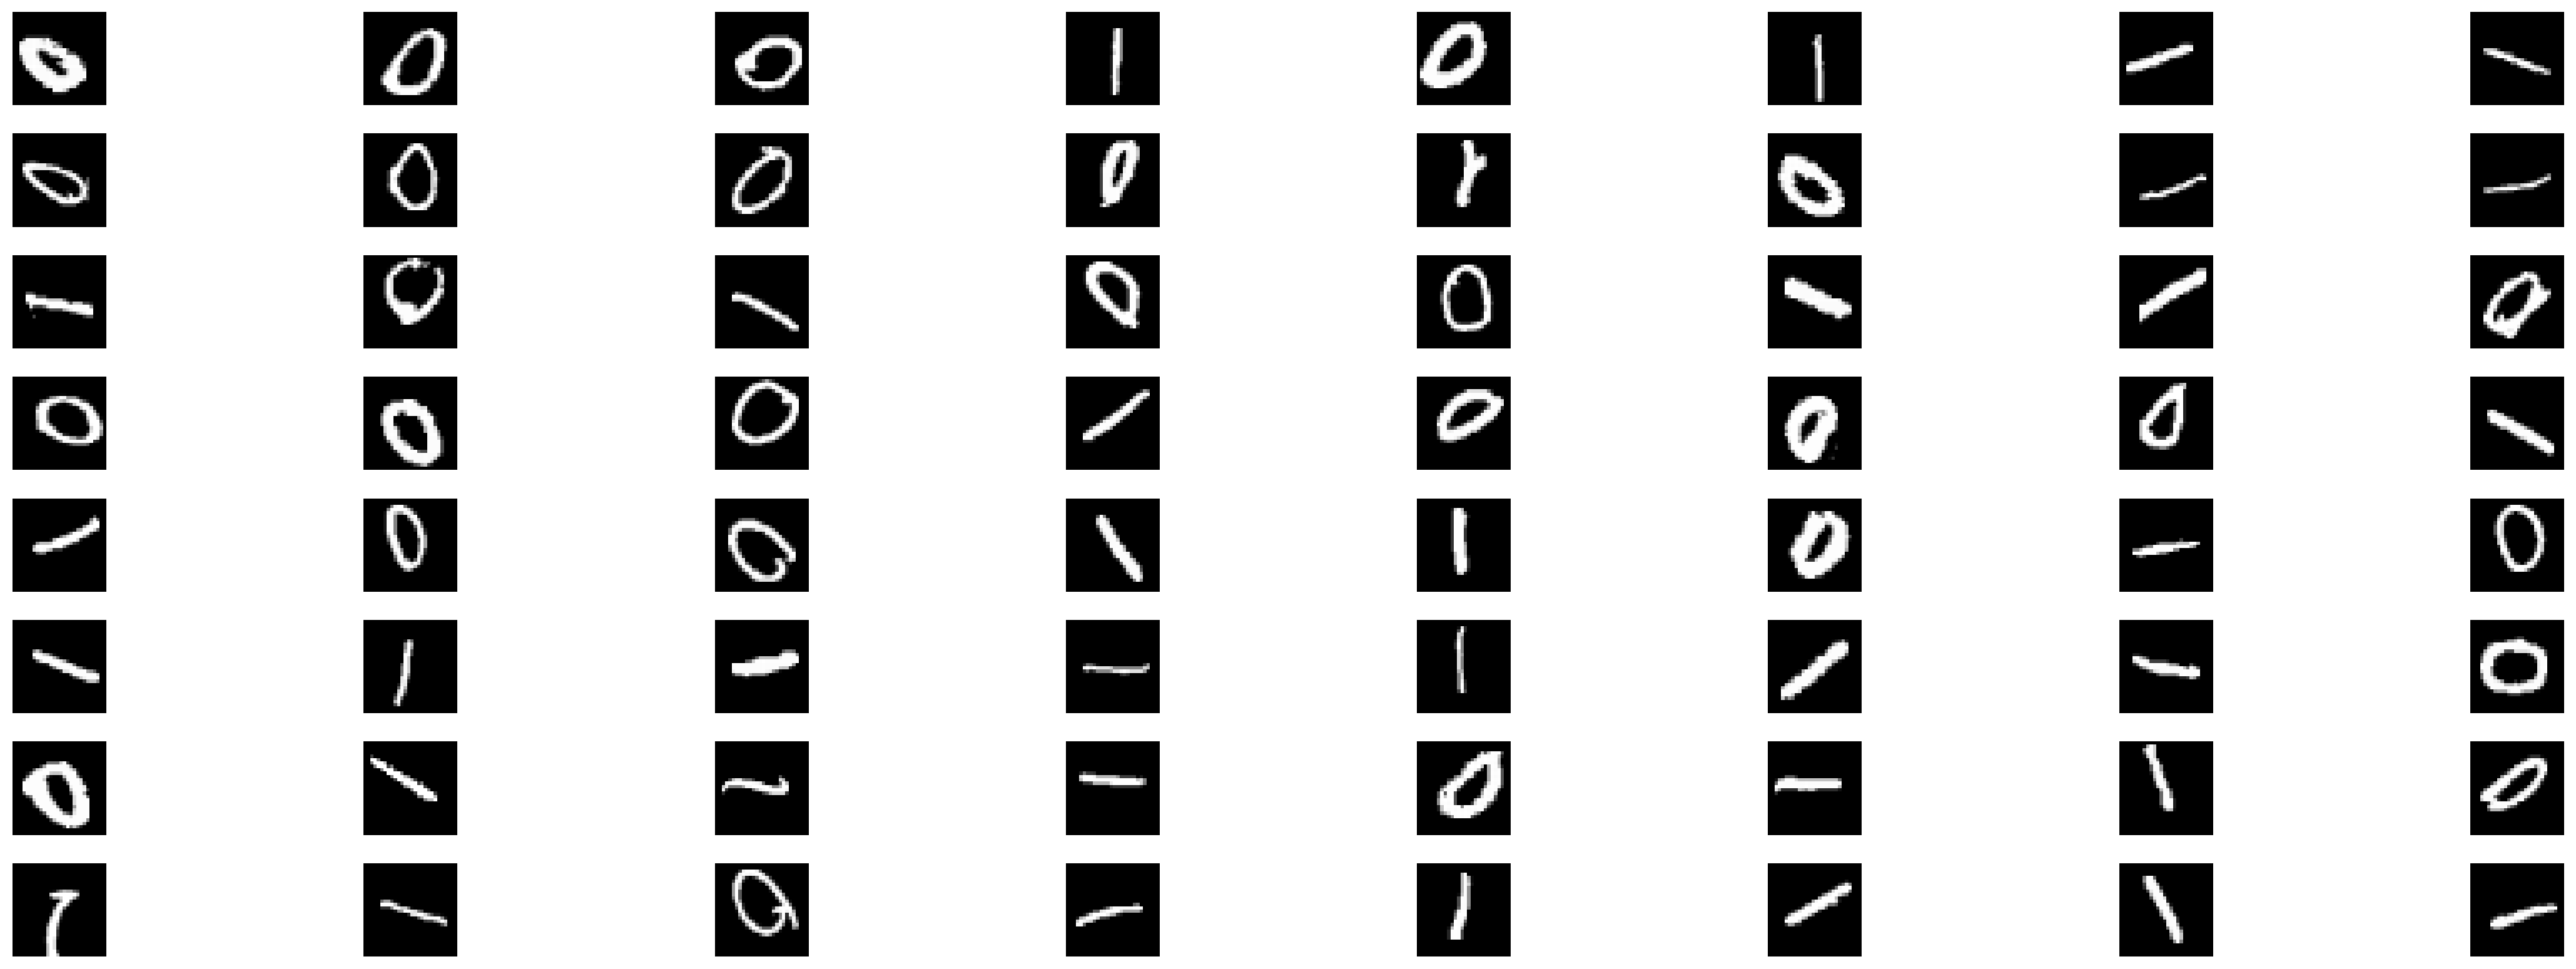

In [ ]:
rnd_key = jrandom.key(0)
num_images = 64
rnd_key, samp_key = jrandom.split(rnd_key)
indices = jrandom.choice(samp_key, jnp.arange(X_bin.shape[0]), shape=(num_images,), replace=False)
X_sample = X_bin[indices]
y_sample = y_bin[indices]
aug_keys = jrandom.split(rnd_key, num_images)
augmented_images = vmap_augment_image(X_sample, aug_keys)
rows = 8
cols = int(num_images / rows)
fig, axes = plt.subplots(rows, cols, figsize=(24, 8))  # Set up a row of 10 subplots
for r_ in range(rows):
  for c_ in range(cols):
    ax = axes[r_, c_]
    image = X_bin[r_*cols + c_]
    rnd_key, aug_key = jrandom.split(rnd_key)
    aug_image = augmented_images[r_*cols + c_]
    ax.imshow(aug_image[:784].reshape(28, 28), cmap='gray')  # Ensure using the right colormap if needed
    ax.axis('off')  # Hide axes for clarity
    #ax.set_title(str(y_bin_aug[r_*cols + c_]), fontsize=12)  # Use set_title to display the label below each image
plt.tight_layout()
remove_ip_clutter(fig)
plt.show()

# Figure 1: To eat or not to eat



## Life History Picture

We consider the life and evolution of a population of cartoonishly simple organisms. The life cycle of these organisms is dominated almost entirely by the simple binary decision problem illustrated and described below.

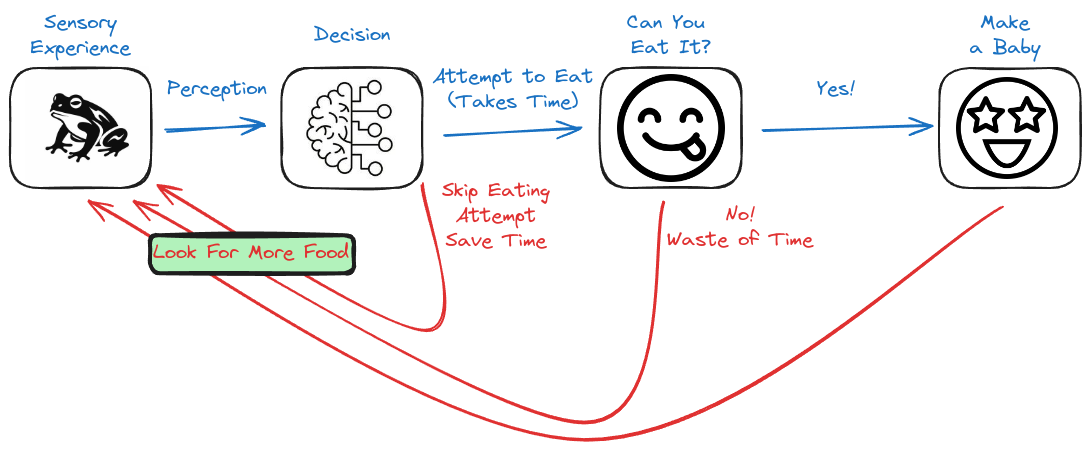

An organism's life consist of a series of episodes. Each episode is initiated by the sensory experience of something that the organism might try to eat. Based on this sensory experience the organism has to make a decision: approach and eat the food, which will take some time and effort; or skip eating and save some time and effort. If the organism skips eating, then the episode ends after the organism has spent only one time unit (perceiving and deciding takes one time unit) of their precious life on this episode. Alternatively if they choose to approach and eat, they spend an additional time unit of life, and get have another sensory experience, this time the taste of the thing that they tried to eat. If the food was nutritious, they become more fat and happy and are thus more likely to have spawn offspring that survive into the next generation of the population. If though, the food is not nutritious, they have now wasted a total of two time units of their short sweet precious time alive (one unit perceiving and deciding to approach, one unit approaching and tasting) and they are no more likely to have progeny for their effort.

That describes the core activity of the organisms in their niche, now let's describe the rest of their life history. Each generation, every organism lives for exactly ### time units, at which point they die. The ecological niche where this population lives can support a maximum of ### individuals. All of the babies born in the previous generation compete to become one of the ### adults in the next generation. Children mostly resemble their parents. Specifically, how organisms approach the binary discrimination problem described above will depend on a number of parameters (exactly how to be discussed shortly). Children will have the same parameter values as their parents, perturbed by Gaussian noise. Note there is no model here of the specific process of genetic inheritance and development, Gaussian noise on parameters is a rough substitute for explicitly modeled mechanisms of inheritance and development, serving as a kind of rug thrown over the complexity of the interactions between genes, how they change through point-mutations and recombination, and how these changes affect behaviour-phenotype through a developmental process.

# Figure 2: Decision as computation

In more detail the task these organisms face is to take the inputs from their ##x## pixels x # colour channels receptive field, and based on this decide whether to approach the food and try to eat it, or skip approaching that potential food and start searching for the next thing to eat. Approaching and attempting to eat food takes time, so trying to eat things that are not nutritious wastes time, ultimately leading to reduced reproduction. If we want to simulate an evolutionary process centered around this decision problem we first need to specify the nature of the behavioural policy, denoted $\pi$ (for policy).

We model this organism's behavioural policy as follows. We let $\mathbf{x}$ be the raw (visual) sensory input (column vector) of length 3072 in a given episode. (This can be reshaped into the $32\times32\times3$ receptive field we saw in the example.) We can think of each element $x_i$ of $\mathbf{x}$ as corresponding to the activation level of a single photosensitive receptor.

These input neurons are then connected to two output neurons, each one corresponding one of the two possible action selections, "eat" or "don't eat".

The activation level, as a vector $\mathbf{z}$, of these output neurons is computed as
$$ \mathbf{h} = \sigma(\mathbf{W}^1\mathbf{x}) $$
$$\mathbf{z} = \mathbf{W}^{\text{s}}\mathbf{x} + \mathbf{W}^2 \mathbf{h}$$
Here $\mathbf{h}$ is the activity of an intermediate (or hidden) layer of neurons, $\sigma$ is the standard logistic sigmoid function applied element-wise. This non-linearity allows for greater computationally flexibility in the behaviour function. $\mathbf{W}^1$, $\mathbf{W}^{\text{s}}$, and $\mathbf{W}^2$ are matrices of synaptic weights between the input neurons and the intermediate neurons, the input neurons and the output neurons, and the intermediate neurons and the output neurons respectively. In this case where there are 3073 inputs (we have done a standard 'trick' of augmenting $\mathbf{x}$ with a feature of contant value, hence 3073 inputs instead of 3072 which allows for a parameterizable baseline level of activation independent of sensory input) and 3 intermediate neurons, and 2 outputs, so $\mathbf{W}^1$ has shape $20 \times 3073$, $\mathbf{W}^\text{s}$ has shape $2 \times 3073$ and $\mathbf{W}^3$ has shape $2 \times 20$. This gives us
$$ h_i = \sigma \left( \sum_{j=1}^{3073} w^1_{ij} x_j \right)$$
and
$$ z_i = \sum_{j=1}^{3073} w^\text{s}_{ij} x_j + \sum_{j=1}^{20} w^2_{ij} h_j$$

**Notation Note**: $w_{ij}$ is the weight connecting the $j^{th}$ input to the $i^{th}$ output and is the element in the $i^{th}$ row and $j^{th}$ column of $\mathbf{W}$. Superscripts on $\mathbf{W}$ and $w$ indicate the specific layer of connections, $1^{st}$, $2^{nd}$ or skip.

**Sigmoid Definition**: $$\sigma(x) := \frac{\exp(x)}{1+\exp(x)}$$

To convert these activation levels, $\mathbf{z}$, into probabilities of taking actions we use softmax normalization. Softmax can be thought of as an extension of the logistic sigmoid function to multiple classes. (Even though we only have two classes here and we could use a logistic sigmoid function, mathematically and conceptually things work out more cleanly when we use the softmax function). Much like the logistic sigmoid turns any real number into a probability over a binary outcome (approach, avoid), the softmax function turns any vector of real values into a vector of probabilities over different outcomes
$$\text{softmax}(\mathbf{z}) := \frac{(\exp{z_0}, \dots, \exp(z_i), \dots, \exp(z_n))}{\sum_k \exp(z_k)}$$

We use a subscript to refer to a particular element of the softmax output so that probability of choosing a particular action $i$ can be expressed as:
$$ \Pr \{\text{action }i\} = \text{softmax}_i(\mathbf{z}) = \frac{\exp(z_i)}{\sum_k \exp(z_k)} $$

When there are only two possible actions, and one action has a fixed activation of $0$, then softmax normalization is equivalent to applying the logistic sigmoid of the variable (non-zero) activation level, to determine action probabilities.

Given all this, the behavioural policy $\pi$ is a function that gives the probability of taking the different possible actions, for a given sensory input. So in this particular case
$$\pi(\text{Approach} |\mathbf{x}) = \text{softmax}_0(\mathbf{W}^s\mathbf{x} + \mathbf{W^2}\sigma(\mathbf{W}^1\mathbf{x}))$$
and
$$\pi(\text{Avoid} |\mathbf{x}) = \text{softmax}_1(\mathbf{W}^s\mathbf{x} + \mathbf{W^2}\sigma(\mathbf{W}^1\mathbf{x}))$$

A rough schematic of this computation is shown below

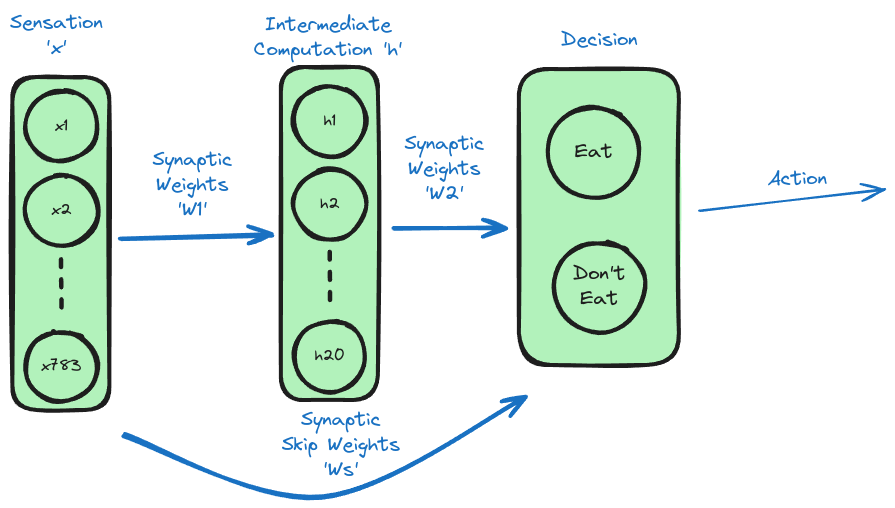

# Figure 3: Evolving a good behavioural policy in a static environment


Here, we see the power of selection in action. A simulate a process that generates variation and then selects from amongst that variation for those variants that perform better according to some criterion (in this case eating more nutritious things in a life). This process is applied iteratively over many generations, using the selected variants as the starting point for the next generation's variation. By iterating applying this process of selection and variance generation, (a gross approximation of the evolutionary process) we can arrive at an effective solution to this eat-don't-eat binary discrimination problem. Let's code it up and see it in action.

First we define some convenince functions (we could use special libraries for these but they are simple enough, and JAX makes things fast) that we can show everything from scratch (to about the level of math) without loss of speed.

## Utility Functions and Forward Pass

In [ ]:
def jnp_leaky_relu(x, alpha=0.01):
    return jnp.where(x > 0, x, alpha * x)

def jnp_sigmoid(x):
  return 1 / (1 + jnp.exp(-x))

def jnp_softmax(x):
  e_x = jnp.exp(x - jscipy.special.logsumexp(x))
  return e_x

def init_mlp_params(n_in, n_hid, n_out, rnd_key):
  k1, k2, k3 = jrandom.split(rnd_key, 3)
  norm = jnp.sqrt(2.0 / (n_out + n_in + n_hid))
  W1 = jrandom.normal(k1, (n_hid, n_in)) * norm
  W2 = jrandom.normal(k2, (n_out, n_hid)) * norm
  Ws = jrandom.normal(k3, (n_out, n_in)) * norm
  return W1, W2, Ws


n_in = (28 * 28) + 1
n_out = 2
n_hid = 20

rnd_key = jrandom.key(0)
test_params = init_mlp_params(n_in, n_hid, n_out, rnd_key)

def print_shapes(params):
  for p_type, p in zip(('W1', 'W2', 'Ws'), params):
    print(f'{p_type} has shape: {p.shape}')

print_shapes(test_params)

W1 has shape: (20, 785)
W2 has shape: (2, 20)
Ws has shape: (2, 785)


Those are the parameters of the decision function, now let's show how it's used to make a decision

In [ ]:
def forward_pass_mlp(x, params):
  # Activations for each layer
  W1, W2, Ws =  params
  a0 = x
  z1 = W1 @ a0
  h1 = jnp_leaky_relu(z1)
  logits = (W2 @ h1) + (Ws @ a0)
  # downstream computations often want raw logits,
  # not normalized into probabilities or even log probabilities
  return logits

That's how the parameters generate a decision probability, or more precisely the raw logits for a decision probability, but how does that translate into a decision and a fitness score?

## Decision Making

In [ ]:
def act_and_outcome(X, y, params, nutritious_type, rnd_key):
  # what does the organism do?
  logits = forward_pass_mlp(X, params)
  action = jrandom.categorical(rnd_key, logits=logits) # scalar
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  time_taken = 1 + did_approach
  baby_points = 0 + TP
  # we keep track of what the organism did to see how good they are
  # at discriminating between
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  return baby_points, time_taken, act_confusion

batch_act_and_outcome = vmap(act_and_outcome, in_axes=(0, 0, None, 0, 0))

@jit
def life_acts_and_outcomes(X, y, params, nutritious_type, lifespan, rnd_key):
  batch_keys = jrandom.split(rnd_key, X.shape[0])
  baby_points, time_taken, act_confusion = batch_act_and_outcome(X, y, params, nutritious_type, batch_keys)
  cum_time_taken = jnp.cumsum(time_taken)
  alive = cum_time_taken <= lifespan
  total_baby_points = jnp.sum(jnp.where(alive, baby_points, 0))
  alive_reshaped = alive[:, None, None]
  masked_confusion = jnp.where(alive_reshaped, act_confusion, 0)
  total_confusion = jnp.sum(masked_confusion, axis=0)
  return total_baby_points, total_confusion



Let's see how this works

(300,)
(300,)


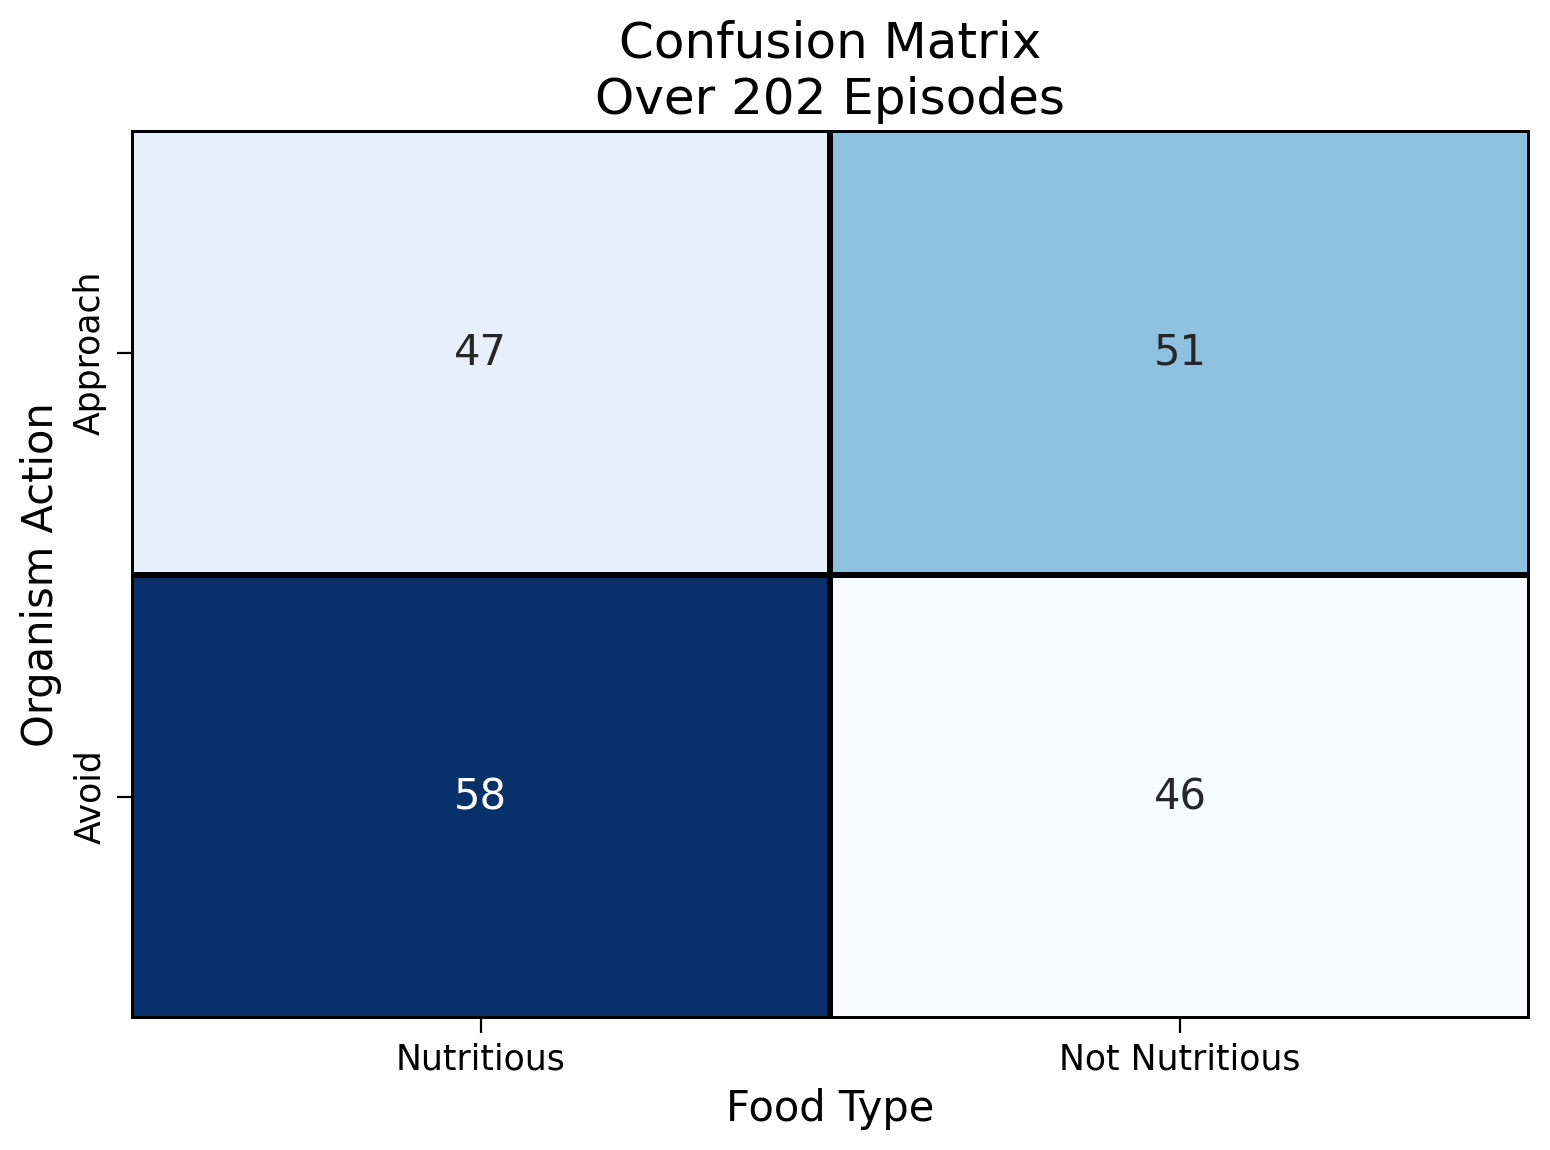

In [ ]:
@jit
def grab_batch_data(X, y, zero_indices, one_indices, rnd_key, size_dummy):
  rnd_key, sel_key = jrandom.split(rnd_key)
  sel_key_0, sel_key_1 = jrandom.split(sel_key)
  indices_0 = jrandom.choice(sel_key_0, zero_indices, size_dummy.shape, replace=False)
  indices_1 = jrandom.choice(sel_key_1, one_indices, size_dummy.shape, replace=False)
  rnd_key, shuf_key = jrandom.split(rnd_key)
  combined_indices = jnp.concatenate((indices_0, indices_1))
  combined_indices = jrandom.permutation(rnd_key, combined_indices)
  X_batch_raw = X[combined_indices]
  y_batch = y[combined_indices]
  aug_keys = jrandom.split(rnd_key, X_batch_raw.shape[0])
  X_batch_aug = vmap_augment_image(X_batch_raw, aug_keys)
  mean = jnp.mean(X_batch_aug, axis=0)
  std = jnp.std(X_batch_aug, axis=0)
  std = jnp.where(std == 0, 1, std)
  X_batch_z = (X_batch_aug - mean) / std
  return X_batch_z, X_batch_aug, y_batch

rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params = init_mlp_params(n_in, n_hid, n_out, init_key)

# simulations params
lifespan = 300
size_dummy = jnp.zeros(int(lifespan/2))
nutritious_type = 1
nutritious_type = jnp.tile(nutritious_type, (lifespan,))

rnd_key, batch_key = jrandom.split(rnd_key)
zero_indices = jnp.where(y_bin == 0)[0]
one_indices = jnp.where(y_bin == 1)[0]
X_z_test, image_test, y_test = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, batch_key, size_dummy)

print(y_test.shape)
print(nutritious_type.shape)

# Evaluate
rnd_key, eval_key = jrandom.split(rnd_key)
baby_points, confusion = life_acts_and_outcomes(X_z_test, y_test, test_params, nutritious_type, lifespan, eval_key)

def plot_confusion(confusion_matrix, title='Confusion Matrix'):
  """
  Plot confusion matrix with blue borders for correct decisions and red borders for incorrect decisions.
  """
  total_trials = confusion_matrix.sum()
  fig, ax = plt.subplots(figsize=(8, 6))  # Set figure size
  sns.heatmap(confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g', cbar=False, linewidths=2, linecolor='black')
  # Labels, title and ticks
  column_labels = ['Nutritious', 'Not Nutritious']
  row_labels = ['Approach', 'Avoid']
  ax.set_xlabel('Food Type')
  ax.set_ylabel('Organism Action')
  ax.set_title(title + f'\nOver {total_trials} Episodes')
  ax.xaxis.set_ticklabels(column_labels)
  ax.yaxis.set_ticklabels(row_labels)
  remove_ip_clutter(fig)
  plt.show()

plot_confusion(confusion)

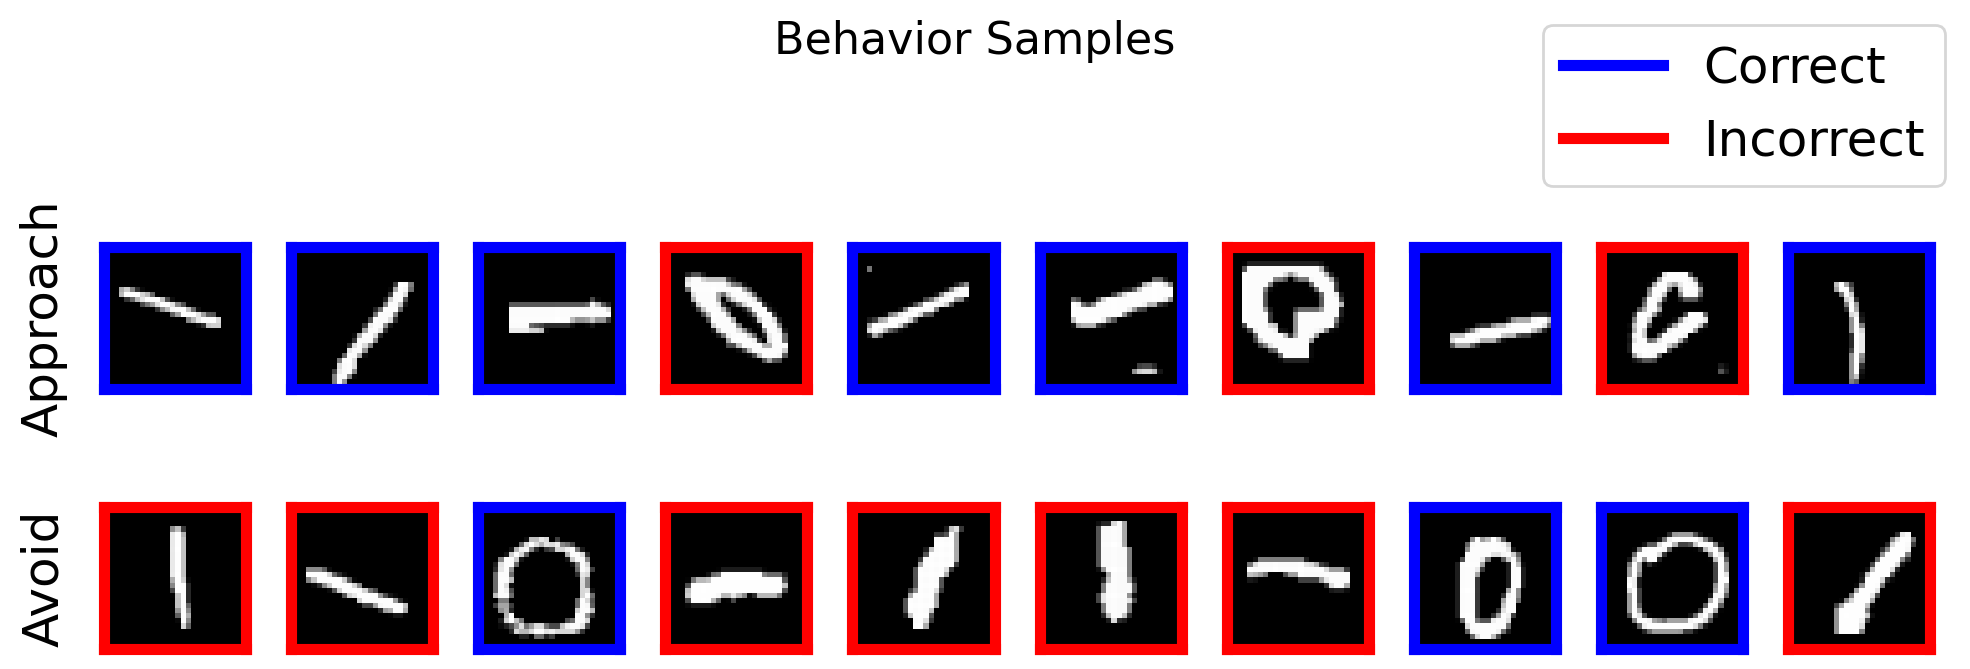

In [ ]:
def plot_behavior_samples(X, images, y, params, nutritious_type, rnd_key, imshape = (28, 28), num_samples=10, title='Behavior Samples'):
  """
  Plot images of samples with border colors indicating correct (blue) and incorrect (red) decisions.
  Args:
      X (jnp.ndarray): Input data, shape (batch_size, n_in).
      y (jnp.ndarray): Target labels, shape (batch_size,).
      actions (jnp.ndarray): Decision actions, shape (batch_size,).
      nutritious_type (jnp.ndarray): Which type is nutritious at each sample, shape (batch_size,).
      title (str): Title of the plot.
  """
  # Colors for correct and incorrect decisions
  correct_color = "blue"
  incorrect_color = "red"
  batch_keys = jrandom.split(rnd_key, X.shape[0])
  if nutritious_type.shape != y.shape:
    print(f'y has shape: {y.shape}')
    print(f'nutritious_type has shape: {nutritious_type.shape}')
    raise ValueError("y and nutritious_type must have the same shape.")
  baby_points, time_taken, act_confusion = batch_act_and_outcome(X, y, params, nutritious_type, batch_keys)
  was_nutritious = y == nutritious_type
  approach_mask = (act_confusion[:, 0, 0] == 1) | (act_confusion[:, 0, 1] == 1)
  approach_indices = jnp.where(approach_mask)[0]
  selected_approach_indices = approach_indices[:num_samples]
  avoid_mask = (act_confusion[:, 1, 0] == 1) | (act_confusion[:, 1, 1] == 1)
  avoid_indices = jnp.where(avoid_mask)[0]
  selected_avoid_indices = avoid_indices[:num_samples]
  # Adjust the number of columns to the actual number of samples
  num_approach_samples = len(selected_approach_indices)
  num_avoid_samples = len(selected_avoid_indices)
  max_samples = max(num_approach_samples, num_avoid_samples)
  fig, axes = plt.subplots(2, max_samples, figsize=(10, 4))  # 2 rows, max_samples columns
  fig.suptitle(title, fontsize=16)

  for i in range(num_samples):
    if i < num_approach_samples:
      idx = selected_approach_indices[i]
      image = images[idx][:np.prod(imshape)].reshape(imshape)
      if was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[0, i].imshow(image, cmap='gray')
      for spine in axes[0, i].spines.values():
          spine.set_edgecolor(border_color)
          spine.set_linewidth(4)
    else:
      axes[0, i].imshow(np.ones(imshape), cmap='gray')  # Display blank space
      for spine in axes[0, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[0, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[0, i].spines['top'].set_visible(True)
    axes[0, i].spines['right'].set_visible(True)

    if i < num_avoid_samples:
      idx = selected_avoid_indices[i]
      image = images[idx][:np.prod(imshape)].reshape(imshape)
      if not was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[1, i].imshow(image, cmap='gray')
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    else:
      axes[1, i].imshow(np.ones(imshape), cmap='gray')  # Display blank space
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[1, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[1, i].spines['top'].set_visible(True)
    axes[1, i].spines['right'].set_visible(True)

  # Add labels to the rows
  axes[0, 0].annotate('Approach', xy=(0, 0.5), xytext=(-axes[0, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[0, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  axes[1, 0].annotate('Avoid', xy=(0, 0.5), xytext=(-axes[1, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[1, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  # Create custom legend
  legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Correct'),
                     Line2D([0], [0], color='red', lw=4, label='Incorrect')]
  fig.legend(handles=legend_elements, loc='upper right', fontsize='large')
  remove_ip_clutter(fig)
  plt.show()

plot_behavior_samples(X_z_test, image_test, y_test, test_params, nutritious_type, rnd_key, num_samples=10, title='Behavior Samples')

## Evolutionary Simulation
We initialize our decision function, so that it essentially choses at random, now we try to get this to evolve.

First best confusion matrix:
[[693 418]
 [252 525]]
Gen: 0/200 | Avg: 508.8600 | Std: 83.4889 | Par Prop: 0.0200 | Fit dif:187.8980 |Gen Time: 4.61s | Total Time: 4.62s
Confusion Matrix:
[[25443 24895]
 [24784 24520]]
Gen: 40/200 | Avg: 951.5000 | Std: 7.0121 | Par Prop: 0.2800 | Fit dif:10.5099 |Gen Time: 0.01s | Total Time: 5.04s
Confusion Matrix:
[[47575  2625]
 [ 1865 47715]]
Gen: 80/200 | Avg: 966.4600 | Std: 3.3179 | Par Prop: 0.3600 | Fit dif:5.1150 |Gen Time: 0.01s | Total Time: 5.34s
Confusion Matrix:
[[48323  3341]
 [ 1178 45474]]
Gen: 120/200 | Avg: 969.6000 | Std: 2.4980 | Par Prop: 0.4400 | Fit dif:3.9499 |Gen Time: 0.01s | Total Time: 5.64s
Confusion Matrix:
[[48480  3157]
 [  800 45905]]
Gen: 160/200 | Avg: 957.1000 | Std: 2.2023 | Par Prop: 0.4200 | Fit dif:3.6165 |Gen Time: 0.01s | Total Time: 5.95s
Confusion Matrix:
[[47855  2863]
 [ 1002 47547]]
Final best confusion matrix:
[[984  37]
 [ 13 945]]


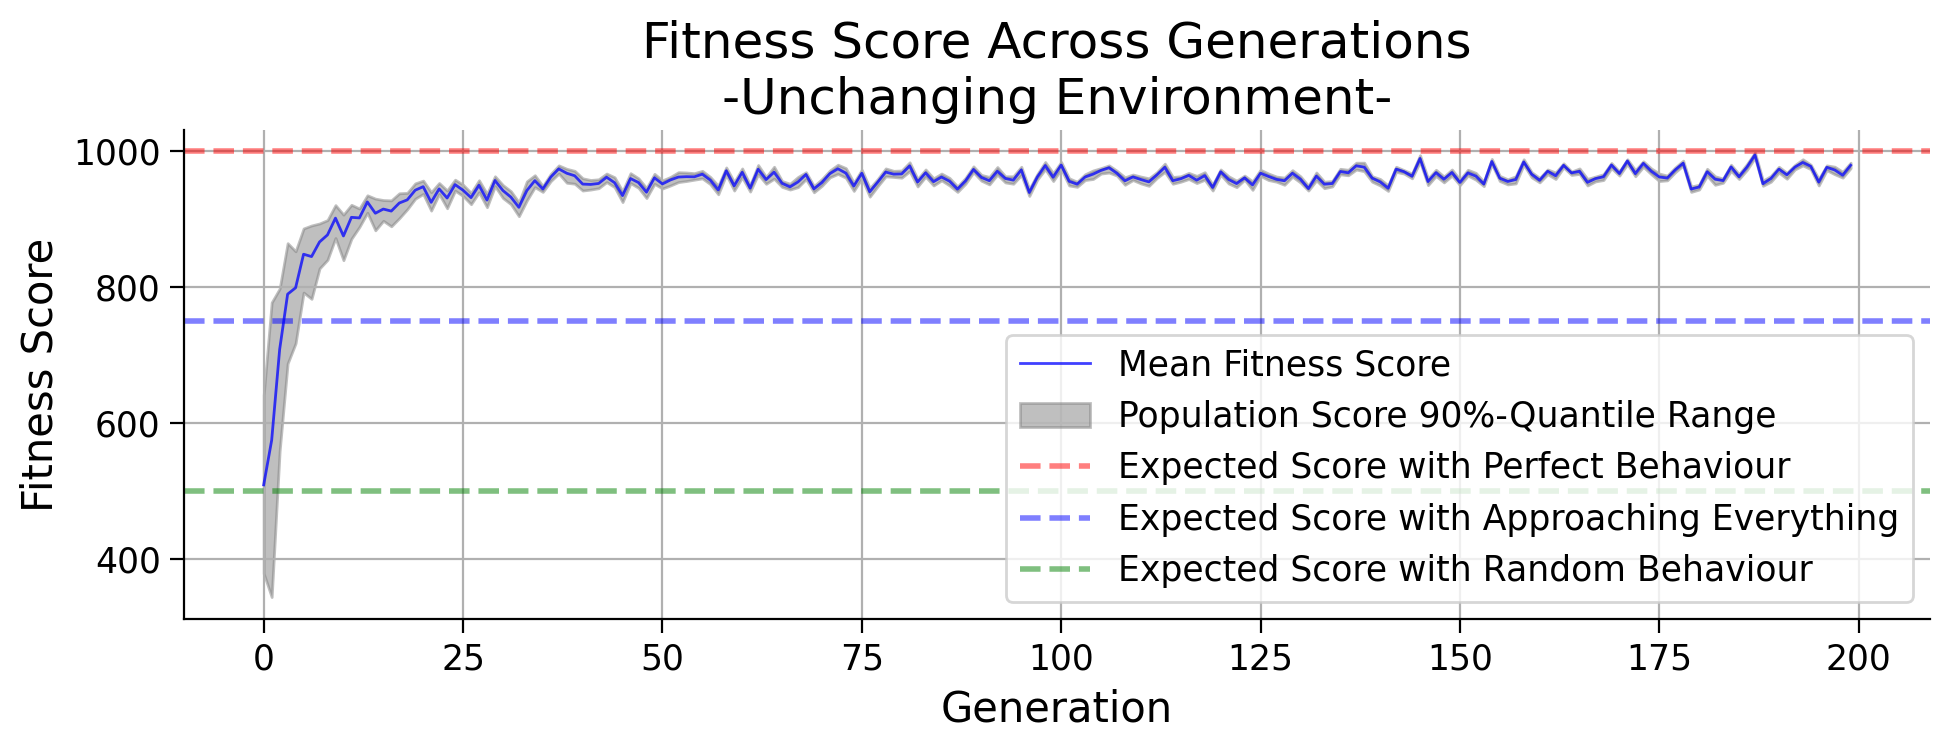

In [ ]:
def init_pop_mlp_params(pop_size, n_in, n_hid, n_out, rnd_key):
  k1, k2, k3 = jrandom.split(rnd_key, 3)
  norm = jnp.sqrt(2 / (n_out + n_in + n_hid))
  pop_W1 = jrandom.normal(k1, (pop_size, n_hid, n_in)) * norm
  pop_W2 = jrandom.normal(k2, (pop_size, n_out, n_hid)) * norm
  pop_Ws = jrandom.normal(k3, (pop_size, n_out, n_in)) * norm
  return [pop_W1, pop_W2, pop_Ws]

def evaluate_individual(carry, individual_params):
  rnd_key, X, y, nutritious_type, lifespan = carry
  rnd_key, eval_key = jrandom.split(rnd_key)
  baby_points, confusion = life_acts_and_outcomes(X, y, individual_params, nutritious_type, lifespan, eval_key)
  return (rnd_key, X, y, nutritious_type, lifespan), (baby_points, confusion)

def evaluate_population(pop_params, X, y, nutritious_type, lifespan, rnd_key):
  init_carry = (rnd_key, X, y, nutritious_type, lifespan)
  _, (fitness_scores, confusion) = lax.scan(evaluate_individual, init_carry, pop_params)
  return fitness_scores, confusion

@jit
def select_parents(fitness_scores, rnd_key, sel_str):
  # note that probability of being a parent is directly proportional to
  # 'fitness' score resulting from the evaluaton function
  probabilities = jnp_softmax(fitness_scores/sel_str)
  probabilities = probabilities / probabilities.sum()  # Normalize to ensure sum is exactly 1
  cumulative_probabilities = jnp.cumsum(probabilities)
  selection_points = jrandom.uniform(rnd_key, (len(fitness_scores),))
  parent_indices = jnp.searchsorted(cumulative_probabilities, selection_points)
  return parent_indices

def add_noise(W, rnd_key, mutation_scale):
  noise = jrandom.normal(rnd_key, W.shape) * mutation_scale
  return W + noise

@jit
def mutate(pop_params, rnd_key, mutation_scale: float):
  mutated_params = []
  for param in pop_params:
    rnd_key, mut_key = jrandom.split(rnd_key)
    mutated_params.append(add_noise(param, mut_key, mutation_scale))
  return mutated_params

def median_index(fitness_scores):
  sorted_indices = jnp.argsort(fitness_scores)
  median_idx = len(fitness_scores) // 2
  return sorted_indices[median_idx]

def simulate_evolution(num_generations=200, pop_size=50, lifespan=3000,
                       nutritious_type=0, env_change_freq = 1000,
                       mut_scale=0.2, softmax_selection_strength_temp=2.0,
                       n_in = 28 * 28 * 1 + 1, n_hid = 20, n_out = 2,
                       X = X_bin, y = y_bin,
                       print_freq=5, rnd_key=jrandom.key(0)):

  zero_indices = jnp.where(y == 0)[0]
  one_indices = jnp.where(y == 1)[0]
  size_dummy = jnp.zeros(int(lifespan / 2))
  fitness_history = []
  rnd_key, init_key = jrandom.split(rnd_key)
  pop_params = init_pop_mlp_params(pop_size, n_in, n_hid, n_out, init_key)
  start_time = time.time()
  nutritious_type = jnp.tile(nutritious_type, (lifespan,))
  for g in range(num_generations):
    if g % env_change_freq == 0:
      nutritious_type = 1 - nutritious_type

    gen_start_time = time.time()

    rnd_key, grab_key, eval_key, sel_key, mut_key = jrandom.split(rnd_key, 5)
    X_gen, image_gen, y_gen = grab_batch_data(X, y, zero_indices, one_indices, grab_key, size_dummy)
    fitness_scores, pop_confusion = evaluate_population(
        pop_params, X_gen, y_gen, nutritious_type, lifespan, eval_key)
    parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
    unique_parents_count = len(jnp.unique(parent_indices))
    best_idx = jnp.argmax(fitness_scores)
    med_idx = median_index(fitness_scores)
    parent_params = [pop_param_[parent_indices] for pop_param_ in pop_params]

    if g == num_generations - 1:
      best_params_end = [pop_param_[best_idx] for pop_param_ in pop_params]
      med_params_end = [pop_param_[med_idx] for pop_param_ in pop_params]
      print('Final best confusion matrix:')
      print(pop_confusion[best_idx])
    if g == 0:
      best_params_start = [pop_param_[best_idx] for pop_param_ in pop_params]
      med_params_start = [pop_param_[med_idx] for pop_param_ in pop_params]
      print('First best confusion matrix:')
      print(pop_confusion[best_idx])

    pop_params = mutate(parent_params, mut_key, mut_scale)

    fitness_history.append({
      'generation': g,
      'mean_fitness': jnp.mean(fitness_scores).item(),
      'std_dev_fitness': jnp.std(fitness_scores).item(),
      'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
      'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
      'unique_parents_count': unique_parents_count,})

    gen_time = time.time() - gen_start_time
    total_elapsed_time = time.time() - start_time

    if g % print_freq == 0:
      current_gen_data = fitness_history[-1]
      selected_fitness = fitness_scores[parent_indices]
      not_selected_indices = jnp.setdiff1d(jnp.arange(pop_size), parent_indices)
      not_selected_fitness = fitness_scores[not_selected_indices]
      mean_selected_fitness = jnp.mean(selected_fitness)
      mean_not_selected_fitness = jnp.mean(not_selected_fitness)
      print(f"Gen: {g}/{num_generations} | Avg: {current_gen_data['mean_fitness']:.4f} | Std: {current_gen_data['std_dev_fitness']:.4f} | Par Prop: {current_gen_data['unique_parents_count'] / pop_size:.4f} | Fit dif:{mean_selected_fitness - mean_not_selected_fitness:.4f} |Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")
      print('Confusion Matrix:')
      print(jnp.sum(pop_confusion, axis=0))

  return fitness_history, (best_params_start, med_params_start, best_params_end, med_params_end, X_gen, image_gen, y_gen)

def plot_fitness_history(fitness_history, lifespan, env_type_str, window_size=1,):
  generations = [data['generation'] for data in fitness_history]
  mean_fitness = [data['mean_fitness'] for data in fitness_history]
  q05_fitness = [data['q05_fitness'] for data in fitness_history]
  q95_fitness = [data['q95_fitness'] for data in fitness_history]
  mean_fitness_series = pd.Series(mean_fitness)
  q05_fitness_series = pd.Series(q05_fitness)
  q95_fitness_series = pd.Series(q95_fitness)
  mean_fitness_smooth = mean_fitness_series.rolling(window=window_size).mean()
  q05_fitness_smooth = q05_fitness_series.rolling(window=window_size).mean()
  q95_fitness_smooth = q95_fitness_series.rolling(window=window_size).mean()
  fig, ax = plt.subplots(figsize=(10, 4))
  ax.plot(generations, mean_fitness_smooth, label='Mean Fitness Score', color='blue', linewidth=1, alpha=0.75)
  ax.fill_between(generations, q05_fitness_smooth, q95_fitness_smooth, color='gray', alpha=0.5, label='Population Score 90%-Quantile Range')
  ax.axhline(y=lifespan / 3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha=0.5)
  ax.axhline(y=lifespan / 4, color='blue', linestyle='--', linewidth=2, label='Expected Score with Approaching Everything', alpha=0.5)
  ax.axhline(y=lifespan / 6, color='green', linestyle='--', linewidth=2, label='Expected Score with Random Behaviour', alpha=0.5)
  ax.set_title(f'Fitness Score Across Generations\n-{env_type_str} Environment-')
  ax.set_xlabel('Generation')
  ax.set_ylabel('Fitness Score')
  ax.grid(True)
  ax.legend()
  plt.show()

nutritious_type = 0
lifespan = 3000
fitness_history, (best_params_start, med_params_start, best_params_end, med_params_end, X_gen, image_gen, y_gen) = simulate_evolution(
  num_generations=200, pop_size=50, lifespan=lifespan,
  nutritious_type=nutritious_type, env_change_freq = 1000,
  mut_scale=0.2, softmax_selection_strength_temp=2,
  n_in = 28 * 28 * 1 + 1, n_hid = 20, n_out = 2,
  X = X_bin, y = y_bin,
  print_freq=40, rnd_key = jrandom.key(2))

plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Unchanging', window_size=1)

In the first generation the behaviour of the median organism looks like this

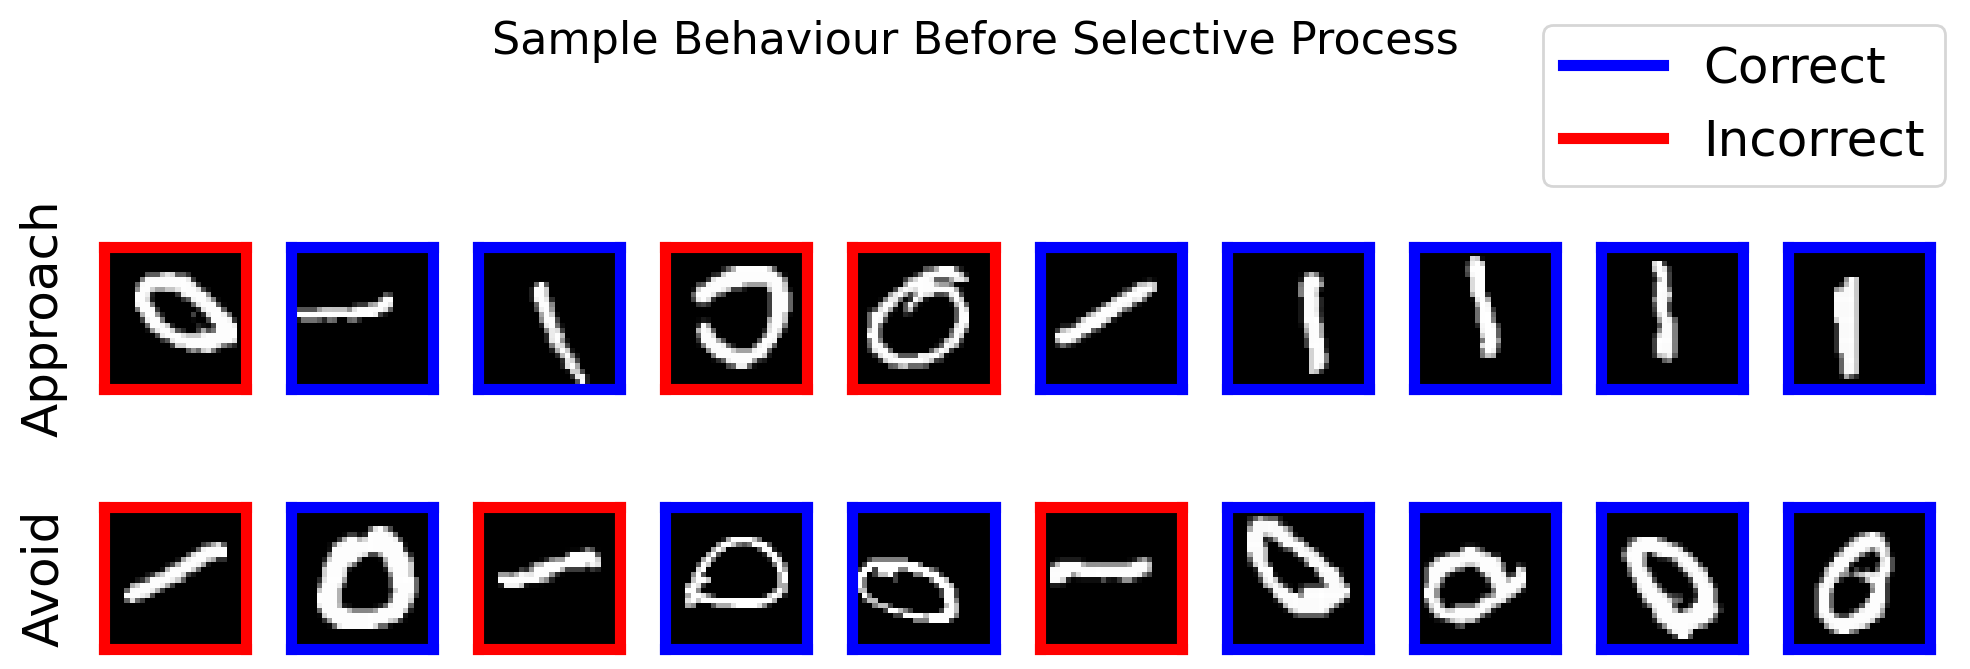

In [ ]:
nutritious_type = 1
nutritious_type = jnp.tile(nutritious_type, y_gen.shape)
plot_behavior_samples(X_gen, image_gen, y_gen, med_params_start, nutritious_type, rnd_key, imshape = (28, 28), num_samples=10, title='Sample Behaviour Before Selective Process')

But after evolution the behaviour of the median organism looks like this, basically perfect

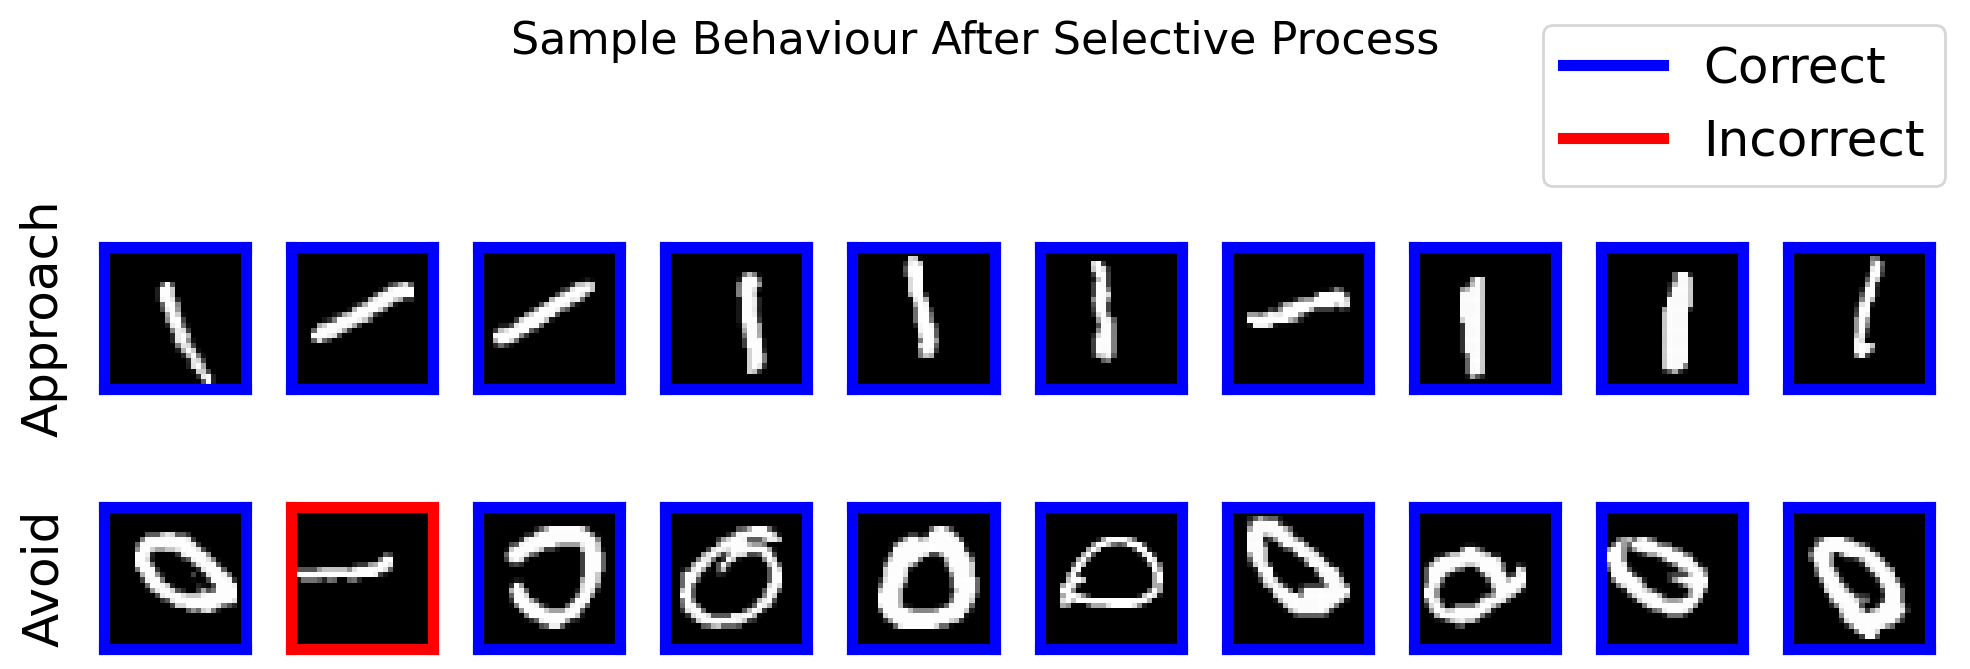

In [ ]:
plot_behavior_samples(X_gen, image_gen, y_gen, med_params_end, nutritious_type, rnd_key, imshape = (28, 28), num_samples=10, title='Sample Behaviour After Selective Process')

# Figure 4: Evolving a policy in a changing environment
So selection on random heritable variation can and does (in the above case) find good parameters for the behavioural policy approaching (almost) all the line-ish things it encounters and avoiding all the round-ish things it encounter... but what happens when the right thing to do can change from generation to generation. If these changes are infrequent than se

First best confusion matrix:
[[693 418]
 [252 525]]
Gen: 0/400 | Avg: 508.8600 | Std: 83.4889 | Par Prop: 0.0200 | Fit dif:187.8980 |Gen Time: 0.01s | Total Time: 0.01s
Confusion Matrix:
[[25443 24895]
 [24784 24520]]
Gen: 50/400 | Avg: 52.5000 | Std: 8.0678 | Par Prop: 0.1600 | Fit dif:15.3562 |Gen Time: 0.01s | Total Time: 0.42s
Confusion Matrix:
[[ 2625 47587]
 [47777  1786]]
Gen: 100/400 | Avg: 740.0800 | Std: 8.2020 | Par Prop: 0.0200 | Fit dif:26.4490 |Gen Time: 0.01s | Total Time: 0.79s
Confusion Matrix:
[[37004 36882]
 [ 1870   339]]
Gen: 150/400 | Avg: 107.4800 | Std: 16.4733 | Par Prop: 0.0600 | Fit dif:40.1434 |Gen Time: 0.01s | Total Time: 1.20s
Confusion Matrix:
[[ 5374 46732]
 [44411  1355]]
Gen: 200/400 | Avg: 761.0600 | Std: 0.2375 | Par Prop: 0.6000 | Fit dif:-0.0100 |Gen Time: 0.01s | Total Time: 1.59s
Confusion Matrix:
[[38053 36938]
 [    0    12]]
Gen: 250/400 | Avg: 104.1600 | Std: 14.8248 | Par Prop: 0.1600 | Fit dif:30.1381 |Gen Time: 0.01s | Total Time: 1.99s
C

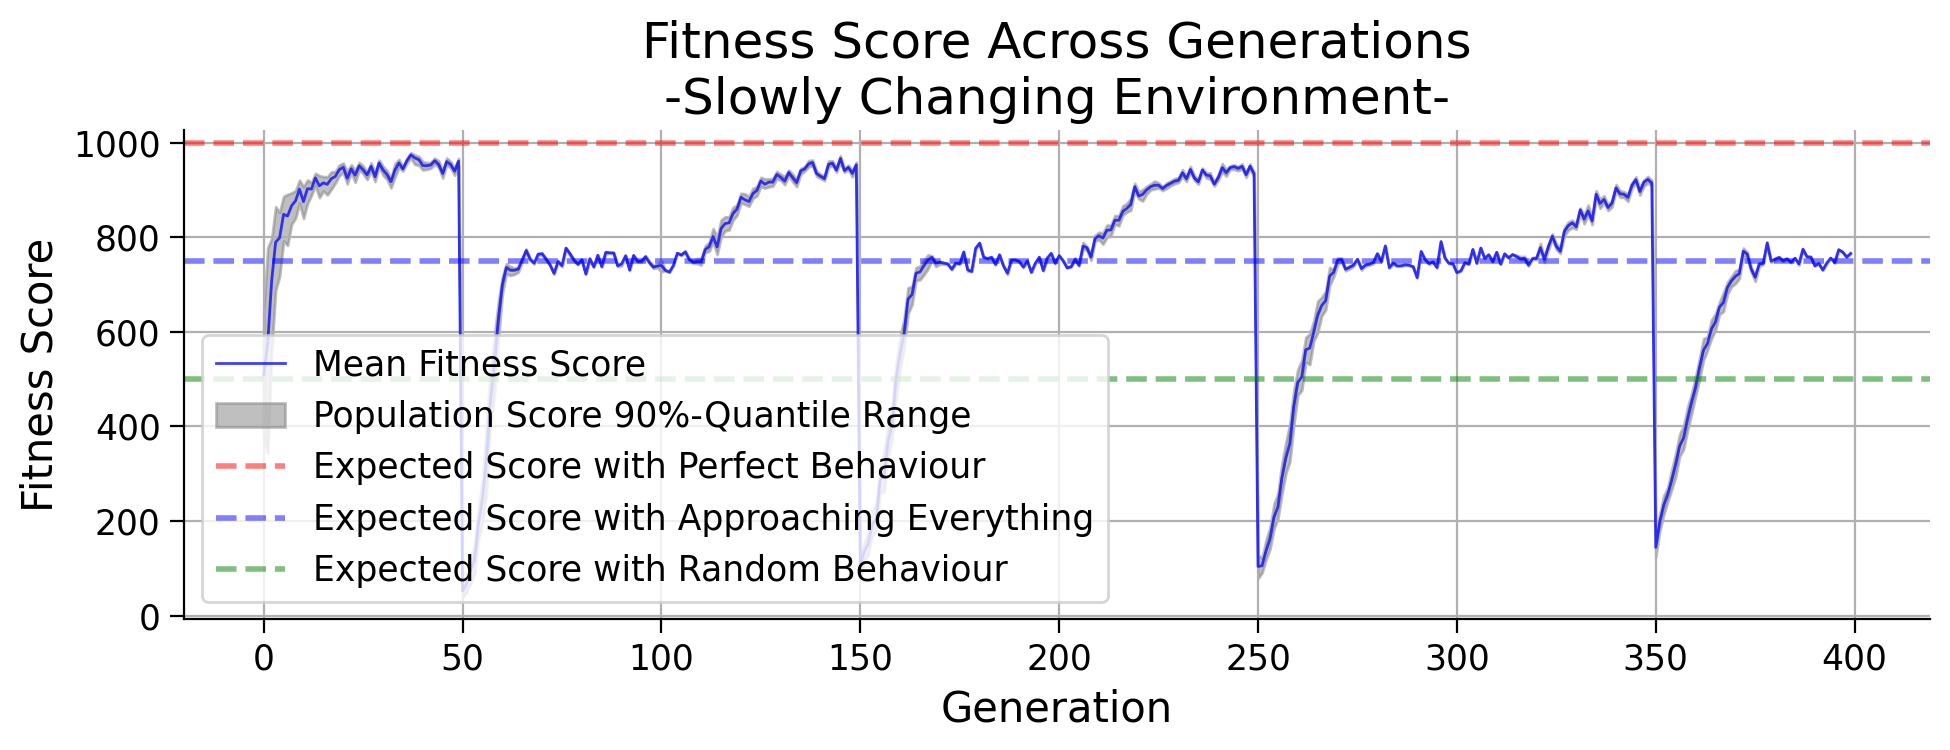

In [ ]:
fitness_history, (best_params_start, med_params_start,
                  best_params_end, med_params_end,
                  X_gen, image_gen, y_gen) = simulate_evolution(
  num_generations=400, pop_size=50, lifespan=3000,
  nutritious_type=0, env_change_freq = 50,
  mut_scale=0.2, softmax_selection_strength_temp=2,
  n_in = 28 * 28 * 1 + 1, n_hid = 20, n_out = 2,
  X = X_bin, y = y_bin,
  print_freq=50, rnd_key = jrandom.key(2))

plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Slowly Changing', window_size=1)

First best confusion matrix:
[[693 418]
 [252 525]]
Gen: 0/200 | Avg: 508.8600 | Std: 83.4889 | Par Prop: 0.0200 | Fit dif:187.8980 |Gen Time: 0.01s | Total Time: 0.01s
Confusion Matrix:
[[25443 24895]
 [24784 24520]]
Gen: 40/200 | Avg: 747.5800 | Std: 1.7331 | Par Prop: 0.4400 | Fit dif:2.8514 |Gen Time: 0.01s | Total Time: 0.32s
Confusion Matrix:
[[37379 37359]
 [   44   453]]
Gen: 80/200 | Avg: 746.5200 | Std: 0.8998 | Par Prop: 0.5800 | Fit dif:0.4943 |Gen Time: 0.01s | Total Time: 0.62s
Confusion Matrix:
[[37326 37626]
 [   34    44]]
Gen: 120/200 | Avg: 743.3000 | Std: 1.2689 | Par Prop: 0.5600 | Fit dif:0.9818 |Gen Time: 0.01s | Total Time: 0.90s
Confusion Matrix:
[[37165 37792]
 [   53    20]]
Gen: 160/200 | Avg: 738.0200 | Std: 0.3736 | Par Prop: 0.5800 | Fit dif:0.1676 |Gen Time: 0.01s | Total Time: 1.19s
Confusion Matrix:
[[36901 38089]
 [    3    11]]
Final best confusion matrix:
[[745 755]
 [  0   0]]


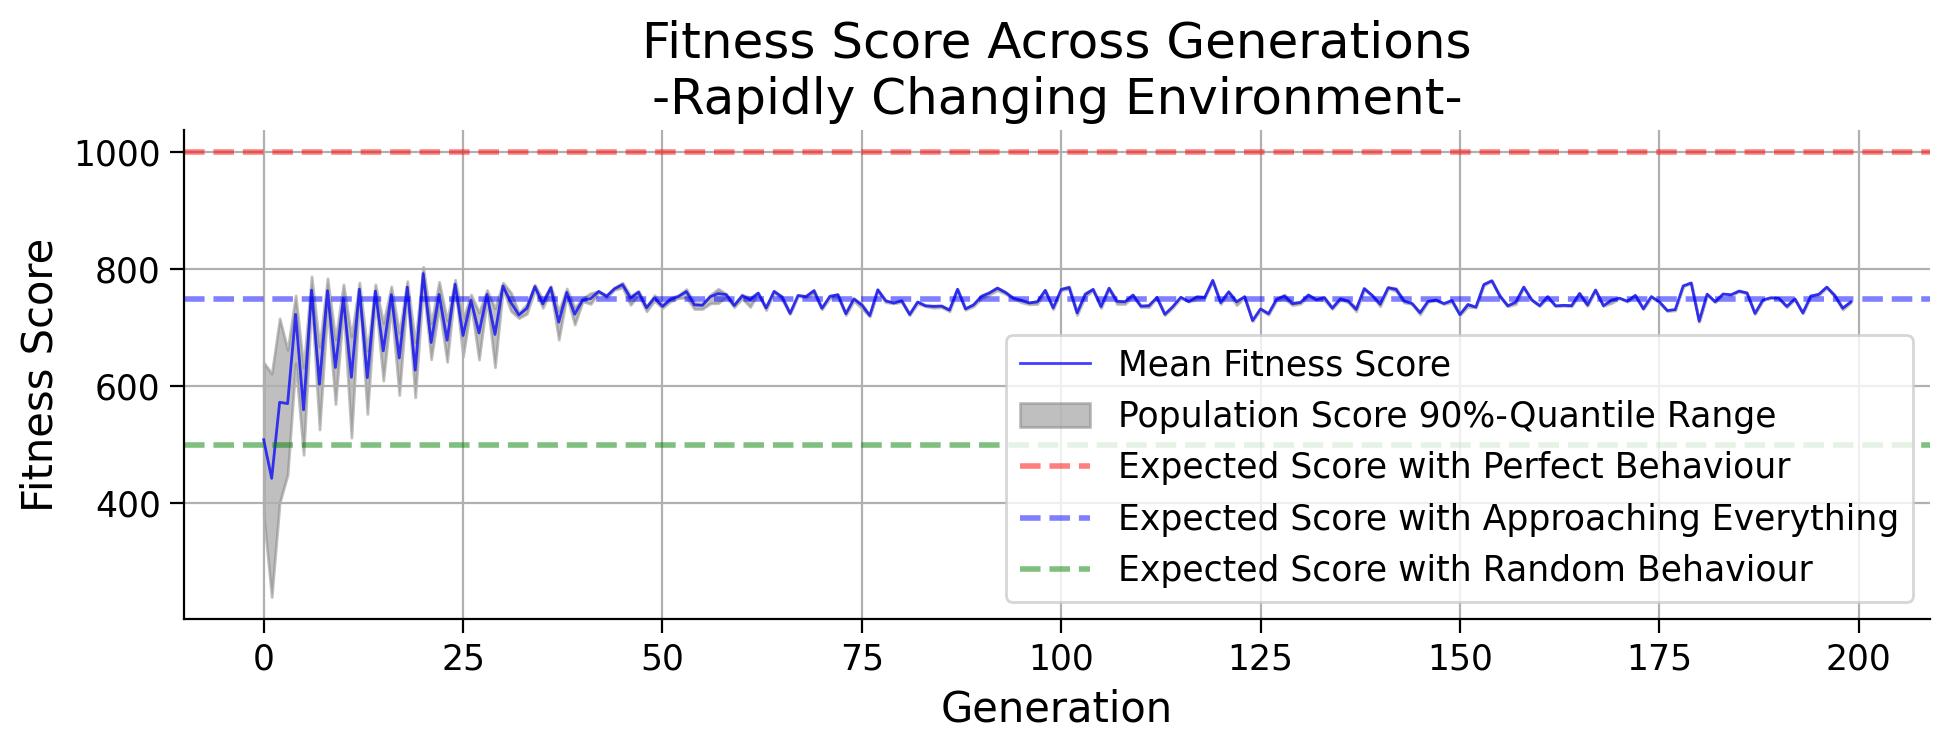

In [ ]:
fitness_history, (best_params_start, med_params_start,
                  best_params_end, med_params_end,
                  X_gen, image_gen, y_gen) = simulate_evolution(
  num_generations=200, pop_size=50, lifespan=3000,
  nutritious_type=0, env_change_freq = 1,
  mut_scale=0.2, softmax_selection_strength_temp=2,
  n_in = 28 * 28 * 1 + 1, n_hid = 20, n_out = 2,
  X = X_bin, y = y_bin,
  print_freq=40, rnd_key = jrandom.key(2))

plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Rapidly Changing', window_size=1)

# Figure 5: Learning can achieve adaptive behaviour, even in a rapidly changing envirnment

Like before, the organism acts, and there is an outcome in terms of fitness score, but now, each possible outcome, approach nutritious food (true positive, TP), approach non-nutritious food (false positive FP), avoid nutritious food (false negative FN), avoid non-nutritous food (true negative TN). Can all be associated with different learning signal (or in the Reinforcement Learning RL, terminolgoy, rewards). For now we assume that there is something that can be reliably associated with the tastes of nutritious vs. non-nutrirous food, so TP and FP can have different rewards associated with them, but that no additional information is given when the avoid action is taken so the reward associated with FN and TN is the same. So now in addition to the parameters of the policy function, there are additional learning parameters, specifying how different outcomes of behaviour are percieved as rewarding or not.

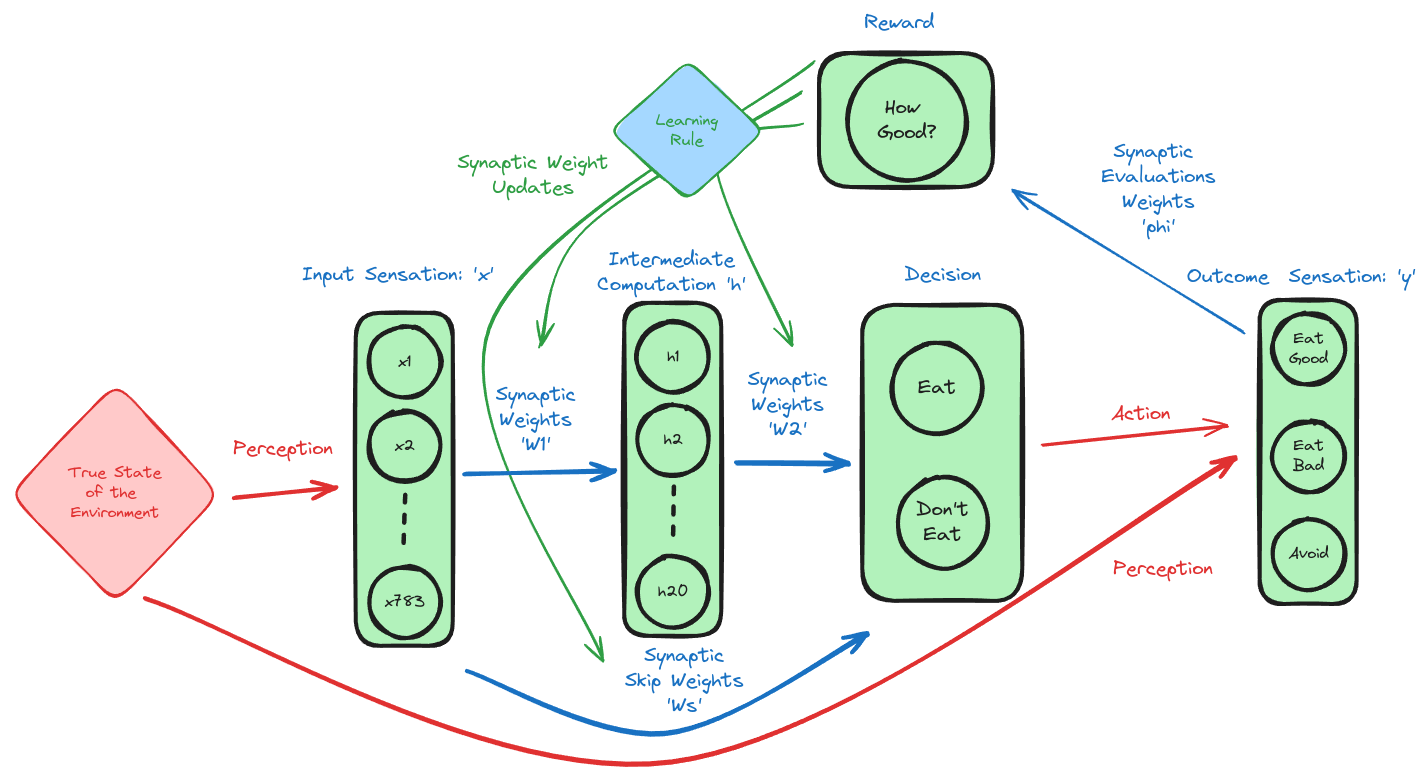

In [ ]:
def obj_act_outcome_reward(X, y, params, r_params, reg_param_alpha, nutritious_type, rnd_key):
  # what does the organism do?
  logits = forward_pass_mlp(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  action = jrandom.categorical(rnd_key, logits=logits) # scalar
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  time_taken = 1 + did_approach
  baby_points = 0 + TP
  outcome = jnp.array([TP, FP, FN, TN])
  ext_r_params = jnp.concatenate([r_params, r_params[-1:]])
  reward = jnp.dot(outcome, ext_r_params) # r_TP, r_FP, r_FN, r_TN = ext_r_params
  # r_TP, r_FP, r_FN = r_TN = r_params, avoid reward is same regardless of type
  # reward scaled log probability is what we use to inform parameter updates
  rslp = reward * act_log_prob[action]
  act_prob = jnp.exp(act_log_prob)
  act_ent = -jnp.sum(act_prob * act_log_prob)
  print(type(reg_param_alpha))
  obj = rslp + reg_param_alpha * act_ent
  # we keep track of what the organism did to see how good they are
  # at discriminating between
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  return obj, (action, reward, baby_points, time_taken, act_confusion)


# we use the gradient of the reward scaled log probability of the chosen action, wrt to the
# policy parameters to inform how learning changes parameters.
vg_obj = jit(jax.value_and_grad(obj_act_outcome_reward, argnums=2, has_aux=True))


def update_parameters(params, grads, learning_rates):
  def update(param, grad, lr):
    return param + lr * grad
  updated_params = jax.tree_util.tree_map(update, params, grads, learning_rates)
  return updated_params

def act_reward_learn(X, y, individual_params, nutritious_type, rnd_key):
  policy_params, r_params, reg_param_alpha, learning_rates = individual_params
  print(f'policy_params type: {type(policy_params)}')
  print(f'r_params type: {type(r_params)}')
  print(f'learning_rates type: {type(learning_rates)}')
  print(f'reg_param_alpha type: {type(reg_param_alpha)}')
  ((obj, aux), grad) = vg_obj(X, y, policy_params, r_params, reg_param_alpha, nutritious_type, rnd_key)
  (a, r, bp, tt, act_x) = aux
  updated_policy_params = update_parameters(policy_params, grad, learning_rates)
  return updated_policy_params, a, r, bp, obj, tt, act_x

def act_reward_learn_loop_fn(carry, X_y):
  X_i, y_i, nt_i = X_y
  individual_params, rnd_key = carry
  rnd_key, arl_key = jrandom.split(rnd_key)
  updated_policy_params, a, r, bp, obj, tt, act_x = act_reward_learn(X_i, y_i, individual_params, nt_i, arl_key)
  updated_individual_params = (updated_policy_params, individual_params[1], individual_params[2], individual_params[3])
  carry = (updated_individual_params, rnd_key)
  return carry, (a, r, bp, obj, tt, act_x)

def act_reward_learn_eval(X, y, X_eval, y_eval, individual_params, nutritious_type, lifespan, rnd_key):
  policy_params, r_params, reg_param_alpha, learning_rates = individual_params
  ((obj, aux), grad) = vg_obj(X, y, policy_params, r_params, reg_param_alpha, nutritious_type, rnd_key)
  (a, r, bp, tt, act_x) = aux
  updated_policy_params = update_parameters(policy_params, grad, learning_rates)
  nt_eval = jnp.tile(nutritious_type, y_eval.shape)
  eval_baby_points, eval_confusion = life_acts_and_outcomes(X_eval, y_eval, updated_policy_params, nt_eval, lifespan, rnd_key)
  return updated_policy_params, a, r, bp, obj, tt, act_x, eval_baby_points, eval_confusion

def act_reward_learn_eval_loop_fn(carry, X_y):
  X_i, y_i, nt_i = X_y
  individual_params, eval_data, rnd_key = carry
  rnd_key, arl_key = jrandom.split(rnd_key)
  X_eval, y_eval, lifespan = eval_data
  updated_policy_params, a, r, bp, obj, tt, act_x, bp_eval, act_x_eval = act_reward_learn_eval(
      X_i, y_i, X_eval, y_eval, individual_params, nt_i, lifespan, arl_key)
  updated_individual_params = (updated_policy_params, individual_params[1], individual_params[2], individual_params[3])
  carry = (updated_individual_params, eval_data, rnd_key)
  return carry, (a, r, bp, obj, tt, act_x, bp_eval, act_x_eval)



Before we run our evo sim, let's do a quick learning test, just to check that that is working as expected

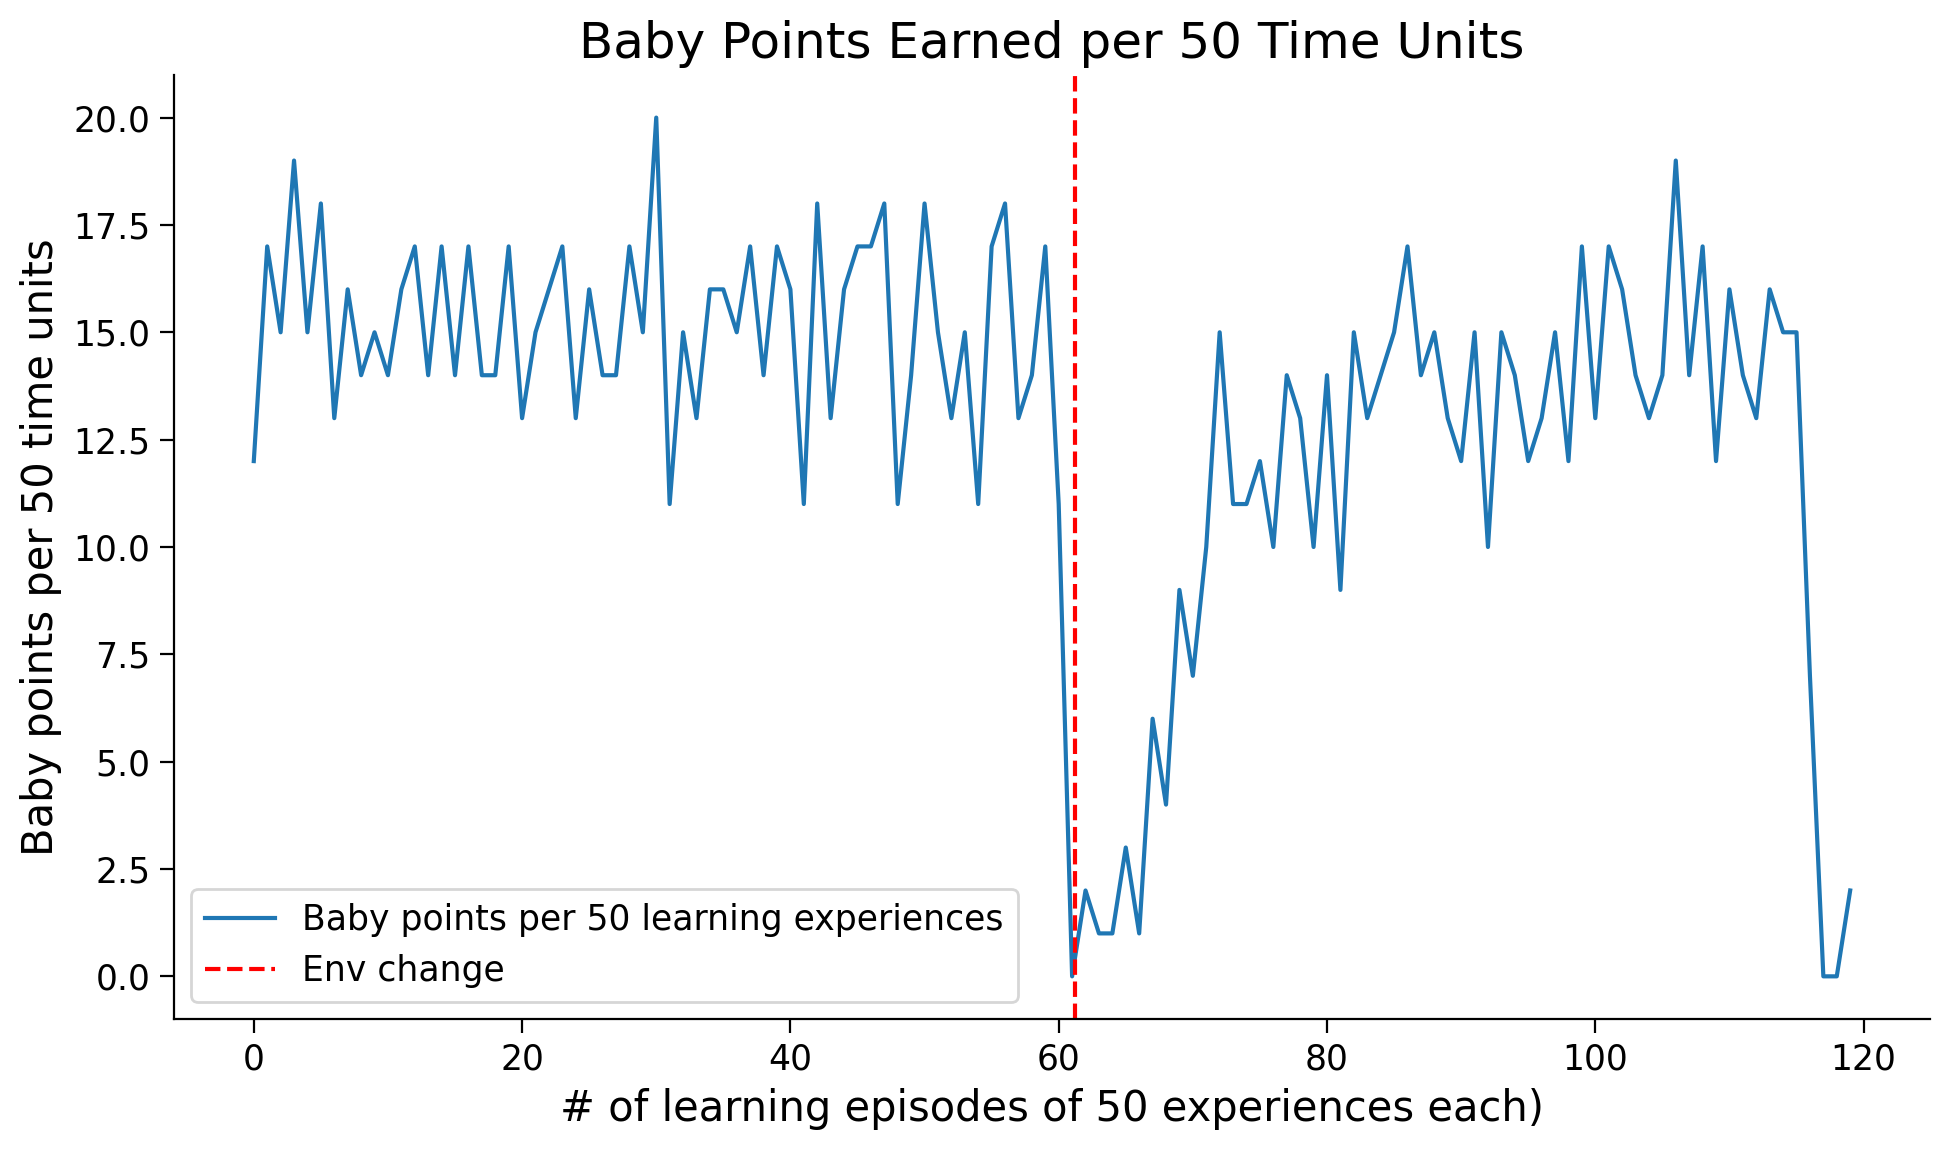

1584


In [ ]:
def learning_loop(n_in = (28 * 28 * 1 + 1), n_out = 2, n_hid = 20,
                  lifespan=6000,
                  X = X_bin, y = y_bin,
                  zero_indices = jnp.where(y_bin == 0)[0],
                  one_indices = jnp.where(y_bin == 1)[0],
                  init_nutritious_type = 0,
                  env_change_freq = 2000,
                  init_policy_params = None,
                  r_params = jnp.array([1, -1.0, -0.01]),
                  reg_param_alpha = 1.0,
                  learning_rates = tuple(jnp.array([0.02]) for _ in range(3)),
                  chunk_size=20,
                  rnd_key=jrandom.key(0),
                  plot_outputs = True):

  size_dummy = jnp.zeros(int(lifespan / 2))
  nutritious_type = jnp.tile(
      jnp.concatenate([jnp.full(env_change_freq, init_nutritious_type),
                       jnp.full(env_change_freq, 1 - init_nutritious_type)]),
      (lifespan // (2 * env_change_freq) + 1,)
  )[:lifespan]
  init_key, grab_key, learn_key = jrandom.split(rnd_key, 3)
  if init_policy_params is None:
    init_policy_params = init_mlp_params(n_in, n_hid, n_out, init_key)
  init_params = (init_policy_params, r_params, reg_param_alpha, learning_rates)
  init_carry = (init_params, learn_key)
  X_gen, image_gen, y_gen = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, grab_key, size_dummy)
  _, (actions, rewards, baby_points, rslps, tts, act_xs) = jax.lax.scan(act_reward_learn_loop_fn, init_carry, (X_gen, y_gen, nutritious_type))
  alive = jnp.cumsum(tts) < lifespan
  total_baby_points = jnp.sum(alive * baby_points)
  masked_confusion = alive[:, None, None] * act_xs
  total_confusion = jnp.sum(masked_confusion, axis=0)
  if plot_outputs:
    baby_points_np = np.array(baby_points)
    tts_np = np.array(tts)
    cum_tts = np.cumsum(tts_np)
    averaged_baby_points = []
    chunk_indices = []
    change_indices = []
    start = 0
    while start < len(cum_tts):
      end = np.searchsorted(cum_tts, cum_tts[start] + chunk_size)
      segment_baby_points = np.sum(baby_points_np[start:end])
      averaged_baby_points.append(segment_baby_points)
      chunk_indices.append((cum_tts[start], cum_tts[end-1]))
      if cum_tts[end-1] >= lifespan:
          break
      start = end
    return np.array(total_baby_points), (np.array(averaged_baby_points), np.array(chunk_indices), cum_tts)
  else:
    return np.array(total_baby_points)

def plot_baby_points(averaged_baby_points, cum_tts, chunk_size, env_change_freq):
  plt.figure(figsize=(10, 6))
  plt.plot(averaged_baby_points, label=f'Baby points per {chunk_size} learning experiences')
  env_change_indices = np.arange(0, len(cum_tts), env_change_freq)
  env_change_points = cum_tts[env_change_indices]
  for change_point in env_change_points[1:-1]:
    plt.axvline(x=(change_point/chunk_size), color='r', linestyle='--', label='Env change' if change_point == env_change_points[1] else "")
  plt.xlabel(f'# of learning episodes of {chunk_size} experiences each)')
  plt.ylabel(f'Baby points per {chunk_size} time units')
  plt.title(f'Baby Points Earned per {chunk_size} Time Units')
  plt.legend()
  plt.show()

chunk_size = 50
env_change_freq = 2005
total_baby_points, (averaged_baby_points, chunk_indices, cum_tts) = learning_loop(
    n_in=(28*28)+1,
    n_out=2,
    n_hid=20,
    lifespan=6000,
    X=X_bin,
    y=y_bin,
    zero_indices=jnp.where(y_bin == 0)[0],
    one_indices=jnp.where(y_bin == 1)[0],
    init_nutritious_type=1,
    env_change_freq = env_change_freq,
    init_policy_params = None,
    r_params = jnp.array([1, -1.0, -0.01]),
    reg_param_alpha = 1.0,
    learning_rates = tuple(jnp.array([0.02]) for _ in range(3)),
    chunk_size=chunk_size,
    rnd_key=jrandom.key(1),
    plot_outputs=True
)

plot_baby_points(averaged_baby_points, cum_tts, chunk_size=chunk_size, env_change_freq = env_change_freq)
print(total_baby_points)

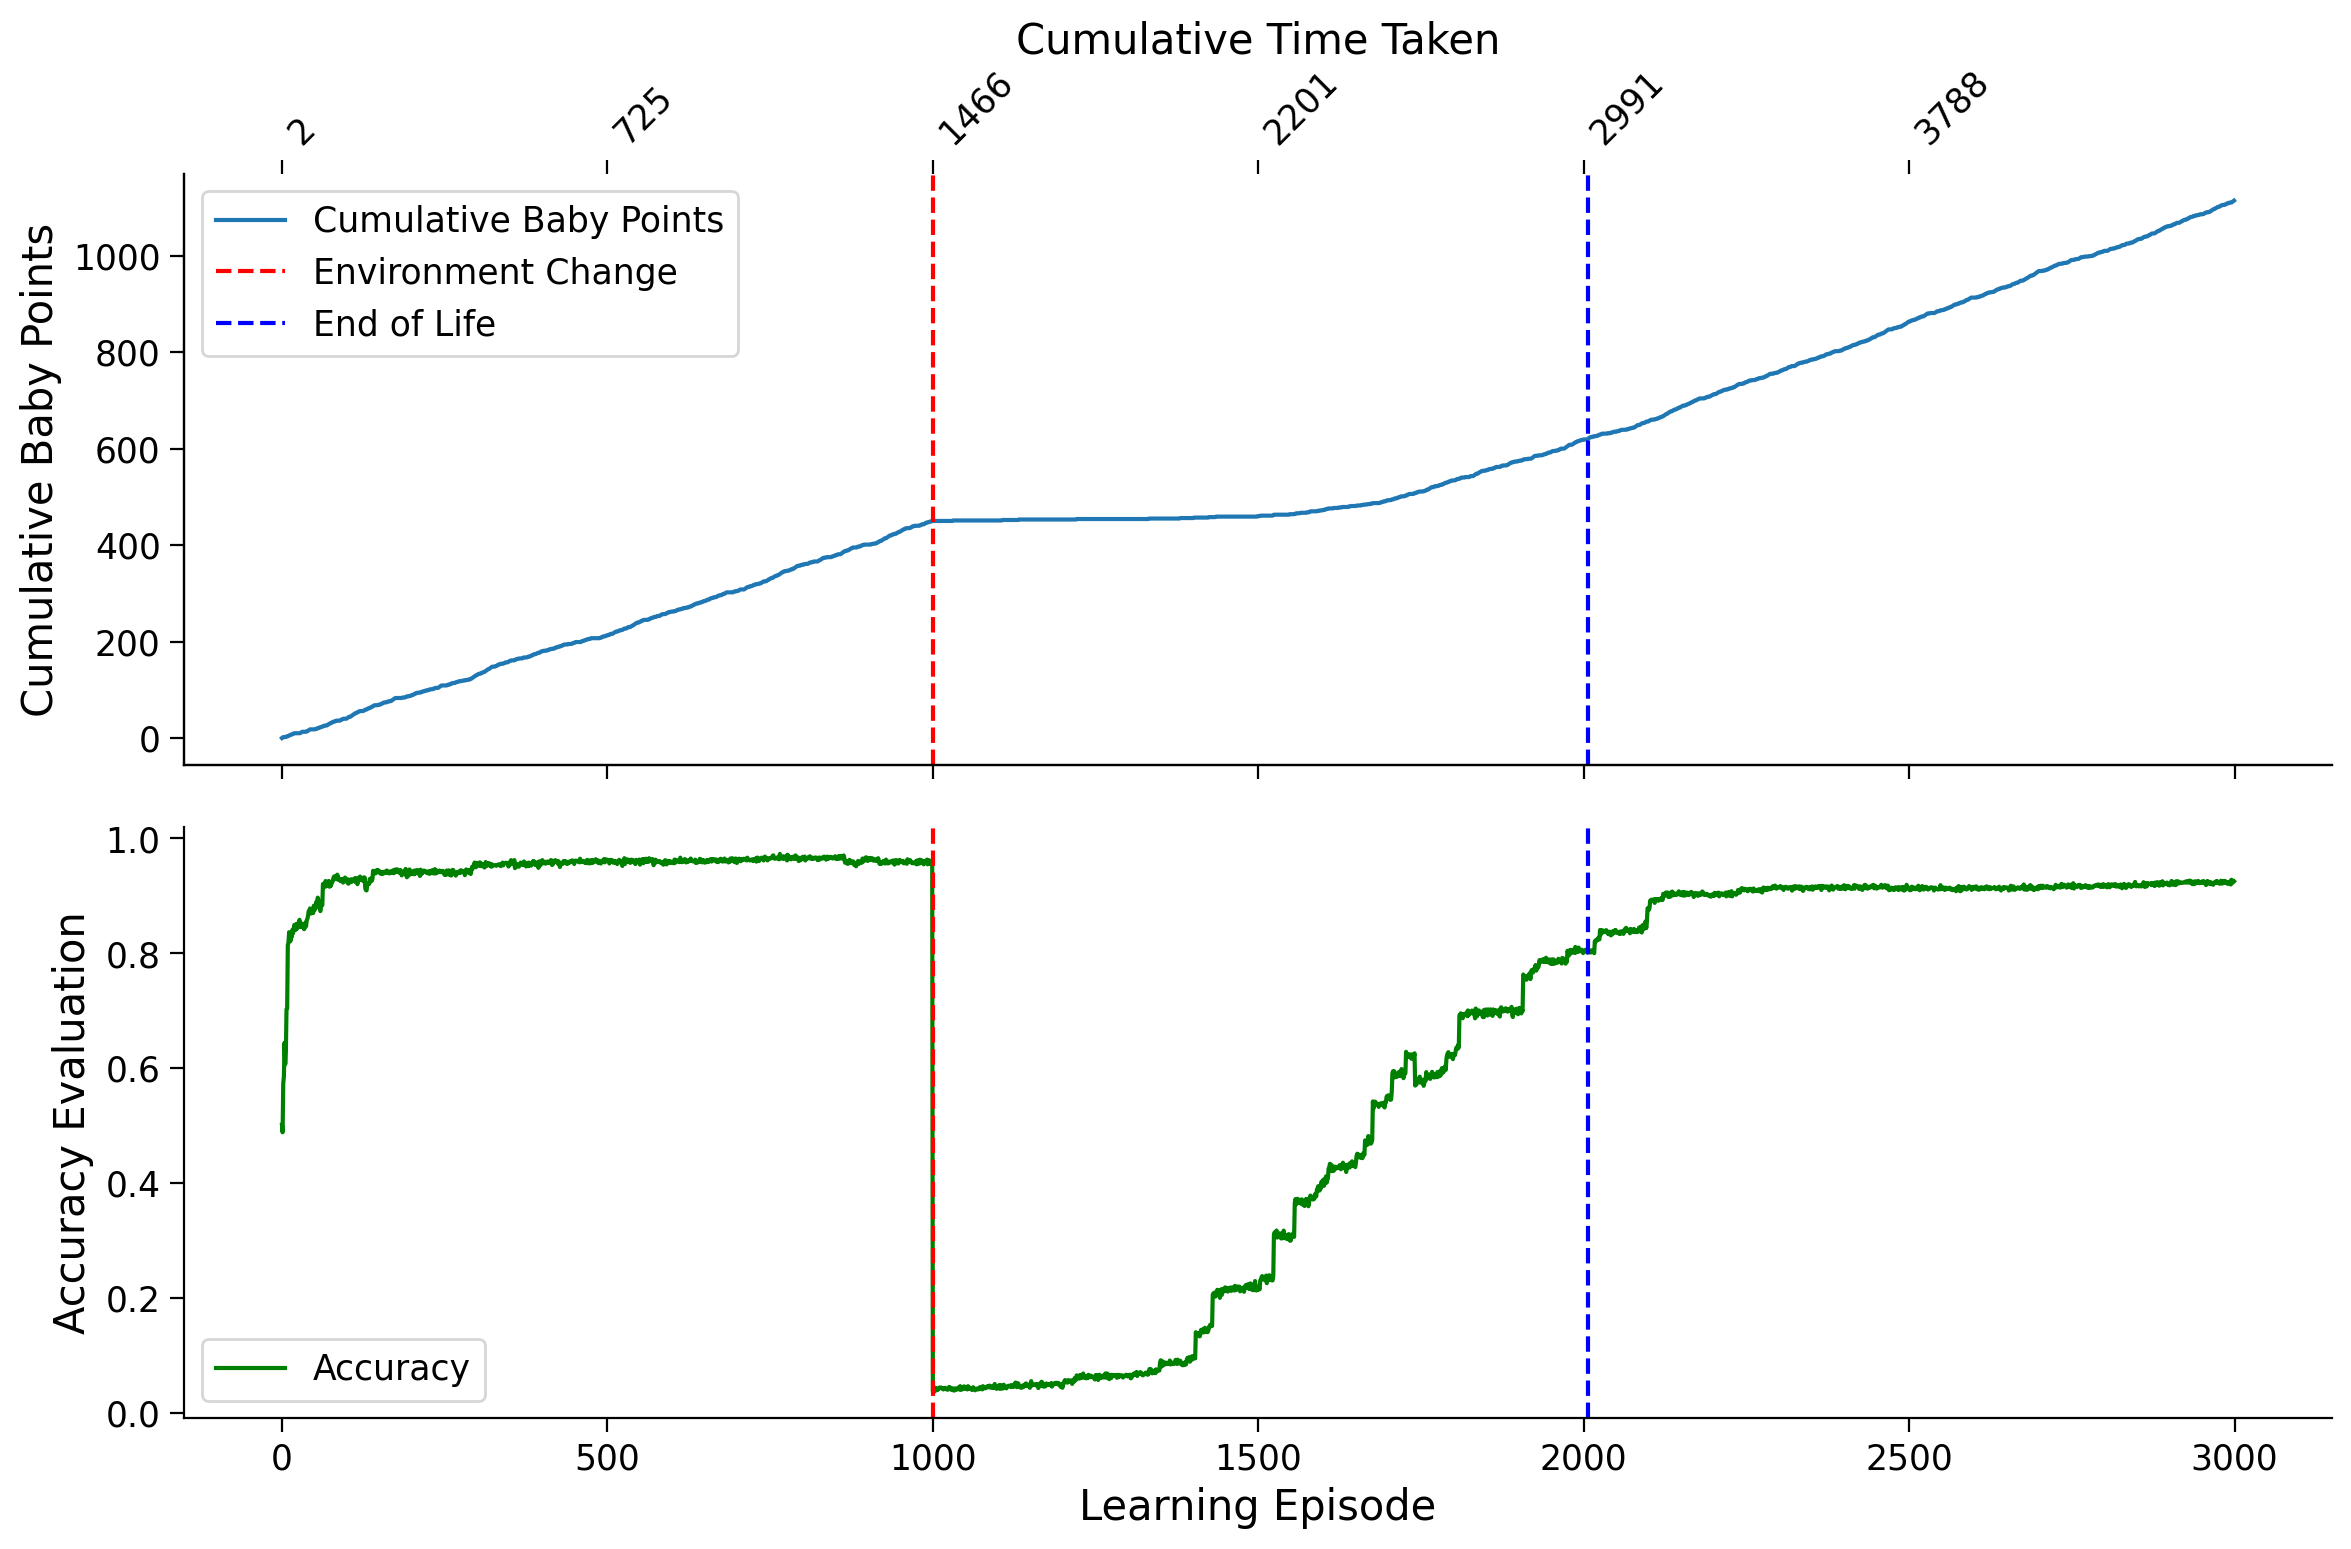

In [ ]:
env_change_freq = 1000
change_type = 'once' # 'once' or 'every'
lifespan = 3000
def learning_eval_loop(n_in = (28 * 28 * 1 + 1), n_out = 2, n_hid = 20,
                       lifespan=lifespan,
                       X = X_bin, y = y_bin,
                       zero_indices = jnp.where(y_bin == 0)[0],
                       one_indices = jnp.where(y_bin == 1)[0],
                       init_nutritious_type = 0,
                       env_change_freq = env_change_freq,
                       change_type = change_type,
                       init_policy_params = None,
                       r_params = jnp.array([1, -1.0, -0.01]),
                       reg_param_alpha = 0.05,
                       learning_rates = tuple(jnp.array([0.02]) for _ in range(3)),
                       chunk_size=20,
                       rnd_key=jrandom.key(0),
                       plot_outputs = True):

  size_dummy = jnp.zeros(int(lifespan / 2))
  if change_type == 'once':
    nutritious_type = jnp.concatenate([
        jnp.full(env_change_freq, init_nutritious_type),
        jnp.full(lifespan - env_change_freq, 1 - init_nutritious_type)
    ])
  elif change_type == 'every':
    nutritious_type = jnp.tile(
        jnp.concatenate([jnp.full(env_change_freq, init_nutritious_type),
                         jnp.full(env_change_freq, 1 - init_nutritious_type)]),
        (lifespan // (2 * env_change_freq) + 1,))[:lifespan]
  else:
    raise ValueError("Invalid change_type, expected 'once' or 'every'")
  init_key, grab_key, learn_key = jrandom.split(rnd_key, 3)
  if init_policy_params is None:
    init_policy_params = init_mlp_params(n_in, n_hid, n_out, init_key)
  init_params = (init_policy_params, r_params, reg_param_alpha, learning_rates)
  X_gen, image_gen, y_gen = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, grab_key, size_dummy)
  init_carry = (init_params, (X_gen, y_gen, lifespan), learn_key)
  _, (actions, rewards, baby_points, obj, tts, act_xs, bp_eval, act_x_eval) = jax.lax.scan(act_reward_learn_eval_loop_fn, init_carry, (X_gen, y_gen, nutritious_type))
  cum_tts = jnp.cumsum(tts)
  return np.array(baby_points), np.array(cum_tts), np.array(bp_eval), np.array(act_x_eval)

baby_points, cum_tt, bp_eval, act_x_eval = learning_eval_loop()

TP = act_x_eval[:, 0, 0]
FP = act_x_eval[:, 0, 1]
FN = act_x_eval[:, 1, 0]
TN = act_x_eval[:, 1, 1]

# Calculate accuracy
accuracy = (TP + TN) / (TP + FP + FN + TN)

# Create subplots with shared x-axis
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot baby points evaluation over time
ax[0].plot(np.cumsum(baby_points), label='Cumulative Baby Points')
ax[0].set_ylabel('Cumulative Baby Points')

# Create a secondary x-axis sharing the same x-axis as the first subplot
ax0_twin = ax[0].twiny()
ax0_twin.set_xlabel('Cumulative Time Taken')
ax0_twin.set_xlim(ax[0].get_xlim())
xticks = ax[0].get_xticks()
valid_ticks = [int(tick) for tick in xticks if 0 <= int(tick) < len(cum_tt)]
ax0_twin.set_xticks(valid_ticks)
ax0_twin.set_xticklabels([f'{cum_tt[int(tick)]}' for tick in valid_ticks], rotation=45, ha='left')

# Plot accuracy over time
ax[1].plot(accuracy, label='Accuracy', color='green')
ax[1].set_xlabel('Learning Episode')
ax[1].set_ylabel('Accuracy Evaluation')

# Add vertical lines for environment changes and end of life
if change_type == 'once':
  ax[0].axvline(x=env_change_freq, color='r', linestyle='--', label='Environment Change')
  ax[1].axvline(x=env_change_freq, color='r', linestyle='--')
elif change_type == 'every':
  for env_change in range(env_change_freq, len(baby_points), env_change_freq):
    ax[0].axvline(x=env_change, color='r', linestyle='--', label='Environment Change' if env_change == env_change_freq else "")
    ax[1].axvline(x=env_change, color='r', linestyle='--')
else:
  raise ValueError("Invalid change_type, expected 'once' or 'every'")

# Mark the end of the organism's life
end_life = np.argmin(cum_tt < lifespan)
ax[0].axvline(x=end_life, color='b', linestyle='--', label='End of Life')
ax[1].axvline(x=end_life, color='b', linestyle='--', )
ax[0].legend()
ax[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Reversal learning is slow. It takes a long time learn to switch from one kind to the other... though over many re

policy_params type: <class 'tuple'>
r_params type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>
learning_rates type: <class 'tuple'>
reg_param_alpha type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>
<class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>


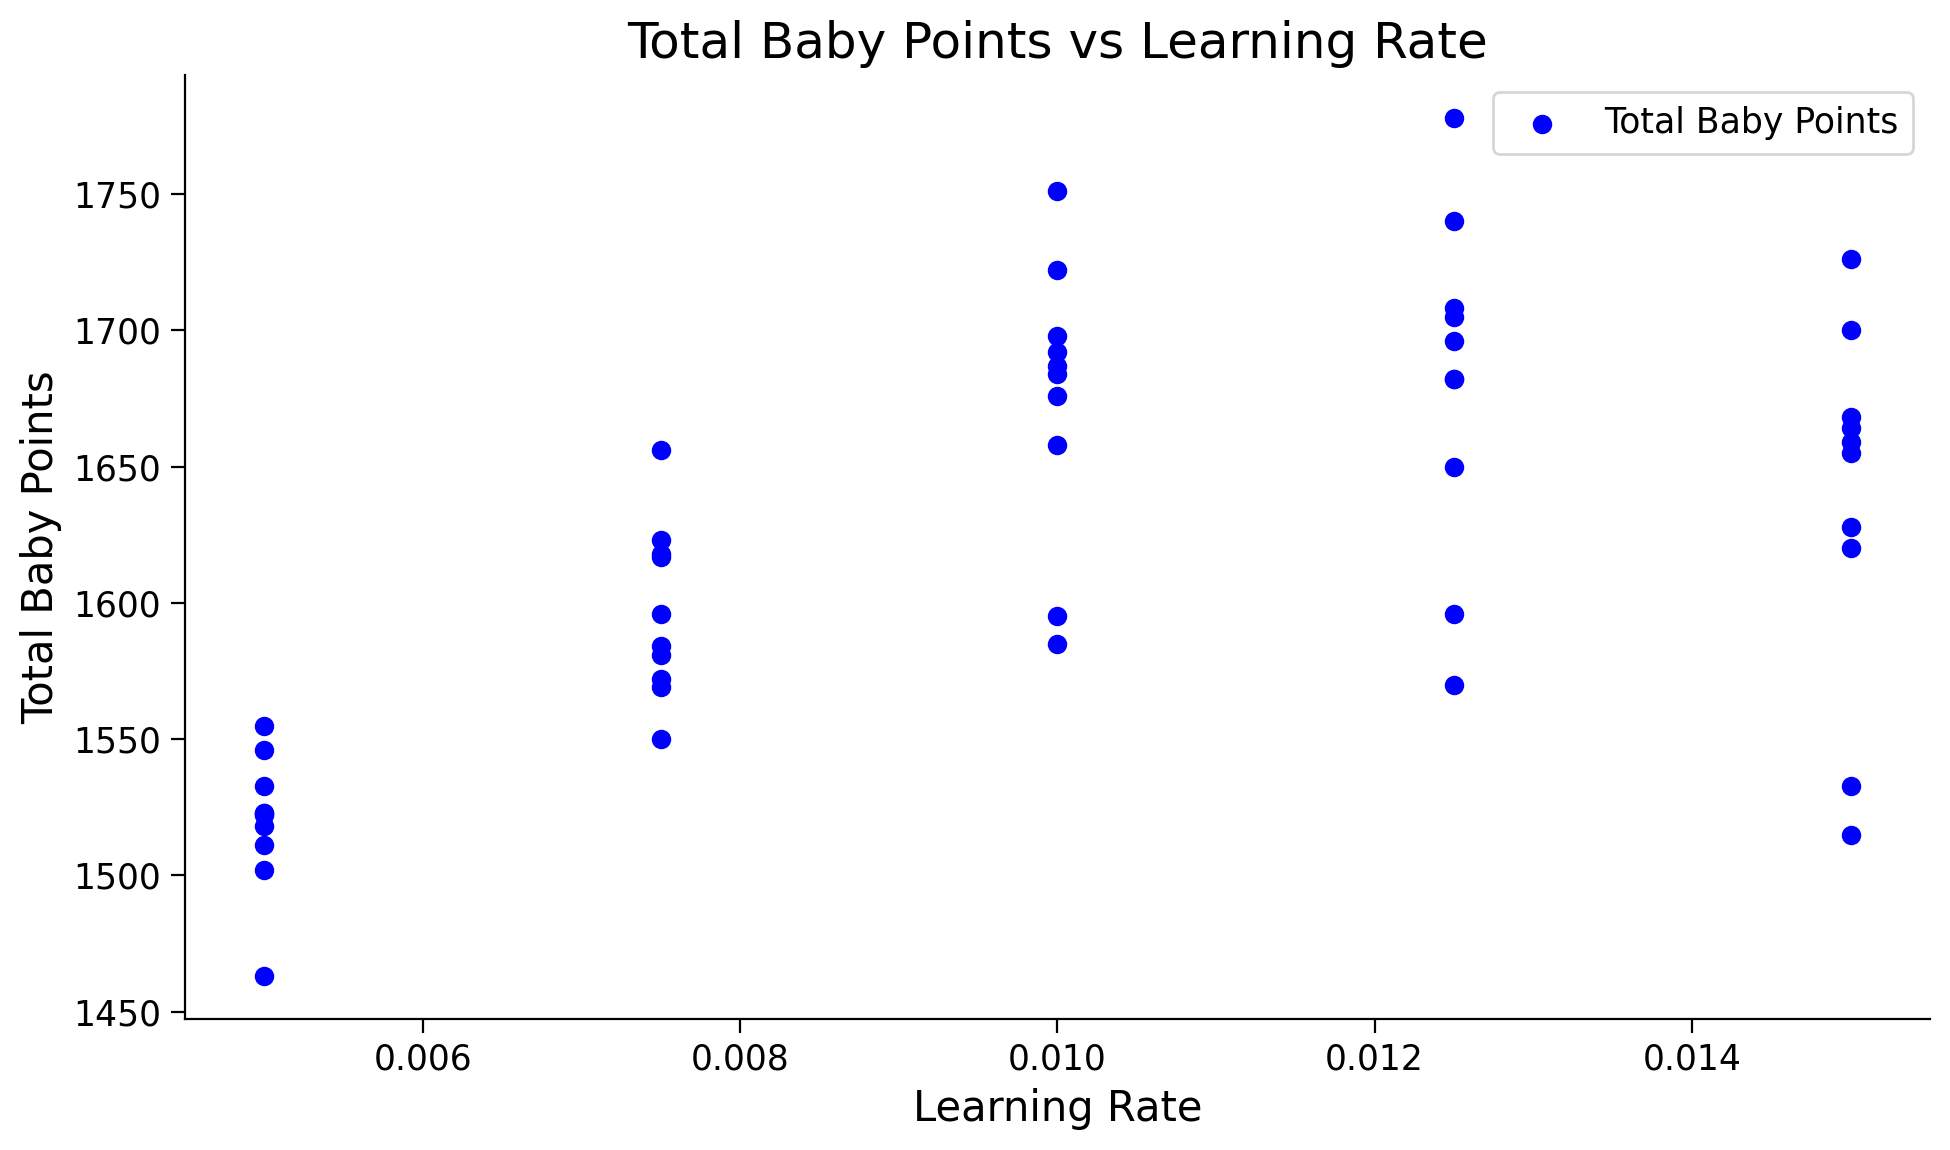

In [ ]:
learning_rates = [0.0150, 0.0125, 0.01, 0.0075, 0.005]
seeds = range(10)

results = []
for learning_rate in learning_rates:
  for seed in seeds:
    rnd_key = jrandom.PRNGKey(seed)
    total_baby_points = learning_loop(
      learning_rate=learning_rate,
      rnd_key=rnd_key,
      plot_outputs=False)
    results.append((learning_rate, seed, total_baby_points))


def plot_dial_in_results(results):
  learning_rates = [result[0] for result in results]
  baby_points = [result[2] for result in results]
  plt.figure(figsize=(10, 6))
  plt.scatter(learning_rates, baby_points, c='blue', label='Total Baby Points')
  plt.xlabel('Learning Rate')
  plt.ylabel('Total Baby Points')
  plt.title('Total Baby Points vs Learning Rate')
  plt.legend()
  plt.show()

plot_dial_in_results(results)


Now that we know that one learner works, let's simulate a population of them with evolving parameter initializations.

In [ ]:
def evaluate_learning_individual_carry_fn(carry, individual_params):
  rnd_key, X, y, nt, lifespan = carry
  rnd_key, eval_key = jrandom.split(rnd_key)
  init_eval_carry = (individual_params, eval_key)
  # this scan iterates through the data/environment for a single learning individual
  _, (actions, rewards, baby_points, rslps, tts, act_xs) = jax.lax.scan(act_reward_learn_loop_fn, init_eval_carry, (X, y, nt))
  cum_tt = jnp.cumsum(tts)
  alive = cum_tt < lifespan
  total_baby_points = jnp.sum(alive * baby_points)
  masked_confusion = alive[:, None, None] * act_xs
  total_confusion = jnp.sum(masked_confusion, axis=0)
  carry = (rnd_key, X, y, nt, lifespan)
  return carry, (total_baby_points, total_confusion)

def evaluate_learning_population(pop_params, X, y, nutritious_type, lifespan, rnd_key):
  init_carry = (rnd_key, X, y, nutritious_type, lifespan)
  # the carry is actually just stuff that is the same for every individual, this is really
  # just about fast iteration through the population, and using the carry is cleaner than
  # using globals
  _, (fitness_scores, act_xs) = lax.scan(evaluate_learning_individual_carry_fn, init_carry, pop_params)
  return fitness_scores, act_xs

def init_learning_pop_params(pop_size, n_in, n_hid, n_out, rnd_key,
                             r_params = [1, -1, -0.01],
                             reg_param_alpha = 0.1,
                             learning_rates = [0.01, 0.01, 0.01]):
  k1, k2, k3 = jrandom.split(rnd_key, 3)
  norm = jnp.sqrt(2 / (n_out + n_in + n_hid))
  pop_W1 = jrandom.normal(k1, (pop_size, n_hid, n_in)) * norm
  pop_W2 = jrandom.normal(k2, (pop_size, n_out, n_hid)) * norm
  pop_Ws = jrandom.normal(k3, (pop_size, n_out, n_in)) * norm
  init_policy_params = init_mlp_params(n_in, n_hid, n_out, rnd_key)

  # Initialize reward parameters
  pop_r_params = jnp.tile(jnp.array(r_params), (pop_size, 1))
  pop_reg_param_alpha = jnp.full((pop_size,), jnp.array(reg_param_alpha))
  # Initialize learning rates
  pop_lr_W1 = jnp.full((pop_size,), learning_rates[0])
  pop_lr_W2 = jnp.full((pop_size,), learning_rates[1])
  pop_lr_Ws = jnp.full((pop_size,), learning_rates[2])
  return ((pop_W1, pop_W2, pop_Ws), pop_r_params, pop_reg_param_alpha, (pop_lr_W1, pop_lr_W2, pop_lr_Ws))

@jit
def select_params(pop_params, selected_indices):
  def select_fn(param):
    return param[selected_indices]
  selected_params = jax.tree_util.tree_map(select_fn, pop_params)
  return selected_params

def generate_mut_structured_rnd_key(key, mut_scales):
  flat_structure, treedef = jax.tree_util.tree_flatten(mut_scales)
  num_elements = len(flat_structure)
  subkeys = jax.random.split(key, num_elements)
  mut_structured_rnd_keys = jax.tree_util.tree_unflatten(treedef, subkeys)
  return mut_structured_rnd_keys

@jit
def mutate_learning_pop_params(pop_params, rnd_key, mut_scales):
  def mutate_fn(param, mut_scale, mut_key):
    return param + jrandom.normal(mut_key, param.shape) * mut_scale
  mut_keys_tree = generate_mut_structured_rnd_key(rnd_key, mut_scales)
  mutated_params = jax.tree_util.tree_map(mutate_fn, pop_params, mut_scales, mut_keys_tree)
  mutated_params[1]
  return mutated_params

def run_evo_learning_simulation(
  num_generations=100,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  env_change_type='within_lifetime', # 'across_generations'
  within_lifetime_change_type='once', # 'every'
  env_change_freq=1000,
  # tree strcutire
  # (W1_init, W2_init, Ws_init), rewards, entropy_regulization_weight, (W1_lr, W2_lr, Ws_l3))
  mut_scale=((jnp.array([0.002]), jnp.array([0.002]), jnp.array([0.002])), jnp.array([0.001]), jnp.array([0.001]), (jnp.array([0.0001]), jnp.array([0.0001]), jnp.array([0.0001]))),
  r_params = [1, -1, -0.01],
  reg_param_alpha = [1.0],
  learning_rates = [0.01, 0.01, 0.01],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin):

  zero_indices = jnp.where(y == 0)[0]
  one_indices = jnp.where(y == 1)[0]
  size_dummy = jnp.zeros(int(lifespan / 2))
  rnd_key, init_key = jrandom.split(rnd_key)
  pop_params = init_learning_pop_params(pop_size, n_in, n_hid, n_out, rnd_key,
                                        r_params=r_params,
                                        reg_param_alpha=reg_param_alpha,
                                        learning_rates=learning_rates)
  rnd_key, nut_key = jrandom.split(rnd_key)
  init_nutritious_type = jrandom.choice(nut_key, jnp.array([0, 1]))
  if env_change_type == 'within_lifetime':
      assert lifespan % env_change_freq == 0
  elif env_change_type == 'across_generations':
      nutritious_type = jnp.tile(jnp.array([init_nutritious_type]), (lifespan,))
  else:
      raise ValueError(f"Invalid env_change_type: {env_change_type}")
  fitness_history = []
  start_time = time.time()
  for g in range(num_generations):
    gen_start_time = time.time()
    if env_change_type == 'within_lifetime':
      rnd_key, nut_key = jrandom.split(rnd_key)
      if within_lifetime_change_type == 'once':
        nutritious_type = jnp.concatenate([jnp.full(env_change_freq, init_nutritious_type), jnp.full(lifespan - env_change_freq, 1 - init_nutritious_type)])
      elif within_lifetime_change_type == 'every':
        nutritious_type = jnp.tile(jnp.concatenate([jnp.full(env_change_freq, init_nutritious_type), jnp.full(env_change_freq, 1 - init_nutritious_type)]), (lifespan // (2 * env_change_freq) + 1,))[:lifespan]
      else:
        raise ValueError(f"Invalid within_lifetime_change_type: {within_lifetime_change_type}, expected 'once' or  'every")
    else: #
      if g % env_change_freq == 0:
        nutritious_type = 1 - nutritious_type
    rnd_key, grab_key, eval_key, sel_key, mut_key = jrandom.split(rnd_key, 5)
    X_gen, image_gen, y_gen = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, grab_key, size_dummy)
    fitness_scores, act_xs = evaluate_learning_population(pop_params, X_gen, y_gen, nutritious_type, lifespan, eval_key)
    parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
    unique_parents_count = len(jnp.unique(parent_indices))
    if g == 0:
      best_idx = jnp.argmax(fitness_scores)
      best_params_start = select_params(pop_params, best_idx)
      med_idx = median_index(fitness_scores)
      med_params_start = select_params(pop_params, best_idx)
    elif g == num_generations - 1:
      best_idx = jnp.argmax(fitness_scores)
      best_params_end = select_params(pop_params, best_idx)
      med_idx = median_index(fitness_scores)
      med_params_end = select_params(pop_params, med_idx)
    parent_params = select_params(pop_params, parent_indices)
    pop_params = mutate_learning_pop_params(parent_params, mut_key, mut_scale)
    fitness_history.append({
        'generation': g,
        'mean_fitness': jnp.mean(fitness_scores).item(),
        'std_dev_fitness': jnp.std(fitness_scores).item(),
        'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
        'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
        'unique_parents_count': unique_parents_count,
    })
    gen_time = time.time() - gen_start_time
    total_elapsed_time = time.time() - start_time
    if g % print_freq == 0:
        current_gen_data = fitness_history[-1]
        parent_mask = jnp.zeros(pop_size, dtype=bool).at[parent_indices].set(True)
        selected_fitness = fitness_scores[parent_mask]
        not_selected_fitness = fitness_scores[~parent_mask]
        mean_selected_fitness = jnp.mean(selected_fitness)
        mean_not_selected_fitness = jnp.mean(not_selected_fitness)
        print(f"Gen: {g}/{num_generations} | Avg Fit: {current_gen_data['mean_fitness']:.2f} |Avg Fit Sel: {mean_selected_fitness:.2f} | Avg Fit Not-Sel: {mean_not_selected_fitness:.2f} | Proportion of Pop Selected: {current_gen_data['unique_parents_count'] / pop_size:.4f} |Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")
        #print('Confusion matrix of best individual:')
        #best_idx = jnp.argmax(fitness_scores)
        #print(act_xs[best_idx])
  return fitness_history, (best_params_start, med_params_start, best_params_end, med_params_end, X_gen, image_gen, y_gen)


Sanity check 1, mutation alone (v. low learning rate) still works, the environment is not changing, discrimination slowly emerges through evolution (mutation + selective reproduction) of initial params, learning is doing nothing.

Gen: 0/10 | Avg Fit: 503.12 |Avg Fit Sel: 707.00 | Avg Fit Not-Sel: 498.96 | Proportion of Pop Selected: 0.0200 |Gen Time: 4.25s | Total Time: 4.25s
Gen: 1/10 | Avg Fit: 687.40 |Avg Fit Sel: 722.00 | Avg Fit Not-Sel: 685.96 | Proportion of Pop Selected: 0.0400 |Gen Time: 4.13s | Total Time: 8.38s
Gen: 2/10 | Avg Fit: 682.24 |Avg Fit Sel: 716.00 | Avg Fit Not-Sel: 680.09 | Proportion of Pop Selected: 0.0600 |Gen Time: 2.70s | Total Time: 11.09s
Gen: 3/10 | Avg Fit: 699.66 |Avg Fit Sel: 731.00 | Avg Fit Not-Sel: 699.02 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.71s | Total Time: 13.80s
Gen: 4/10 | Avg Fit: 714.50 |Avg Fit Sel: 744.00 | Avg Fit Not-Sel: 712.62 | Proportion of Pop Selected: 0.0600 |Gen Time: 2.70s | Total Time: 16.50s
Gen: 5/10 | Avg Fit: 737.74 |Avg Fit Sel: 760.25 | Avg Fit Not-Sel: 735.78 | Proportion of Pop Selected: 0.0800 |Gen Time: 2.70s | Total Time: 19.20s
Gen: 6/10 | Avg Fit: 747.26 |Avg Fit Sel: 792.00 | Avg Fit Not-Sel: 746.35 | Proportion of Pop Selecte

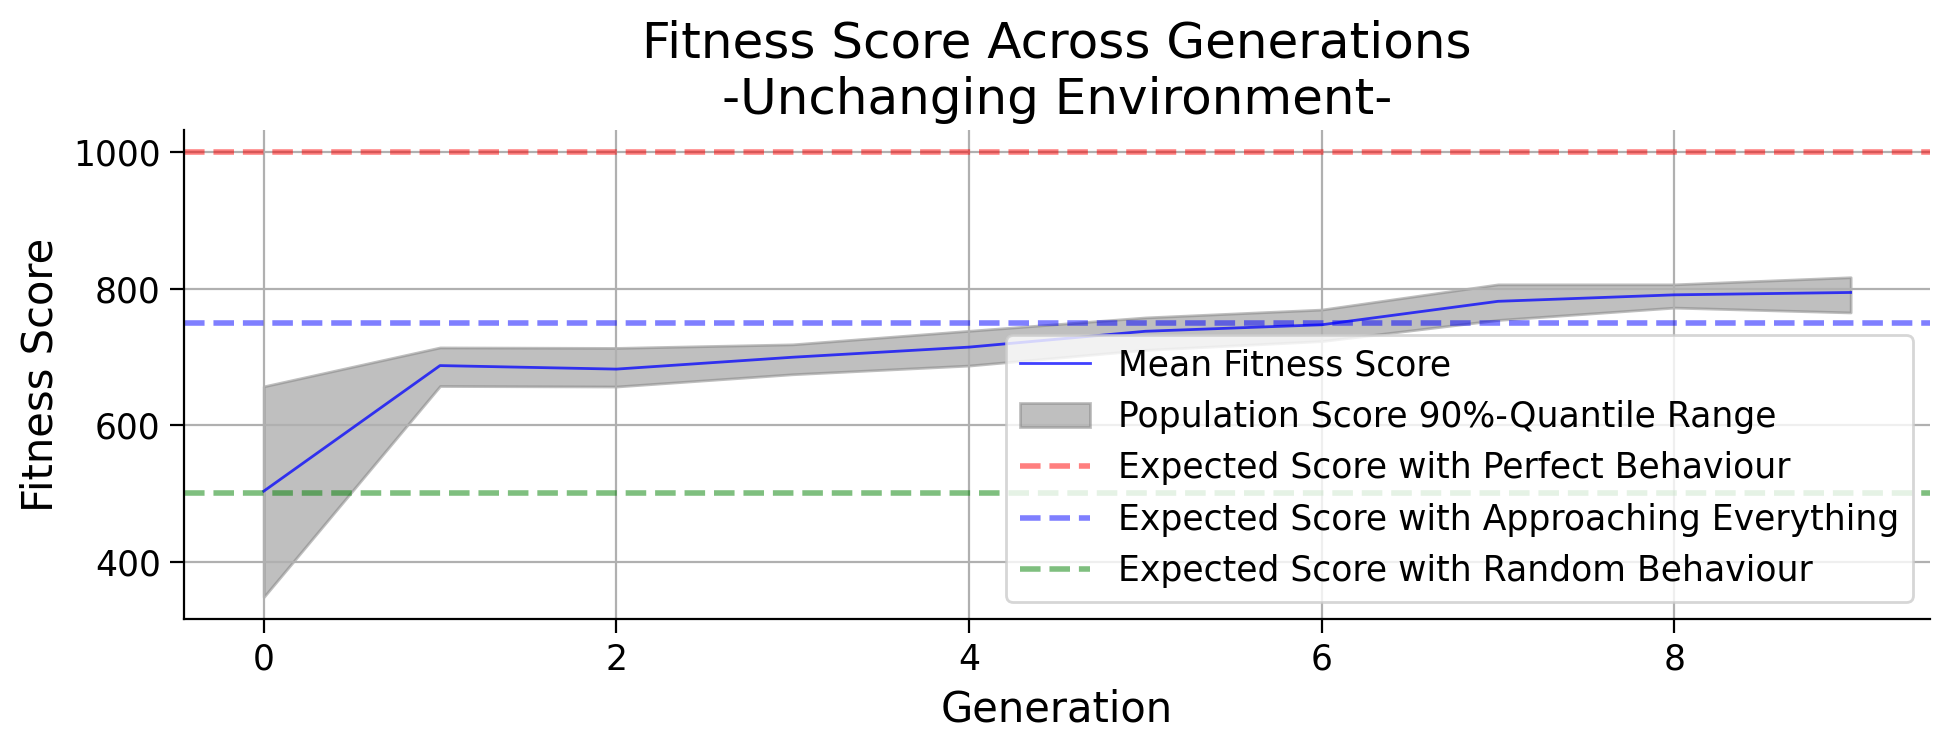

In [ ]:
fitness_history, _ = run_evo_learning_simulation(
  num_generations=10,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  env_change_type='across_generations',
  within_lifetime_change_type='once',
  env_change_freq=500,
  mut_scale=((jnp.array([0.01]), jnp.array([0.01]), jnp.array([0.01])),
             jnp.array([0.0]),
             jnp.array([0.0]),
             (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0]))),
  r_params=[1, -1, -0.01],
  learning_rates=[0.0000000001, 0.0000000001, 0.0000000001],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin)


plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Unchanging', window_size=1)

Sanity check 2, learning alone (very low mutation rate) still works. Mutation scale is super small, so initialization stays basically random.

Gen: 0/10 | Avg Fit: 954.52 |Avg Fit Sel: 961.38 | Avg Fit Not-Sel: 953.21 | Proportion of Pop Selected: 0.1600 |Gen Time: 2.75s | Total Time: 2.75s
Gen: 1/10 | Avg Fit: 952.96 |Avg Fit Sel: 957.93 | Avg Fit Not-Sel: 950.83 | Proportion of Pop Selected: 0.3000 |Gen Time: 2.71s | Total Time: 5.46s
Gen: 2/10 | Avg Fit: 943.04 |Avg Fit Sel: 947.46 | Avg Fit Not-Sel: 941.49 | Proportion of Pop Selected: 0.2600 |Gen Time: 2.72s | Total Time: 8.19s
Gen: 3/10 | Avg Fit: 944.92 |Avg Fit Sel: 949.85 | Avg Fit Not-Sel: 943.19 | Proportion of Pop Selected: 0.2600 |Gen Time: 2.76s | Total Time: 10.95s
Gen: 4/10 | Avg Fit: 940.64 |Avg Fit Sel: 947.88 | Avg Fit Not-Sel: 939.26 | Proportion of Pop Selected: 0.1600 |Gen Time: 2.85s | Total Time: 13.80s
Gen: 5/10 | Avg Fit: 942.56 |Avg Fit Sel: 947.73 | Avg Fit Not-Sel: 940.34 | Proportion of Pop Selected: 0.3000 |Gen Time: 2.88s | Total Time: 16.68s
Gen: 6/10 | Avg Fit: 948.16 |Avg Fit Sel: 953.50 | Avg Fit Not-Sel: 947.14 | Proportion of Pop Selected

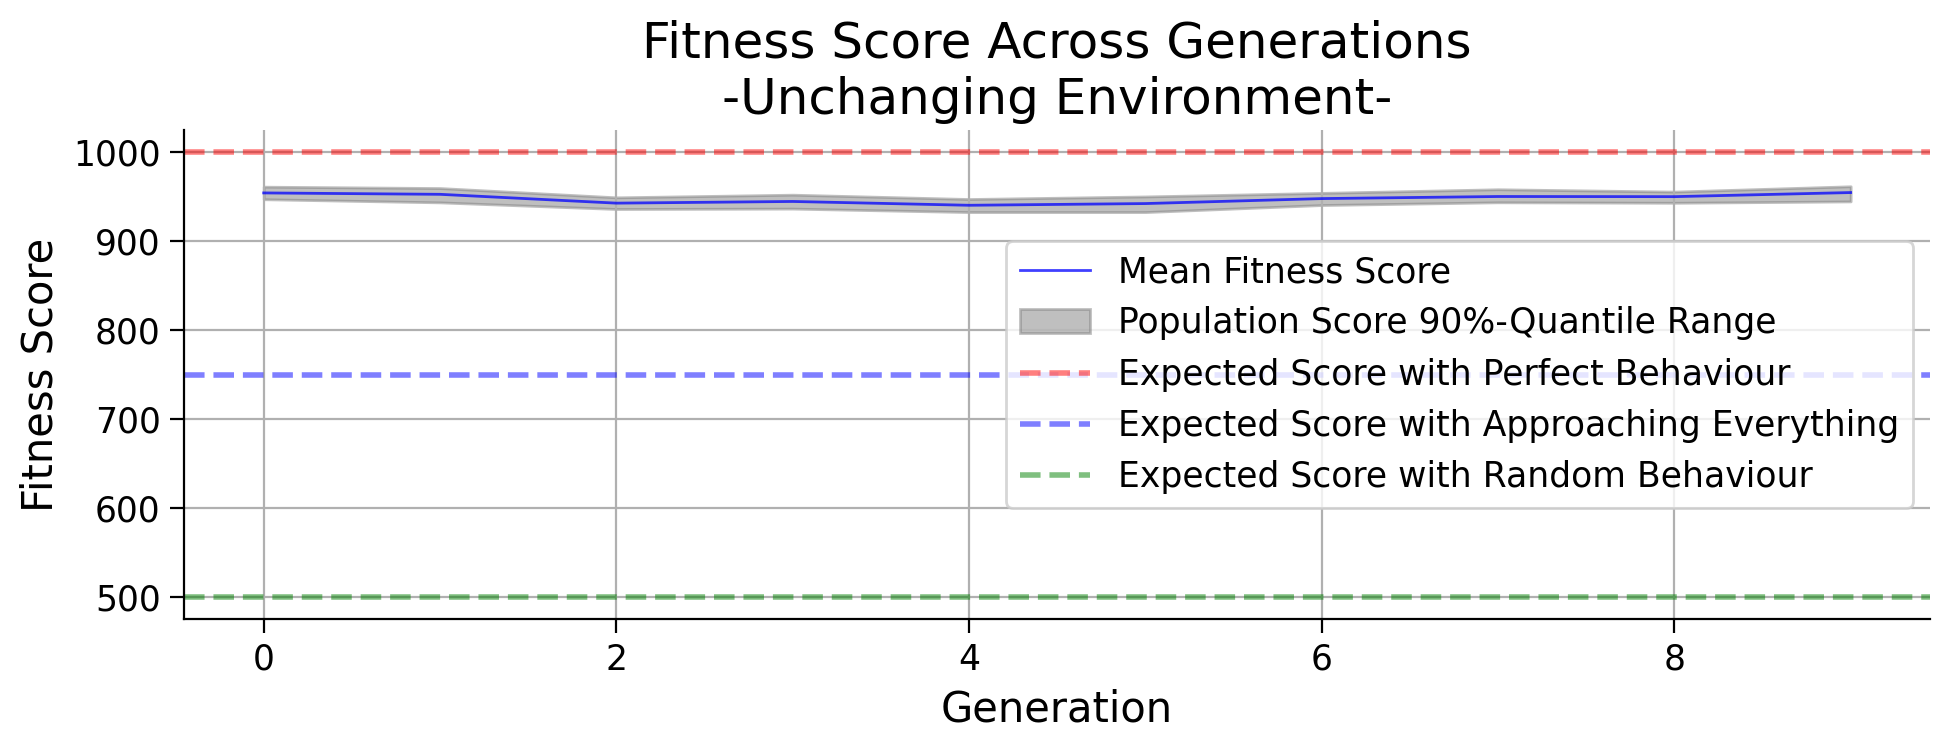

In [ ]:
fitness_history, _ = run_evo_learning_simulation(
  num_generations=10,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  env_change_type='across_generations',
  within_lifetime_change_type='once',
  env_change_freq=500,
  mut_scale=((jnp.array([0.0000000001]), jnp.array([0.0000000001]), jnp.array([0.0000000001])),
             jnp.array([0.0]),
             jnp.array([0.0]),
             (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0]))),
  r_params=[1, -1, -0.01],
  reg_param_alpha=[0.1],
  learning_rates=[0.01, 0.01, 0.01],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin)


plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Unchanging', window_size=1)

So when there is no change in the env, learning is just as good basically as evo by itself, but what about in a rapidly changing environment, that's this next simulation.

Gen: 0/10 | Avg Fit: 954.52 |Avg Fit Sel: 961.38 | Avg Fit Not-Sel: 953.21 | Proportion of Pop Selected: 0.1600 |Gen Time: 2.75s | Total Time: 2.75s
Gen: 1/10 | Avg Fit: 921.20 |Avg Fit Sel: 931.50 | Avg Fit Not-Sel: 919.24 | Proportion of Pop Selected: 0.1600 |Gen Time: 2.70s | Total Time: 5.45s
Gen: 2/10 | Avg Fit: 942.18 |Avg Fit Sel: 948.89 | Avg Fit Not-Sel: 940.71 | Proportion of Pop Selected: 0.1800 |Gen Time: 2.70s | Total Time: 8.16s
Gen: 3/10 | Avg Fit: 946.24 |Avg Fit Sel: 952.36 | Avg Fit Not-Sel: 944.51 | Proportion of Pop Selected: 0.2200 |Gen Time: 2.70s | Total Time: 10.86s
Gen: 4/10 | Avg Fit: 941.80 |Avg Fit Sel: 944.74 | Avg Fit Not-Sel: 940.00 | Proportion of Pop Selected: 0.3800 |Gen Time: 2.70s | Total Time: 13.56s
Gen: 5/10 | Avg Fit: 929.92 |Avg Fit Sel: 940.33 | Avg Fit Not-Sel: 928.50 | Proportion of Pop Selected: 0.1200 |Gen Time: 2.70s | Total Time: 16.26s
Gen: 6/10 | Avg Fit: 946.68 |Avg Fit Sel: 952.36 | Avg Fit Not-Sel: 945.08 | Proportion of Pop Selected

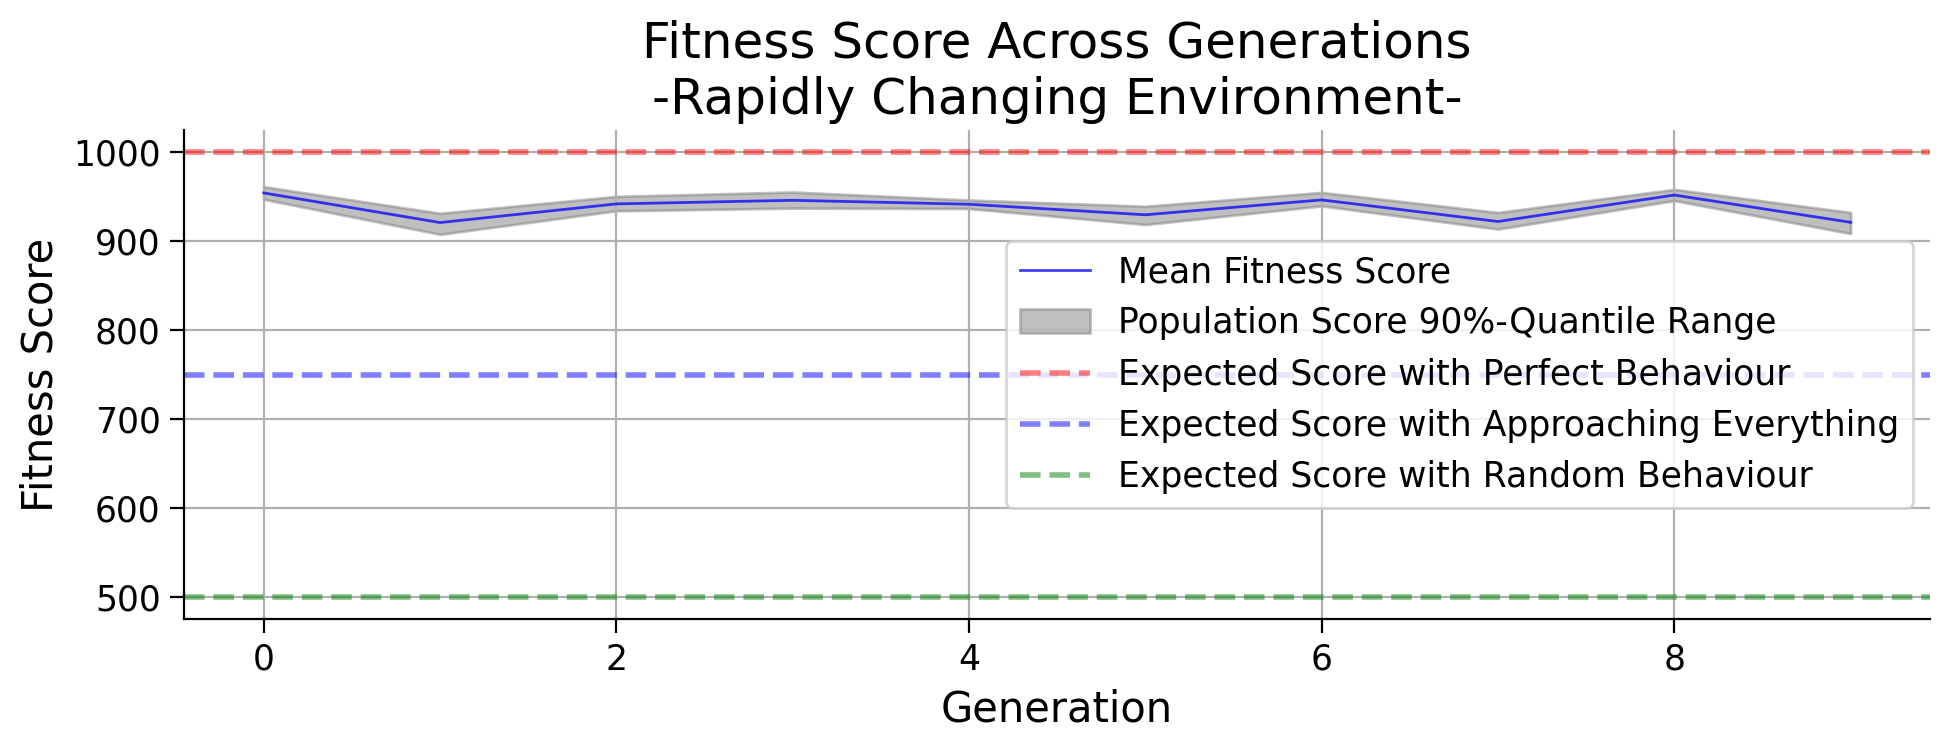

In [ ]:
fitness_history, _ = run_evo_learning_simulation(
  num_generations=10,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  env_change_type='across_generations',
  within_lifetime_change_type='once',
  env_change_freq=1,
  mut_scale=((jnp.array([0.01]), jnp.array([0.01]), jnp.array([0.01])), jnp.array([0.0]), jnp.array([0.0]), (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0]))),
  r_params=[1, -1, -0.01],
  reg_param_alpha=[0.1],
  learning_rates=[0.01, 0.01, 0.01],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin)


plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Rapidly Changing', window_size=1)

So learning handles a changing environment with basically no problem.
What about when there is change within the organism's lifetimes?!?

Gen: 0/20 | Avg Fit: 643.54 |Avg Fit Sel: 787.00 | Avg Fit Not-Sel: 640.61 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.69s | Total Time: 2.69s
Gen: 1/20 | Avg Fit: 736.84 |Avg Fit Sel: 862.00 | Avg Fit Not-Sel: 734.29 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.68s | Total Time: 5.38s
Gen: 2/20 | Avg Fit: 674.72 |Avg Fit Sel: 850.00 | Avg Fit Not-Sel: 671.14 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.68s | Total Time: 8.06s
Gen: 3/20 | Avg Fit: 667.30 |Avg Fit Sel: 867.00 | Avg Fit Not-Sel: 663.22 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.68s | Total Time: 10.74s
Gen: 4/20 | Avg Fit: 662.90 |Avg Fit Sel: 777.00 | Avg Fit Not-Sel: 658.15 | Proportion of Pop Selected: 0.0400 |Gen Time: 2.68s | Total Time: 13.41s
Gen: 5/20 | Avg Fit: 642.20 |Avg Fit Sel: 826.00 | Avg Fit Not-Sel: 638.45 | Proportion of Pop Selected: 0.0200 |Gen Time: 2.68s | Total Time: 16.09s
Gen: 6/20 | Avg Fit: 679.04 |Avg Fit Sel: 845.00 | Avg Fit Not-Sel: 675.65 | Proportion of Pop Selected

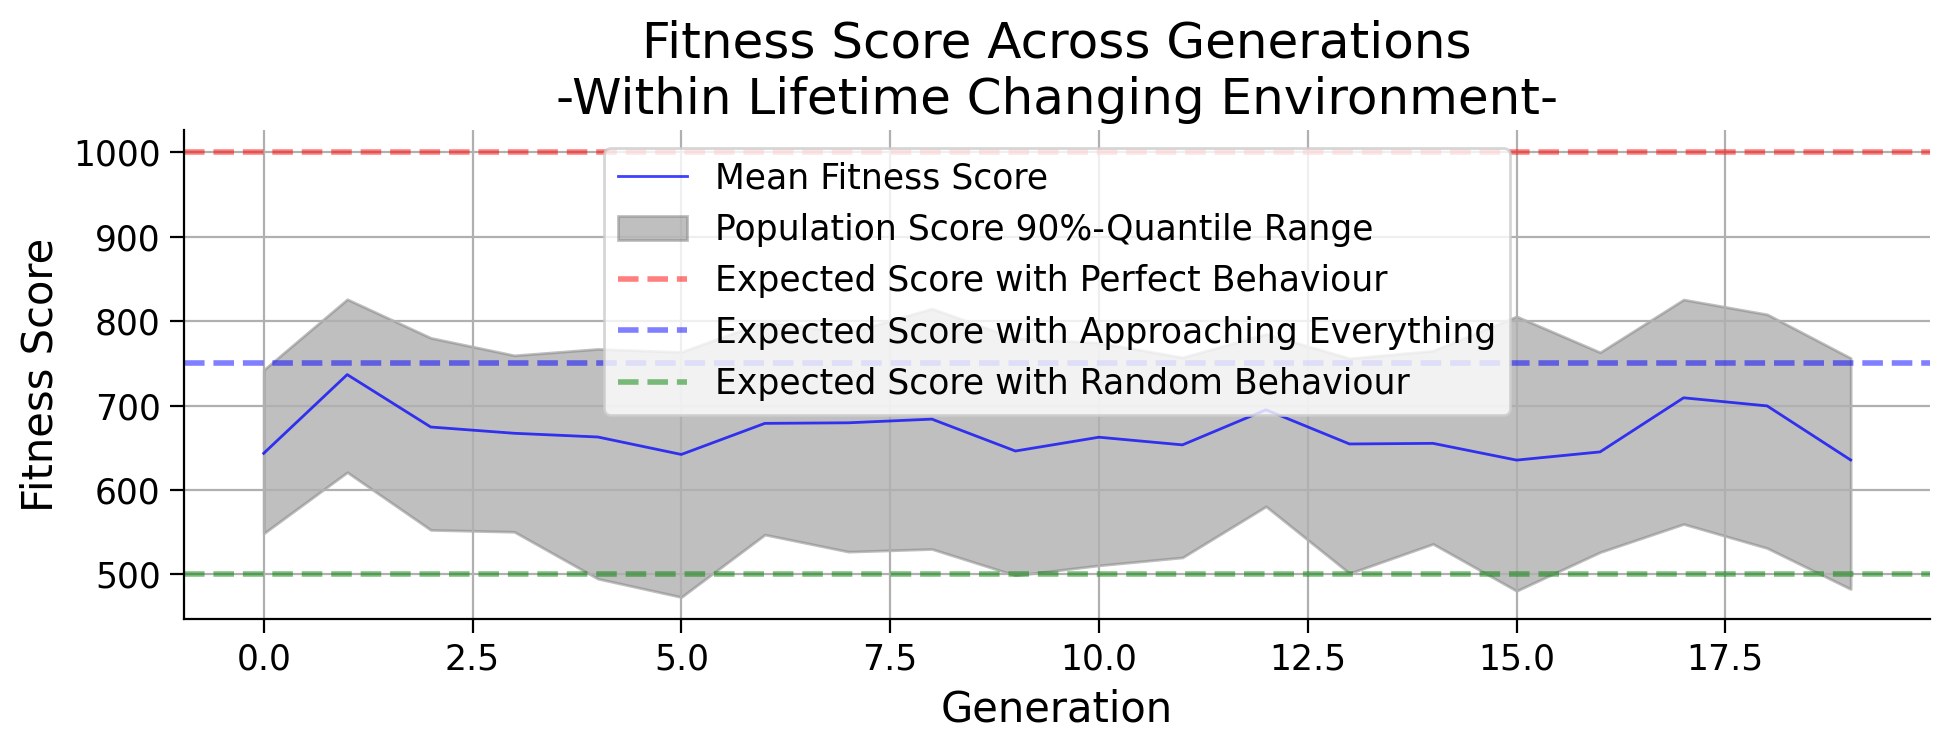

In [ ]:
fitness_history, _ = run_evo_learning_simulation(
  num_generations=20,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  env_change_type='within_lifetime',
  within_lifetime_change_type='once',
  env_change_freq=1000,
  mut_scale=((jnp.array([0.01]), jnp.array([0.01]), jnp.array([0.01])),
             jnp.array([0.0]),
             jnp.array([0.0]),
             (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0]))),
  r_params=[1, -1, -0.01],
  reg_param_alpha=[0.1],
  learning_rates=[0.01, 0.01, 0.01],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin)


plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Within Lifetime Changing', window_size=1)

Learning still works in a sense but it doesn't end up doing any better (in fact for these parameters it is a bit worse) than just approach everything, this is because reversal learning is hard. When we take a look at an individual's life we see that although they rapidly learn to discriminate initially, it takes them a long time to reverse this and learn to avoid the food type they used to approach and approach the food type they used to avoid. Are there better learning parameters that allow the organism to do reversal learning more quickly... so much more quickly that learning is still better than bet hedging?

Let's see if our evolutionary process not just select the initialization of the policy network, but also the learning parameters

# Figure 6: Evolving to Learn
Evolution can dial in learning parameters that allow for effective learning even when the even when the

Gen: 0/25 | Avg Fit: 476.04 |Avg Fit Sel: 532.50 | Avg Fit Not-Sel: 473.69 | Proportion of Pop Selected: 0.0400 |Gen Time: 2.71s | Total Time: 2.71s
Gen: 1/25 | Avg Fit: 536.40 |Avg Fit Sel: 568.33 | Avg Fit Not-Sel: 534.36 | Proportion of Pop Selected: 0.0600 |Gen Time: 2.70s | Total Time: 5.41s
Gen: 2/25 | Avg Fit: 537.42 |Avg Fit Sel: 577.75 | Avg Fit Not-Sel: 533.91 | Proportion of Pop Selected: 0.0800 |Gen Time: 2.72s | Total Time: 8.13s
Gen: 3/25 | Avg Fit: 597.70 |Avg Fit Sel: 659.20 | Avg Fit Not-Sel: 590.87 | Proportion of Pop Selected: 0.1000 |Gen Time: 2.70s | Total Time: 10.82s
Gen: 4/25 | Avg Fit: 618.72 |Avg Fit Sel: 662.00 | Avg Fit Not-Sel: 611.67 | Proportion of Pop Selected: 0.1400 |Gen Time: 2.70s | Total Time: 13.52s
Gen: 5/25 | Avg Fit: 650.42 |Avg Fit Sel: 692.71 | Avg Fit Not-Sel: 643.53 | Proportion of Pop Selected: 0.1400 |Gen Time: 2.70s | Total Time: 16.23s
Gen: 6/25 | Avg Fit: 683.30 |Avg Fit Sel: 741.33 | Avg Fit Not-Sel: 679.60 | Proportion of Pop Selected

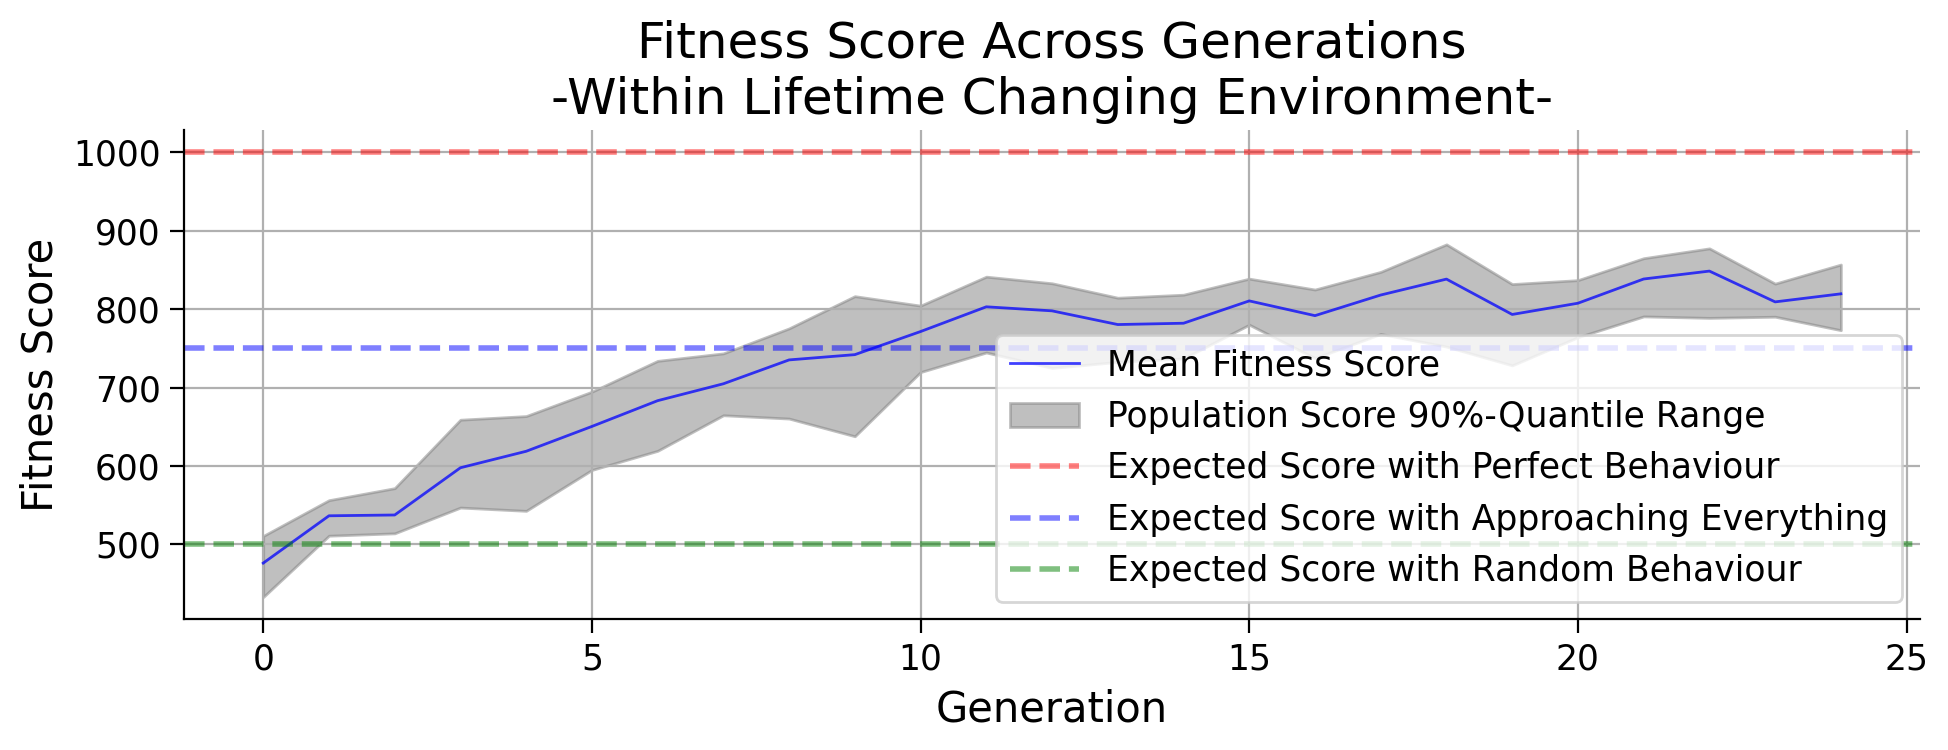

In [ ]:
fitness_history, (best_params_start, med_params_start, best_params_end, med_params_end, X_gen, image_gen, y_gen) = run_evo_learning_simulation(
  num_generations=25,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=4.0,
  env_change_type='within_lifetime',
  within_lifetime_change_type='once',
  env_change_freq=1000,
  mut_scale=((jnp.array([0.005]), jnp.array([0.005]), jnp.array([0.005])),
             jnp.array([0.005]),
             jnp.array([0.005]),
             (jnp.array([0.005]), jnp.array([0.005]), jnp.array([0.005]))),
  r_params=[0.0, 0.0, 0.0],
  reg_param_alpha=[0.0],
  learning_rates=[0.0, 0.0, 0.0],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin)


plot_fitness_history(fitness_history, lifespan=3000, env_type_str='Within Lifetime Changing', window_size=1)

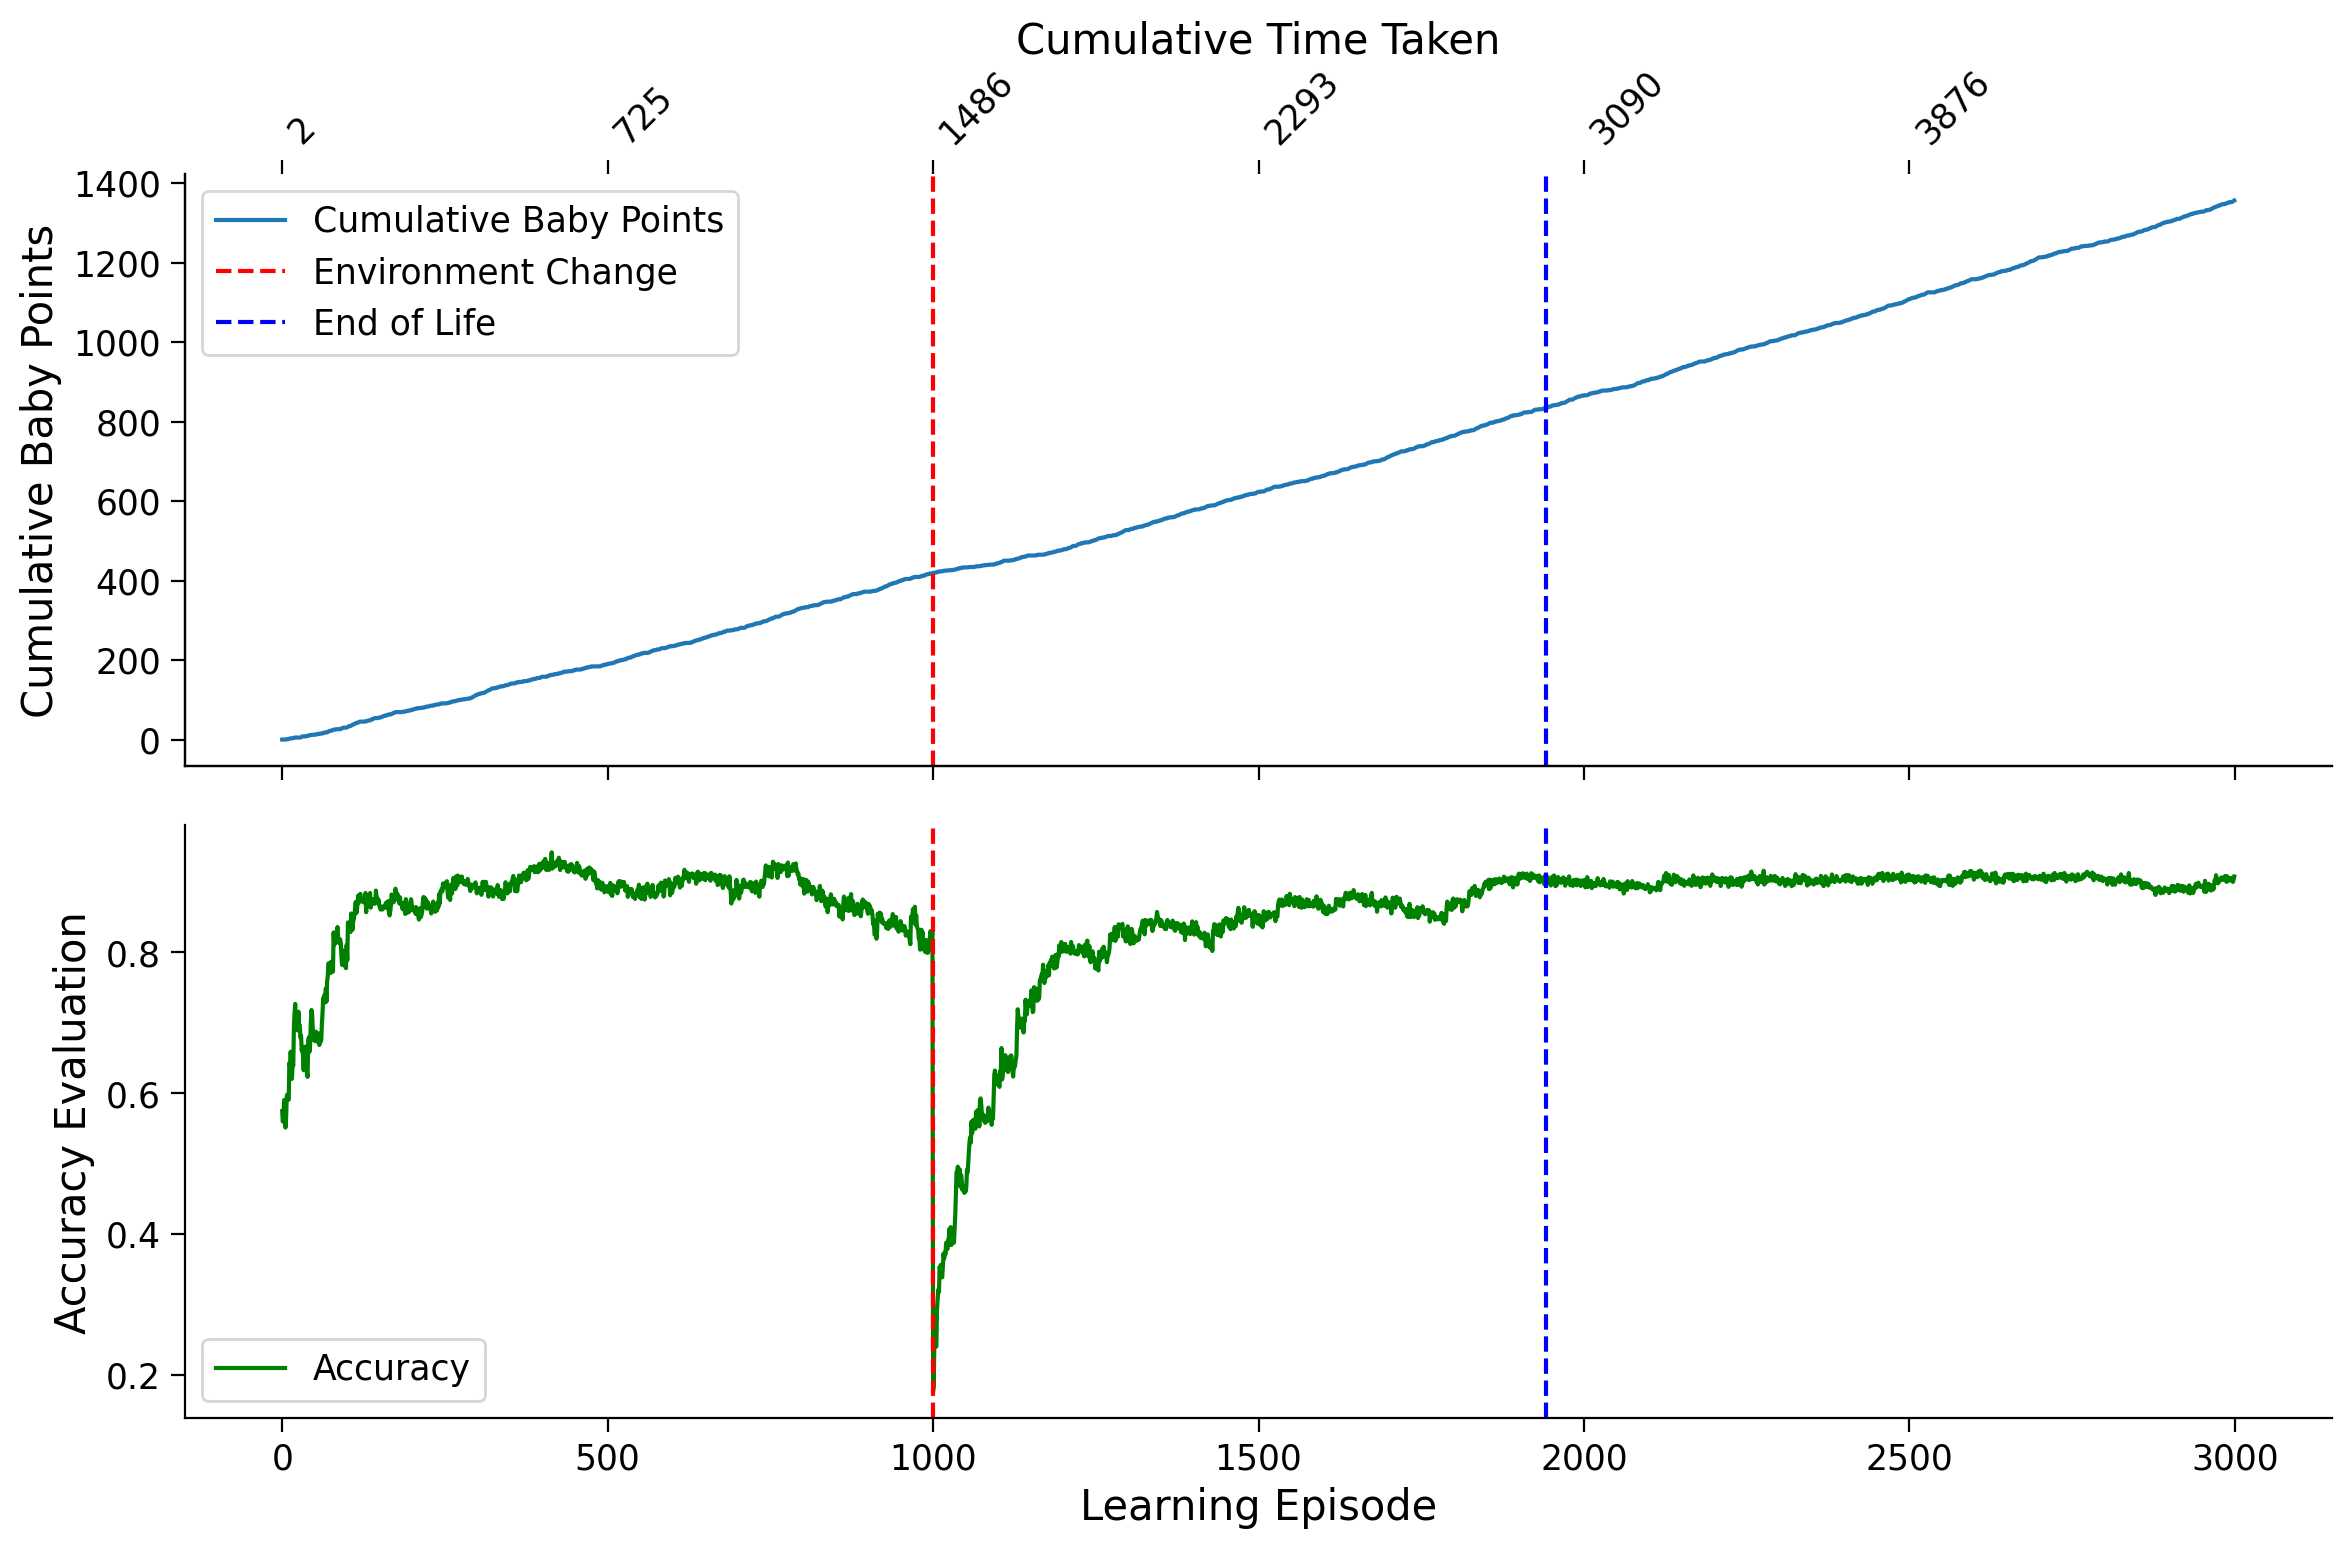

In [ ]:
baby_points, cum_tt, bp_eval, act_x_eval = learning_eval_loop(
  init_policy_params=med_params_end[0],
  r_params=med_params_end[1],
  reg_param_alpha=med_params_end[2],
  learning_rates=med_params_end[3])

TP = act_x_eval[:, 0, 0]
FP = act_x_eval[:, 0, 1]
FN = act_x_eval[:, 1, 0]
TN = act_x_eval[:, 1, 1]

# Calculate accuracy
accuracy = (TP + TN) / (TP + FP + FN + TN)

# Create subplots with shared x-axis
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot baby points evaluation over time
ax[0].plot(np.cumsum(baby_points), label='Cumulative Baby Points')
ax[0].set_ylabel('Cumulative Baby Points')

# Create a secondary x-axis sharing the same x-axis as the first subplot
ax0_twin = ax[0].twiny()
ax0_twin.set_xlabel('Cumulative Time Taken')
ax0_twin.set_xlim(ax[0].get_xlim())
xticks = ax[0].get_xticks()
valid_ticks = [int(tick) for tick in xticks if 0 <= int(tick) < len(cum_tt)]
ax0_twin.set_xticks(valid_ticks)
ax0_twin.set_xticklabels([f'{cum_tt[int(tick)]}' for tick in valid_ticks], rotation=45, ha='left')

# Plot accuracy over time
ax[1].plot(accuracy, label='Accuracy', color='green')
ax[1].set_xlabel('Learning Episode')
ax[1].set_ylabel('Accuracy Evaluation')

# Add vertical lines for environment changes and end of life
if change_type == 'once':
  ax[0].axvline(x=env_change_freq, color='r', linestyle='--', label='Environment Change')
  ax[1].axvline(x=env_change_freq, color='r', linestyle='--')
elif change_type == 'every':
  for env_change in range(env_change_freq, len(baby_points), env_change_freq):
    ax[0].axvline(x=env_change, color='r', linestyle='--', label='Environment Change' if env_change == env_change_freq else "")
    ax[1].axvline(x=env_change, color='r', linestyle='--')
else:
  raise ValueError("Invalid change_type, expected 'once' or 'every'")

# Mark the end of the organism's life
end_life = np.argmin(cum_tt < lifespan)
ax[0].axvline(x=end_life, color='b', linestyle='--', label='End of Life')
ax[1].axvline(x=end_life, color='b', linestyle='--', )
ax[0].legend()
ax[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Figure 7: Evoloving to learn to learn, selection for multiple reversal learning.

In [ ]:
def act_reward_learn(X, y, individual_params, nutritious_type, rnd_key):
  policy_params, r_params, reg_param_alpha, learning_rates = individual_params
  print(f'policy_params type: {type(policy_params)}')
  print(f'r_params type: {type(r_params)}')
  print(f'learning_rates type: {type(learning_rates)}')
  print(f'reg_param_alpha type: {type(reg_param_alpha)}')
  ((obj, aux), grad) = vg_obj(X, y, policy_params, r_params, reg_param_alpha, nutritious_type, rnd_key)
  (a, r, bp, tt, act_x) = aux
  updated_policy_params = update_parameters(policy_params, grad, learning_rates)
  return updated_policy_params, a, r, bp, obj, tt, act_x

def act_reward_learn_loop_fn(carry, X_y):
  X_i, y_i, nt_i = X_y
  individual_params, rnd_key = carry
  rnd_key, arl_key = jrandom.split(rnd_key)
  updated_policy_params, a, r, bp, obj, tt, act_x = act_reward_learn(X_i, y_i, individual_params, nt_i, arl_key)
  updated_individual_params = (updated_policy_params, individual_params[1], individual_params[2], individual_params[3])
  carry = (updated_individual_params, rnd_key)
  return carry, (a, r, bp, obj, tt, act_x)

def act_reward_learn_eval(X, y, X_eval, y_eval, individual_params, nutritious_type, lifespan, rnd_key):
  policy_params, r_params, reg_param_alpha, learning_rates = individual_params
  ((obj, aux), grad) = vg_obj(X, y, policy_params, r_params, reg_param_alpha, nutritious_type, rnd_key)
  (a, r, bp, tt, act_x) = aux
  updated_policy_params = update_parameters(policy_params, grad, learning_rates)
  nt_eval = jnp.tile(nutritious_type, y_eval.shape)
  eval_baby_points, eval_confusion = life_acts_and_outcomes(X_eval, y_eval, updated_policy_params, nt_eval, lifespan, rnd_key)
  return updated_policy_params, a, r, bp, obj, tt, act_x, eval_baby_points, eval_confusion

def act_reward_learn_eval_loop_fn(carry, X_y):
  X_i, y_i, nt_i = X_y
  individual_params, eval_data, rnd_key = carry
  rnd_key, arl_key = jrandom.split(rnd_key)
  X_eval, y_eval, lifespan = eval_data
  updated_policy_params, a, r, bp, obj, tt, act_x, bp_eval, act_x_eval = act_reward_learn_eval(
      X_i, y_i, X_eval, y_eval, individual_params, nt_i, lifespan, arl_key)
  updated_individual_params = (updated_policy_params, individual_params[1], individual_params[2], individual_params[3])
  carry = (updated_individual_params, eval_data, rnd_key)
  return carry, (a, r, bp, obj, tt, act_x, bp_eval, act_x_eval)

env_change_freq = 1000
change_type = 'once' # 'once' or 'every'
lifespan = 3000

def reversal_learning_eval_loop(
    n_in = (28 * 28 * 1 + 1), n_out = 2, n_hid = 20,
    max_session=1000,
    X = X_bin, y = y_bin,
    zero_indices = jnp.where(y_bin == 0)[0],
    one_indices = jnp.where(y_bin == 1)[0],
    init_nutritious_type = 0,
    env_change_freq = env_change_freq,
    change_type = change_type,
    init_policy_params = None,
    r_params = jnp.array([1, -1.0, -0.01]),
    reg_param_alpha = 0.05,
    learning_rates = tuple(jnp.array([0.02]) for _ in range(3)),
    episodes_per_session=20,
    rnd_key=jrandom.key(0),
    plot_outputs = True):

  size_dummy = jnp.zeros(int(episodes_per_session / 2))
  init_key, grab_key, learn_key = jrandom.split(rnd_key, 3)
  if init_policy_params is None:
    init_policy_params = init_mlp_params(n_in, n_hid, n_out, init_key)
  init_params = (init_policy_params, r_params, reg_param_alpha, learning_rates)
  for session in range(max_session):
    rnd_key, grab_key, learn_key = jrandom.split(rnd_key, 3)
    X_sesh, image_sesh, y_sesh = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, grab_key, size_dummy)
  init_carry = (init_params, (X_gen, y_gen, lifespan), learn_key)
  _, (actions, rewards, baby_points, obj, tts, act_xs, bp_eval, act_x_eval) = jax.lax.scan(act_reward_learn_eval_loop_fn, init_carry, (X_gen, y_gen, nutritious_type))
  cum_tts = jnp.cumsum(tts)
  return np.array(baby_points), np.array(cum_tts), np.array(bp_eval), np.array(act_x_eval)

baby_points, cum_tt, bp_eval, act_x_eval = learning_eval_loop()

def run_evo_reversal_learning_simulation(
  num_generations=100,
  pop_size=50,
  n_in=(28 * 28) + 1,
  n_hid=20,
  n_out=2,
  lifespan=3000,
  softmax_selection_strength_temp=2.0,
  # tree strcutire
  # (W1_init, W2_init, Ws_init), rewards, entropy_regulization_weight, (W1_lr, W2_lr, Ws_l3))
  mut_scale=((jnp.array([0.002]), jnp.array([0.002]), jnp.array([0.002])), jnp.array([0.001]), jnp.array([0.001]), (jnp.array([0.0001]), jnp.array([0.0001]), jnp.array([0.0001]))),
  r_params = [1, -1, -0.01],
  reg_param_alpha = [1.0],
  learning_rates = [0.01, 0.01, 0.01],
  print_freq=1,
  rnd_key=jrandom.key(1),
  X=X_bin,
  y=y_bin):

  zero_indices = jnp.where(y == 0)[0]
  one_indices = jnp.where(y == 1)[0]
  size_dummy = jnp.zeros(int(lifespan / 2))
  rnd_key, init_key = jrandom.split(rnd_key)
  pop_params = init_learning_pop_params(pop_size, n_in, n_hid, n_out, rnd_key,
                                        r_params=r_params,
                                        reg_param_alpha=reg_param_alpha,
                                        learning_rates=learning_rates)
  rnd_key, nut_key = jrandom.split(rnd_key)
  init_nutritious_type = jrandom.choice(nut_key, jnp.array([0, 1]))
  fitness_history = []
  start_time = time.time()
  X_gen, image_gen, y_gen = grab_batch_data(X_bin, y_bin, zero_indices, one_indices, grab_key, size_dummy)

  for g in range(num_generations):
    gen_start_time = time.time()
    fitness_scores = []
    for individual_params in pop_params:

    fitness_scores = jnp.array(fitness_scores)
    parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
    unique_parents_count = len(jnp.unique(parent_indices))
    if g == 0:
      best_idx = jnp.argmax(fitness_scores)
      best_params_start = select_params(pop_params, best_idx)
      med_idx = median_index(fitness_scores)
      med_params_start = select_params(pop_params, best_idx)
    elif g == num_generations - 1:
      best_idx = jnp.argmax(fitness_scores)
      best_params_end = select_params(pop_params, best_idx)
      med_idx = median_index(fitness_scores)
      med_params_end = select_params(pop_params, med_idx)
    parent_params = select_params(pop_params, parent_indices)
    pop_params = mutate_learning_pop_params(parent_params, mut_key, mut_scale)
    fitness_history.append({
        'generation': g,
        'mean_fitness': jnp.mean(fitness_scores).item(),
        'std_dev_fitness': jnp.std(fitness_scores).item(),
        'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
        'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
        'unique_parents_count': unique_parents_count,
    })
    gen_time = time.time() - gen_start_time
    total_elapsed_time = time.time() - start_time
    if g % print_freq == 0:
        current_gen_data = fitness_history[-1]
        parent_mask = jnp.zeros(pop_size, dtype=bool).at[parent_indices].set(True)
        selected_fitness = fitness_scores[parent_mask]
        not_selected_fitness = fitness_scores[~parent_mask]
        mean_selected_fitness = jnp.mean(selected_fitness)
        mean_not_selected_fitness = jnp.mean(not_selected_fitness)
        print(f"Gen: {g}/{num_generations} | Avg Fit: {current_gen_data['mean_fitness']:.2f} |Avg Fit Sel: {mean_selected_fitness:.2f} | Avg Fit Not-Sel: {mean_not_selected_fitness:.2f} | Proportion of Pop Selected: {current_gen_data['unique_parents_count'] / pop_size:.4f} |Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")
        #print('Confusion matrix of best individual:')
        #best_idx = jnp.argmax(fitness_scores)
        #print(act_xs[best_idx])
  return fitness_history, (best_params_start, med_params_start, best_params_end, med_params_end, X_gen, image_gen, y_gen)

def def_eval_reversal(X, y, vg_obj, rnd_key):
  assert X.shape[0] == y.shape[0]
  rnd_key, init_key = jrandom.split(rnd_key)
  params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)
  time_to_reverse = []
  nutritious_type = 1
  episodes_to_criterion = 0
  for episode in range(num_episodes):
    rnd_key, shuf_key = jrandom.split(rnd_key)
    X_episode, y_episode = sample_and_augment(X, y, episode_len, shuf_key)
    cum_reward = 0
    cum_confusion = jnp.zeros((2, 2))
    cum_obj = 0
    for i in range(X_episode.shape[0]):
      X_i = X_episode[i]
      y_i = y_episode[i]
      rnd_key, arl_key = jrandom.split(rnd_key)
      ((obj, aux), grad) = vg_obj(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
      (a, r, rslp, act_ent, act_x) = aux
      params = update_parameters(params, grad, lrs)
      cum_reward += r
      cum_obj += obj
      cum_confusion += act_x
    episodes_to_criterion += 1
    correct_trials = cum_confusion.trace()
    accuracy = correct_trials / episode_len
    if accuracy >= criterion_accuracy:
      nutritious_type = 1 - nutritious_type
      time_to_reverse.append(episodes_to_criterion)
      episodes_to_criterion = 0
    if len(time_to_reverse) >= 10:  # Only the first 10 reversals
      break
  return np.sum(time_to_reverse)

# POC 1: Reversal learning possible with policy gradients

We also see that entropy regularization helps a bit, as does L2 but maybe not as much, and it's hard to combine these two though, so we will stick with entropy regularization (more natural in policy gradient setting) going forward

In [ ]:
def jnp_leaky_relu(x, alpha=0.01):
    return jnp.where(x > 0, x, alpha * x)

def jnp_sigmoid(x):
  return 1 / (1 + jnp.exp(-x))

def jnp_softmax(x):
  e_x = jnp.exp(x - jscipy.special.logsumexp(x))
  return e_x

# Initialize parameters for a layer
def init_layer_params(input_size, output_size, skip_output_size, rnd_key):
  W_key, skip_key = jrandom.split(rnd_key)
  W = jrandom.normal(W_key, (output_size, input_size)) * jnp.sqrt(0.2 / (input_size+output_size))
  b = jnp.zeros(output_size)
  W_skip = jrandom.normal(W_key, (skip_output_size, input_size)) * jnp.sqrt(0.2 / (input_size+output_size))
  return W, b, W_skip

# Initialize parameters for the whole network with skip connections
def init_network_params(input_size, layer_sizes, output_size, top_lr, main_lr, rnd_key):
  params = []
  learning_rates = []
  layers = [input_size] + layer_sizes + [output_size]
  rnd_keys = jrandom.split(rnd_key, len(layers)-1)
  # Initialize main layer parameters
  for i in range(len(layers) - 1):
    W, b, W_skip = init_layer_params(layers[i], layers[i+1], layers[-1], rnd_keys[i])
    params.append((W, b, W_skip))
    if i == len(layers) - 2:  # Final layer
      learning_rates.append((top_lr, top_lr, top_lr))
    else:  # All other layers
     learning_rates.append((main_lr, main_lr, main_lr))

  return params, layers, learning_rates

n_in = (28 * 28) + 1
n_out = 2
n_hid = [64]
top_lr = 0.001
main_lr = 0.001

rnd_key = jrandom.key(0)
test_params, test_layers, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, rnd_key)

def print_shapes(params):
  for i, l in enumerate(params):
    for p_type, p in zip(('W', 'b', 'Ws'), l):
      print(f'layer {i} {p_type} has shape: {p.shape}')

print_shapes(test_params)

In [ ]:
# Explicit forward pass with skip connections
def forward_pass_2(x, params):
  # Activations for each layer
  a0 = x
  W0, b0 = params[0][0], params[0][1]
  z1 = W0 @ a0 + b0
  a1 = jnp_leaky_relu(z1)
  W1, b1 = params[1][0], params[1][1]
  z2 = W1 @ a1 + b1
  #a2 = leaky_relu(z2)
  logits = jnp_leaky_relu(z2)
  #W2, b2 = params[2][0], params[2][1]
  #z3 = W2 @ a2 + b2
  #a3 = leaky_relu(z3)
  #W3, b3 = params[3][0], params[3][1]
  #logits = W3 @ a3 + b3
  # Add skip connections (including from raw inputs to the category logits layer)
  W_skip0 = params[0][2]
  #W_skip1 = params[1][2]
  #W_skip2 = params[2][2]
  logits += W_skip0 @ a0
  #logits += W_skip1 @ a1
  #logits += W_skip2 @ a2
  return logits

In [ ]:
def obj_fn(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  # calc probabilities
  logits = forward_pass_2(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  # sample an action
  action = jrandom.categorical(rnd_key, logits=logits) # scalar
  # calc reward given action
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  # calc reward scaled log probability of selected action
  rslp = reward * act_log_prob[action]
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  # calc gain
  obj = rslp + 0.1 * act_ent
  return (obj, (action, reward, rslp, act_ent, act_confusion))

vg_obj = jit(jax.value_and_grad(obj_fn, argnums=2, has_aux=True))

In [ ]:
# Define the objective function with entropy
def obj_fn_with_entropy(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  logits = forward_pass_2(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  action = jrandom.categorical(rnd_key, logits=logits)
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  rslp = reward * act_log_prob[action]
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  obj = rslp + act_ent
  return (obj, (action, reward, rslp, act_ent, act_confusion))

vg_obj_with_entropy = jit(jax.value_and_grad(obj_fn_with_entropy, argnums=2, has_aux=True))

# Define the objective function without entropy
def obj_fn_without_entropy(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  logits = forward_pass_2(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  action = jrandom.categorical(rnd_key, logits=logits)
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  rslp = reward * act_log_prob[action]
  obj = rslp
  return (obj, (action, reward, rslp, 0.0, act_confusion))

vg_obj_without_entropy = jit(jax.value_and_grad(obj_fn_without_entropy, argnums=2, has_aux=True))


def obj_fn_with_l2(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  logits = forward_pass_2(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  action = jrandom.categorical(rnd_key, logits=logits)
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  rslp = reward * act_log_prob[action]
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  l2_reg = 0.1 * sum([jnp.sum(jnp.square(param)) for param_tuple in params for param in param_tuple])
  obj = rslp - l2_reg
  return (obj, (action, reward, rslp, act_ent, act_confusion))

vg_obj_with_l2 = jit(jax.value_and_grad(obj_fn_with_l2, argnums=2, has_aux=True))


def obj_fn_with_entropy_l2(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  logits = forward_pass_2(X, params)
  act_log_prob = logits - jscipy.special.logsumexp(logits, axis=0, keepdims=True)
  action = jrandom.categorical(rnd_key, logits=logits)
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  rslp = reward * act_log_prob[action]
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  l2_reg = 0.1 * sum([jnp.sum(jnp.square(param)) for param_tuple in params for param in param_tuple])
  obj = rslp + act_ent - l2_reg
  return (obj, (action, reward, rslp, act_ent, act_confusion))

vg_obj_with_entropy_l2 = jit(jax.value_and_grad(obj_fn_with_entropy_l2, argnums=2, has_aux=True))

def update_parameters(params, grads, learning_rates):
  def update(param, grad, lr):
    return param + lr * grad
  updated_params = jax.tree_util.tree_map(update, params, grads, learning_rates)
  return updated_params

# Learning hyper-parameters
nutritious_type = 1
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0

# Initialize parameters
n_in = (28 * 28) + 1
n_out = 2
n_hid = [64]
top_lr = 0.02
main_lr = 0.02

episode_len = 20
num_episodes = 2000
criterion_accuracy = 0.80

def sample_and_augment(X, y, num_samples, rnd_key):
  rnd_key, samp_key = jrandom.split(rnd_key)
  indices = jrandom.choice(rnd_key, jnp.arange(X.shape[0]), shape=(num_samples,), replace=False)
  X_sample = X[indices]
  y_sample = y[indices]
  aug_keys = jrandom.split(rnd_key, num_samples)
  augmented_X = vmap_augment_image(X_sample, aug_keys)
  return augmented_X, y_sample

def run_experiment(X, y, vg_obj, rnd_key):
  assert X.shape[0] == y.shape[0]
  rnd_key, init_key = jrandom.split(rnd_key)
  params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)
  time_to_reverse = []
  nutritious_type = 1
  episodes_to_criterion = 0
  for episode in range(num_episodes):
    rnd_key, shuf_key = jrandom.split(rnd_key)
    X_episode, y_episode = sample_and_augment(X, y, episode_len, shuf_key)
    cum_reward = 0
    cum_confusion = jnp.zeros((2, 2))
    cum_obj = 0
    for i in range(X_episode.shape[0]):
      X_i = X_episode[i]
      y_i = y_episode[i]
      rnd_key, arl_key = jrandom.split(rnd_key)
      ((obj, aux), grad) = vg_obj(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
      (a, r, rslp, act_ent, act_x) = aux
      params = update_parameters(params, grad, lrs)
      cum_reward += r
      cum_obj += obj
      cum_confusion += act_x
    episodes_to_criterion += 1
    correct_trials = cum_confusion.trace()
    accuracy = correct_trials / episode_len
    if accuracy >= criterion_accuracy:
      nutritious_type = 1 - nutritious_type
      time_to_reverse.append(episodes_to_criterion)
      episodes_to_criterion = 0
    if len(time_to_reverse) >= 10:  # Only the first 10 reversals
      break
  return np.sum(time_to_reverse)

num_repeats = 10
times_with_entropy = []
times_without_entropy = []
times_with_l2 = []
times_with_entropy_l2 = []

for ii in range(num_repeats):
  print(ii)
  rnd_key, exp_key = jrandom.split(rnd_key, 2)
  time_with_entropy = run_experiment(X_bin, y_bin, vg_obj_with_entropy, exp_key)
  print(f'Episodes to 10 reversals with entropy: {time_with_entropy}')
  time_without_entropy = run_experiment(X_bin, y_bin, vg_obj_without_entropy, exp_key)
  print(f'Episodes to 10 reversals without entropy: {time_without_entropy}')
  time_with_l2 = run_experiment(X_bin, y_bin, vg_obj_with_l2, exp_key)
  print(f'Episodes to 10 reversals with l2: {time_with_l2}')
  time_with_entropy_l2 = run_experiment(X_bin, y_bin, vg_obj_with_entropy_l2, exp_key)
  print(f'Episodes to 10 reversals with entropy and l2: {time_with_entropy_l2}')
  times_with_entropy.append(time_with_entropy)
  times_without_entropy.append(time_without_entropy)
  times_with_l2.append(time_with_l2)
  times_with_entropy_l2.append(time_with_entropy_l2)

# Perform t-tests
t_stat_entropy_vs_no_entropy, p_value_entropy_vs_no_entropy = stats.ttest_rel(times_with_entropy, times_without_entropy)
t_stat_l2_vs_no_entropy, p_value_l2_vs_no_entropy = stats.ttest_rel(times_with_l2, times_without_entropy)
t_stat_entropy_l2_vs_no_entropy, p_value_entropy_l2_vs_no_entropy = stats.ttest_rel(times_with_entropy_l2, times_without_entropy)

# Print t-test results
print(f"T-test result (entropy vs no entropy): t_stat = {t_stat_entropy_vs_no_entropy}, p_value = {p_value_entropy_vs_no_entropy}")
print(f"T-test result (l2 vs no entropy): t_stat = {t_stat_l2_vs_no_entropy}, p_value = {p_value_l2_vs_no_entropy}")
print(f"T-test result (entropy+l2 vs no entropy): t_stat = {t_stat_entropy_l2_vs_no_entropy}, p_value = {p_value_entropy_l2_vs_no_entropy}")

# Plot histograms
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(times_with_entropy, alpha=0.5, label='With Entropy', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
plt.hist(times_with_l2, alpha=0.5, label='With L2', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With L2 vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.subplot(2, 2, 3)
plt.hist(times_with_entropy_l2, alpha=0.5, label='With Entropy and L2', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With Entropy and L2 vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print medians
print(f"Median episodes to reverse 10 times over {num_repeats} trials")
print("Median episodes to reverse 10 times with entropy:", np.median(times_with_entropy))
print("Median episodes to reverse 10 times without entropy:", np.median(times_without_entropy))
print("Median episodes to reverse 10 times with l2:", np.median(times_with_l2))
print("Median episodes to reverse 10 times with entropy and l2:", np.median(times_with_entropy_l2))

In [ ]:
# Perform t-tests
t_stat_entropy_vs_no_entropy, p_value_entropy_vs_no_entropy = stats.ttest_rel(times_with_entropy, times_without_entropy)
t_stat_l2_vs_no_entropy, p_value_l2_vs_no_entropy = stats.ttest_rel(times_with_l2, times_without_entropy)
t_stat_entropy_l2_vs_no_entropy, p_value_entropy_l2_vs_no_entropy = stats.ttest_rel(times_with_entropy_l2, times_without_entropy)

# Print t-test results
print(f"T-test result (entropy vs no entropy): t_stat = {t_stat_entropy_vs_no_entropy}, p_value = {p_value_entropy_vs_no_entropy}")
print(f"T-test result (l2 vs no entropy): t_stat = {t_stat_l2_vs_no_entropy}, p_value = {p_value_l2_vs_no_entropy}")
print(f"T-test result (entropy+l2 vs no entropy): t_stat = {t_stat_entropy_l2_vs_no_entropy}, p_value = {p_value_entropy_l2_vs_no_entropy}")

# Plot histograms
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(times_with_entropy, alpha=0.5, label='With Entropy', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
plt.hist(times_with_l2, alpha=0.5, label='With L2', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With L2 vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.subplot(2, 2, 3)
plt.hist(times_with_entropy_l2, alpha=0.5, label='With Entropy and L2', bins=10)
plt.hist(times_without_entropy, alpha=0.5, label='Without Entropy', bins=10)
plt.legend(loc='upper right')
plt.title('With Entropy and L2 vs Just RSLP')
plt.xlabel('Episodes to Reverse')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print medians
print(f"Median episodes to reverse 10 times over {num_repeats} trials")
print("Median episodes to reverse 10 times with entropy:", np.median(times_with_entropy))
print("Median episodes to reverse 10 times without entropy:", np.median(times_without_entropy))
print("Median episodes to reverse 10 times with l2:", np.median(times_with_l2))
print("Median episodes to reverse 10 times with entropy and l2:", np.median(times_with_entropy_l2))

l2 norm for the win on this mnist task a reversal on the order of 100 trials, that's more like it

# POC: Learning to Learn With Online Policy Gradients
We use a cross-entropy loss on an intermediate 'categorization layer and entropy regularization (at the action probability level) to encourage some exploration. These two things facilitate rapid, with-in lifetime adaption to environmental changes, through learning. The intermediate categorization training helps to maintain a stable/useful underlying representation that then supports rapid relearning of action selection. This relearning is also faciltated by the entropy regularization which keeps the policy network 'open' to alternative actions. Would a rich and flexible enough RL framework hit upon a good/better analouge to this approach (we believe so, and maybe will show that it does later) but for now we build it by hand just to show that it can work.

In the following coding cells we build up and test the
1. The decision making function, or behavioural policy of the organism.
2. How these actions are translated into rewards for a learning rule (parameter update rule)
3. Apply the learning rule iteratively in an 'online' (i.e. behave - reward - update loop, as contrasted with running a fixed policy for many episodes then applying a single update based on the aggregate rewards of these many learning episodes)

## Work on Decision Function

In [ ]:
# Initialize parameters for a layer
def init_layer_params(input_size, output_size, skip_output_size, rnd_key):
  W_key, skip_key = jrandom.split(rnd_key)
  W = jrandom.normal(W_key, (output_size, input_size)) * jnp.sqrt(0.2 / (input_size+output_size))
  b = jnp.zeros(output_size)
  W_skip = jrandom.normal(W_key, (skip_output_size, input_size)) * jnp.sqrt(0.2 / (input_size+output_size))
  return W, b, W_skip

  # Initialize parameters for the whole network with skip connections
def init_network_params(input_size, layer_sizes, output_size, top_lr, main_lr, rnd_key):
  params = []
  learning_rates = []
  layers = [input_size] + layer_sizes + [output_size]
  rnd_keys = jrandom.split(rnd_key, len(layers)-1)
  # Initialize main layer parameters
  for i in range(len(layers) - 1):
    W, b, W_skip = init_layer_params(layers[i], layers[i+1], layers[-1], rnd_keys[i])
    params.append((W, b, W_skip))
    if i >= len(layers) - 3:  # Final layer
      learning_rates.append((top_lr, top_lr, top_lr))
    else:  # All other layers
      learning_rates.append((main_lr, main_lr, main_lr))

  return params, layers, learning_rates

n_in = 32 * 32 * 3
n_out = 2
n_hid = [1024, 512, 256, 128, 2, 32]
top_lr = 0.001
main_lr = 0.001

rnd_key = jrandom.key(0)
test_params, test_layers, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, rnd_key)

def print_shapes(params):
  for i, l in enumerate(params):
    for p_type, p in zip(('W', 'b', 'Ws'), l):
      print(f'layer {i} {p_type} has shape: {p.shape}')

print_shapes(test_params)

In [ ]:
# Explicit forward pass with skip connections and category bottle neck
def forward_pass_bottle_neck(x, params):
  n_in = 32 * 32 * 3
  n_out = 2
  n_hid = [1024, 512, 256, 128, 2, 32]
  #unpack params
  [(W0, b0, W_skip0),
   (W1, b1, W_skip1),
   (W2, b2, W_skip2),
   (W3, b3, W_skip3),
   (W4, b4, W_skip4),
   (W5, b5, W_skip5),
   (W6, b6, W_skip6)] = params
  a0 = x # input
  z1 = W0 @ a0 + b0
  a1 = jnp_leaky_relu(z1) # first hidden 1024
  z2 = W1 @ a1 + b1
  a2 = jnp_leaky_relu(z2) # second hidden 512
  z3 = W2 @ a2 + b2
  a3 = jnp_leaky_relu(z3) # third hidden 256
  z4 = W3 @ a3 + b3
  a4 = jnp_leaky_relu(z4) # fourth hidden 128
  cat_logits = W4 @ a4 + b4
  cat_logits += W_skip0 @ a0
  cat_logits += W_skip1 @ a1
  cat_logits += W_skip2 @ a2
  cat_logits += W_skip3 @ a3
  # fifth hidden is a categorization bottle neck hence skips to here and
  # different activation function
  cat_probs = jnp_softmax(cat_logits)
  z6 = W5 @ cat_probs + b5
  a6 = jnp_leaky_relu(z6) # sixth hidden layer
  act_logits = W6 @ a6
  act_logits += W_skip5 @ cat_probs # final action logits
  return act_logits, cat_logits

In [ ]:
# Explicit forward pass full skip connections (implicit categorization)
def forward_pass_full_skip(x, params):
  n_in = 32 * 32 * 3
  n_out = 2
  n_hid = [1024, 512, 256, 128, 2, 32]
  #unpack params
  [(W0, b0, W_skip0),
   (W1, b1, W_skip1),
   (W2, b2, W_skip2),
   (W3, b3, W_skip3),
   (W4, b4, W_skip4),
   (W5, b5, W_skip5),
   (W6, b6, W_skip6)] = params
  a0 = x # input
  z1 = W0 @ a0 + b0
  a1 = jnp_leaky_relu(z1) # first hidden 1024
  z2 = W1 @ a1 + b1
  a2 = jnp_leaky_relu(z2) # second hidden 512
  z3 = W2 @ a2 + b2
  a3 = jnp_leaky_relu(z3) # third hidden 256
  z4 = W3 @ a3 + b3
  a4 = jnp_leaky_relu(z4) # fourth hidden 128
  cat_logits = W4 @ a4 + b4
  # fifth hidden is a categorization bottle neck hence skips to here and
  # different activation function
  cat_probs = jnp_softmax(cat_logits)
  z6 = W5 @ cat_probs + b5
  a6 = jnp_leaky_relu(z6) # sixth hidden layer
  act_logits = W6 @ a6
  act_logits += W_skip0 @ a0
  act_logits += W_skip1 @ a1
  act_logits += W_skip2 @ a2
  act_logits += W_skip3 @ a3
  act_logits += W_skip5 @ cat_probs # final action logits
  return act_logits, cat_logits

## Work on Slick Forward Pass

In [ ]:
def obj_fn_bn(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  # calc probabilities
  act_logits, cat_logits = forward_pass_bottle_neck(X, params)
  act_log_prob = act_logits - jscipy.special.logsumexp(act_logits, axis=0, keepdims=True)
  cat_log_prob = cat_logits - jscipy.special.logsumexp(cat_logits, axis=0, keepdims=True)
  # sample an action
  action = jrandom.categorical(rnd_key, logits=act_logits) # scalar
  # calc reward given action
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  # calc reward scaled log probability of selected action
  rslp = reward * act_log_prob[action]
  # calc negative log loss of categorization
  cat_nll = cat_log_prob[y]
  # calc expected categorization confusion
  cat_confusion = jnp.zeros((2, 2))
  cat_confusion = cat_confusion.at[y].set(jnp.exp(cat_log_prob))
  # calc entropy of policy
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  # calc gain
  obj = rslp #+ 0.1 * cat_nll #+ 0.01 * act_ent
  return (obj, (action, reward, rslp, cat_nll, act_ent, act_confusion, cat_confusion))

vg_obj_fn_bn = jit(jax.value_and_grad(obj_fn_bn, argnums=2, has_aux=True))

def obj_fn_fs(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  # calc probabilities
  act_logits, cat_logits = forward_pass_full_skip(X, params)
  act_log_prob = act_logits - jscipy.special.logsumexp(act_logits, axis=0, keepdims=True)
  cat_log_prob = cat_logits - jscipy.special.logsumexp(cat_logits, axis=0, keepdims=True)
  # sample an action
  action = jrandom.categorical(rnd_key, logits=act_logits) # scalar
  # calc reward given action
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  # calc reward scaled log probability of selected action
  rslp = reward * act_log_prob[action]
  # calc negative log loss of categorization
  cat_nll = cat_log_prob[y]
  # calc expected categorization confusion
  cat_confusion = jnp.zeros((2, 2))
  cat_confusion = cat_confusion.at[y].set(jnp.exp(cat_log_prob))
  # calc entropy of policy
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  # calc gain
  obj = rslp #+ 0.1 * cat_nll #+ 0.01 * act_ent
  return (obj, (action, reward, rslp, cat_nll, act_ent, act_confusion, cat_confusion))

vg_obj_fn_fs = jit(jax.value_and_grad(obj_fn_fs, argnums=2, has_aux=True))

## Work on Learning Loop

In [ ]:
## Run a long learning simulation

# learning hyper-parameters
nutritious_type = 1
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)

# Initialize parameters
rnd_key = jrandom.key(123)
n_in = 32 * 32 * 3
n_out = 2
n_hid = [1024, 512, 256, 128, 2, 64]
rnd_key, init_key = jrandom.split(rnd_key)
main_lr = 0.0001
top_lr = 0.0001
params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

# Training loop
num_epochs = 2000
criterion_accuracy = 0.70

@jit
def shuffle_batch(X, y, rnd_key):
  rnd_key, shuf_key = jrandom.split(rnd_key)
  perm = jrandom.permutation(rnd_key, X.shape[0])
  X_shuffle = X[perm]
  y_shuffle = y[perm]
  return X_shuffle, y_shuffle, rnd_key

time_to_reverse = []
life_time = 0
epochs_to_criterion = 0
total_trials = X.shape[0]
for epoch in range(num_epochs):
  # Shuffle the dataset
  print(nutritious_type)
  start_time = time.time()  # Start time of the epoch
  X_shuffled, y_shuffled, rnd_key = shuffle_batch(X, y, rnd_key)
  cum_reward = 0
  cum_cat_confusion = jnp.zeros((2, 2))
  cum_act_confusion = jnp.zeros((2, 2))
  cum_obj = 0

  for i in range(X_shuffled.shape[0]):
    X_i = X_shuffled[i]
    y_i = y_shuffled[i]
    rnd_key, arl_key = jrandom.split(rnd_key)
    ((obj, aux), grad) = vg_obj_fn_fs(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
    (a, r, rslp, cat_nll, act_ent, act_x, cat_x) = aux
    if a == 0:
      life_time += 2
    else:
      life_time += 1
    params = update_parameters(params, grad, lrs)
    cum_reward += r
    cum_obj += obj
    cum_act_confusion += act_x
    cum_cat_confusion += cat_x
    epochs_to_criterion += 1

  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / episode_len
  end_time = time.time()  # End time of the epoch
  epoch_time = end_time - start_time  # Duration of the epoch
  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / total_trials if total_trials > 0 else 0

  cat_TP = cum_cat_confusion[0, 0]
  cat_FP = cum_cat_confusion[0, 1]
  cat_FN = cum_cat_confusion[1, 0]
  cat_TN = cum_cat_confusion[1, 1]

  act_TP = cum_act_confusion[0, 0]
  act_FP = cum_act_confusion[0, 1]
  act_FN = cum_act_confusion[1, 0]
  act_TN = cum_act_confusion[1, 1]

  print(f"Epoch {epoch} | Reward: {cum_reward:.2f} | Act Acc: {accuracy:.2f} | obj: {cum_obj:.2f} |Time: {epoch_time:.2f} seconds")
  print(f"   Categorization - TP: {cat_TP:.1f}, FP: {cat_FP:.1f}, FN: {cat_FN:.1f}, TN: {cat_TN:.1f}")
  print(f"           Action - TP: {act_TP:.1f}, FP: {act_FP:.1f}, FN: {act_FN:.1f}, TN: {act_TN:.1f}")
  if accuracy >= criterion_accuracy:
    print(f'Criterion met after {epochs_to_criterion} epochs, switching nutritous type from {nutritious_type} to {1 - nutritious_type}')
    nutritious_type = 1 - nutritious_type  # Switch nutritious type
    epochs_to_criterion = 0

In [ ]:
## Run a long learning simulation

# learning hyper-parameters
nutritious_type = 1
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)

# Initialize parameters
rnd_key = jrandom.key(123)
n_in = 32 * 32 * 3
n_out = 2
n_hid = [1024, 512, 256, 128, 2, 64]
rnd_key, init_key = jrandom.split(rnd_key)
main_lr = 0.0001
top_lr = 0.0001
params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

# Training loop
num_epochs = 2000
criterion_accuracy = 0.8

@jit
def shuffle_batch(X, y, rnd_key):
  rnd_key, shuf_key = jrandom.split(rnd_key)
  perm = jrandom.permutation(rnd_key, X.shape[0])
  X_shuffle = X[perm]
  y_shuffle = y[perm]
  return X_shuffle, y_shuffle, rnd_key

time_to_reverse = []
life_time = 0
epochs_to_criterion = 0
total_trials = X.shape[0]
for epoch in range(num_epochs):
  # Shuffle the dataset
  print(nutritious_type)
  start_time = time.time()  # Start time of the epoch
  X_shuffled, y_shuffled, rnd_key = shuffle_batch(X, y, rnd_key)
  cum_reward = 0
  cum_cat_confusion = jnp.zeros((2, 2))
  cum_act_confusion = jnp.zeros((2, 2))
  cum_obj = 0

  for i in range(X_shuffled.shape[0]):
    X_i = X_shuffled[i]
    y_i = y_shuffled[i]
    rnd_key, arl_key = jrandom.split(rnd_key)
    ((obj, aux), grad) = vg_obj_fn_bn(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
    (a, r, rslp, cat_nll, act_ent, act_x, cat_x) = aux
    if a == 0:
      life_time += 2
    else:
      life_time += 1
    params = update_parameters(params, grad, lrs)
    cum_reward += r
    cum_obj += obj
    cum_act_confusion += act_x
    cum_cat_confusion += cat_x
    epochs_to_criterion += 1

  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / episode_len
  end_time = time.time()  # End time of the epoch
  epoch_time = end_time - start_time  # Duration of the epoch
  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / total_trials if total_trials > 0 else 0

  cat_TP = cum_cat_confusion[0, 0]
  cat_FP = cum_cat_confusion[0, 1]
  cat_FN = cum_cat_confusion[1, 0]
  cat_TN = cum_cat_confusion[1, 1]

  act_TP = cum_act_confusion[0, 0]
  act_FP = cum_act_confusion[0, 1]
  act_FN = cum_act_confusion[1, 0]
  act_TN = cum_act_confusion[1, 1]

  print(f"Epoch {epoch} | Reward: {cum_reward:.2f} | Act Acc: {accuracy:.2f} | obj: {cum_obj:.2f} |Time: {epoch_time:.2f} seconds")
  print(f"   Categorization - TP: {cat_TP:.1f}, FP: {cat_FP:.1f}, FN: {cat_FN:.1f}, TN: {cat_TN:.1f}")
  print(f"           Action - TP: {act_TP:.1f}, FP: {act_FP:.1f}, FN: {act_FN:.1f}, TN: {act_TN:.1f}")
  if accuracy >= criterion_accuracy:
    print(f'Criterion met after {epochs_to_criterion} epochs, switching nutritous type from {nutritious_type} to {1 - nutritious_type}')
    nutritious_type = 1 - nutritious_type  # Switch nutritious type
    epochs_to_criterion = 0

In [ ]:
def obj_fn_with_cat_bn(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  # calc probabilities
  act_logits, cat_logits = forward_pass_bottle_neck(X, params)
  act_log_prob = act_logits - jscipy.special.logsumexp(act_logits, axis=0, keepdims=True)
  cat_log_prob = cat_logits - jscipy.special.logsumexp(cat_logits, axis=0, keepdims=True)
  # sample an action
  action = jrandom.categorical(rnd_key, logits=act_logits) # scalar
  # calc reward given action
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  # calc reward scaled log probability of selected action
  rslp = reward * act_log_prob[action]
  # calc negative log loss of categorization
  cat_nll = cat_log_prob[y]
  # calc expected categorization confusion
  cat_confusion = jnp.zeros((2, 2))
  cat_confusion = cat_confusion.at[y].set(jnp.exp(cat_log_prob))
  # calc entropy of policy
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  # calc gain
  obj = rslp + 0.1 * cat_nll #+ 0.01 * act_ent
  return (obj, (action, reward, rslp, cat_nll, act_ent, act_confusion, cat_confusion))

vg_obj_fn_with_cat_bn = jit(jax.value_and_grad(obj_fn_with_cat_bn, argnums=2, has_aux=True))

## Run a long learning simulation

# learning hyper-parameters
nutritious_type = 1
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)

# Initialize parameters
rnd_key = jrandom.key(123)
n_in = 32 * 32 * 3
n_out = 2
n_hid = [1024, 512, 256, 128, 2, 64]
rnd_key, init_key = jrandom.split(rnd_key)
main_lr = 0.0001
top_lr = 0.0001
params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

# Training loop
num_epochs = 2000
criterion_accuracy = 0.8

@jit
def shuffle_batch(X, y, rnd_key):
  rnd_key, shuf_key = jrandom.split(rnd_key)
  perm = jrandom.permutation(rnd_key, X.shape[0])
  X_shuffle = X[perm]
  y_shuffle = y[perm]
  return X_shuffle, y_shuffle, rnd_key

time_to_reverse = []
life_time = 0
epochs_to_criterion = 0
total_trials = X.shape[0]
for epoch in range(num_epochs):
  # Shuffle the dataset
  print(nutritious_type)
  start_time = time.time()  # Start time of the epoch
  X_shuffled, y_shuffled, rnd_key = shuffle_batch(X, y, rnd_key)
  cum_reward = 0
  cum_cat_confusion = jnp.zeros((2, 2))
  cum_act_confusion = jnp.zeros((2, 2))
  cum_obj = 0

  for i in range(X_shuffled.shape[0]):
    X_i = X_shuffled[i]
    y_i = y_shuffled[i]
    rnd_key, arl_key = jrandom.split(rnd_key)
    ((obj, aux), grad) = vg_obj_fn_with_cat_bn(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
    (a, r, rslp, cat_nll, act_ent, act_x, cat_x) = aux
    if a == 0:
      life_time += 2
    else:
      life_time += 1
    params = update_parameters(params, grad, lrs)
    cum_reward += r
    cum_obj += obj
    cum_act_confusion += act_x
    cum_cat_confusion += cat_x
  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / episode_len
  end_time = time.time()  # End time of the epoch
  epoch_time = end_time - start_time  # Duration of the epoch
  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / total_trials if total_trials > 0 else 0

  cat_TP = cum_cat_confusion[0, 0]
  cat_FP = cum_cat_confusion[0, 1]
  cat_FN = cum_cat_confusion[1, 0]
  cat_TN = cum_cat_confusion[1, 1]

  act_TP = cum_act_confusion[0, 0]
  act_FP = cum_act_confusion[0, 1]
  act_FN = cum_act_confusion[1, 0]
  act_TN = cum_act_confusion[1, 1]

  print(f"Epoch {epoch} | Reward: {cum_reward:.2f} | Act Acc: {accuracy:.2f} | obj: {cum_obj:.2f} |Time: {epoch_time:.2f} seconds")
  print(f"   Categorization - TP: {cat_TP:.1f}, FP: {cat_FP:.1f}, FN: {cat_FN:.1f}, TN: {cat_TN:.1f}")
  print(f"           Action - TP: {act_TP:.1f}, FP: {act_FP:.1f}, FN: {act_FN:.1f}, TN: {act_TN:.1f}")
  epochs_to_criterion += 1
  if accuracy >= criterion_accuracy:
    print(f'Criterion met after {epochs_to_criterion} epochs, switching nutritous type from {nutritious_type} to {1 - nutritious_type}')
    nutritious_type = 1 - nutritious_type  # Switch nutritious type
    epochs_to_criterion = 0

After a long time the network settles in on settings that rapidly learn to reverse, this is very cool, switching criterion is hit after very few epochs, (2 or 3) interstingly it seems like this is best supported by high entropy categorization layer (which is what does the flip flopping), took 60 epochs to reach criterion the first time, and another 77 to reverse it, but reversal times quickly fall after this, as good low level representations are retained. After about 300 epochs, only 2 epochs are required for full reversal. This was with a small cross-entropy categorization loss term, but the categorization is what ended up flipping!!! Would this work without the categorization loss term? What about just an entropy term? Let's experiment and find out. Other experiments, can this work (and hence be faster both wall clock and iterations wise) with a smaller network. Can we optimize the snot out of the training loop with lax.scan? Learning rate, archetecture.


In [ ]:
def calc_decision_prob(X, params):
  act_logits, _ = forward_pass(X, params)
  return jnp_softmax(act_logits)

batch_calc_decision_prob = vmap(calc_decision_prob,
                                 in_axes=(0, None))

def make_decision(X, params, rnd_key):
  act_logits, _ = forward_pass(X, params)
  action = jrandom.categorical(rnd_key, logits=act_logits) # scalar
  return action

# sensory inputs and rnd_keys need to come in batches
batch_make_decision = vmap(make_decision, in_axes=(0, None, 0))

X_batch = jnp.array(flat_bird_frog_images[:30])
# make decision
probabilities = batch_calc_decision_prob(X_batch, test_params)
rnd_key, *batch_dec_keys = jrandom.split(rnd_key, 31)
batch_dec_keys = jnp.array(batch_dec_keys)
actions = batch_make_decision(X_batch, test_params, batch_dec_keys)

# Plot results batch
fig, ax = plt.subplots(figsize=(10, 5))
eating_indices = [i for i, s in enumerate(actions) if s == 0]
not_eating_indices = [i for i, s in enumerate(actions) if s == 1]
eating_probabilities = [probabilities[i, 0] for i in eating_indices]
not_eating_probabilities = [probabilities[i, 0] for i in not_eating_indices]
ax.scatter(eating_indices, eating_probabilities, color='blue', label='Chose Approach')
ax.scatter(not_eating_indices, not_eating_probabilities, color='red', label='Chose Avoid')
ax.set_title('Decision - Probability and Outcome')
ax.set_xlabel('Decision Index')
ax.set_ylabel('Probability of Approach')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
remove_ip_clutter(fig)
plt.show()

## Work on Reward Function

In [ ]:
def calc_reward(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  action = make_decision(X, params, rnd_key)
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  # Calculate reward
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  return action, reward, TP, FP, FN, TN

# Vectorized version of eval using vmap
batch_calc_reward = jit(vmap(calc_reward, in_axes=(0, 0, None, None, None, None, None, None, 0)))

# Assuming you have the following variables already defined:
# x_batch, y_batch, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key

X_batch = jnp.array(flat_bird_frog_images[:30])
y_batch = jnp.array(bird_frog_labels[:30])
r_TP, r_FP, r_FN, r_TN = 2, -2, -1, 1
nutritious_type = 1

probabilities = batch_calc_decision_prob(X_batch, test_params)

rnd_key, *batch_dec_keys = jrandom.split(rnd_key, 31)
batch_dec_keys = jnp.array(batch_dec_keys)

actions, rewards, TPs, FPs, FNs, TNs = batch_calc_reward(
    X_batch, y_batch, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, batch_dec_keys
)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Indices for eating and not eating decisions
eating_indices = [i for i, action in enumerate(actions) if action == 0]
not_eating_indices = [i for i, action in enumerate(actions) if action == 1]

# Probabilities for eating and not eating decisions
eating_probabilities = [probabilities[i, 0] for i in eating_indices]
not_eating_probabilities = [probabilities[i, 0] for i in not_eating_indices]

# Rewards for each decision
eating_rewards = [rewards[i] for i in eating_indices]
not_eating_rewards = [rewards[i] for i in not_eating_indices]

# Correct actions
correct_eating_actions = TPs
correct_not_eating_actions = TNs

# Scatter plot for decisions and probabilities
ax1.scatter(eating_indices, eating_probabilities, color='blue', label='Chose Approach')
ax1.scatter(not_eating_indices, not_eating_probabilities, color='red', label='Chose Avoid')
ax1.set_ylabel('Probability of Approach')
ax1.set_title('Decision - Probability and Action Chosen')

# Keep track of labels to ensure each one appears only once
labels = set()

# Scatter plot for rewards
for ei in eating_indices:
  label = ''
  if correct_eating_actions[ei]:
    label = 'Correct Approach'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker='s'
  else:
    label = 'Wrong Approach'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker='x'
  ax2.scatter(ei, rewards[ei], color='blue', marker=marker, label=label)

for nei in not_eating_indices:
  label = ''
  if correct_not_eating_actions[nei]:
    label = 'Correct Avoid'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker = 's'
  else:
    label = 'Wrong Avoid'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker = 'x'
  ax2.scatter(nei, rewards[nei], color='red', marker=marker, label=label)

ax2.set_xlabel('Decision Index')
ax2.set_ylabel('Reward')
ax2.set_title('Decision - Action and Reward Result')

ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()


In [ ]:
# Evaluate
X_batch = jnp.array(flat_bird_frog_images[:3000])
y_batch = jnp.array(bird_frog_labels[:3000])
r_TP, r_FP, r_FN, r_TN = 1, -1, -1, 1
nutritious_type = 1

n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 256, 2]
top_lr = 0.001
main_lr = 0.00001

rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params, _, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

rnd_key, *batch_dec_keys = jrandom.split(rnd_key, X_batch.shape[0]+1)
batch_dec_keys = jnp.array(batch_dec_keys)
test_actions, test_rewards, TPs, FPs, FNs, TNs = batch_calc_reward(
    X_batch, y_batch, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, batch_dec_keys
)

def plot_behavior_samples(X, y, actions, nutritious_type, num_samples=10, title='Behaviour Samples'):
  """
  Plot images of samples with border colors indicating correct (blue) and incorrect (red) decisions.
  Args:
      X (jnp.ndarray): Input data, shape (batch_size, n_in).
      y (jnp.ndarray): Target labels, shape (batch_size,).
      actions (jnp.ndarray): Decision actions, shape (batch_size,).
      nutritious_type (jnp.ndarray): Whether each sample was nutritious, shape (batch_size,).
      title (str): Title of the plot.
  """
  was_nutritious = y == nutritious_type
  # Colors for correct and incorrect decisions
  correct_color = "blue"
  incorrect_color = "red"
  approach_indices = jnp.where(actions == 0)[0][:num_samples]  # Select first 10 approach
  avoid_indices = jnp.where(actions == 1)[0][:num_samples]     # Select first 10 avoid
  # Adjust the number of columns to the actual number of samples
  num_approach_samples = len(approach_indices)
  num_avoid_samples = len(avoid_indices)
  max_samples = max(num_approach_samples, num_avoid_samples)
  fig, axes = plt.subplots(2, max_samples, figsize=(10, 4))  # 2 rows, max_samples columns
  fig.suptitle(title, fontsize=16)

  for i in range(num_samples):
    if i < num_approach_samples:
      idx = approach_indices[i]
      image = X[idx][:(32 * 32 * 3)].reshape(32, 32, 3)
      if was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[0, i].imshow(image)
      for spine in axes[0, i].spines.values():
          spine.set_edgecolor(border_color)
          spine.set_linewidth(4)
    else:
      axes[0, i].imshow(np.ones((32, 32, 3)))  # Display blank space
      for spine in axes[0, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[0, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[0, i].spines['top'].set_visible(True)
    axes[0, i].spines['right'].set_visible(True)

    if i < num_avoid_samples:
      idx = avoid_indices[i]
      image = X[idx][:(32 * 32 * 3)].reshape(32, 32, 3)
      if not was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[1, i].imshow(image)
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    else:
      axes[1, i].imshow(np.ones((32, 32, 3)))  # Display blank space
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[1, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[1, i].spines['top'].set_visible(True)
    axes[1, i].spines['right'].set_visible(True)

  # Add labels to the rows
  axes[0, 0].annotate('Approach', xy=(0, 0.5), xytext=(-axes[0, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[0, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  axes[1, 0].annotate('Avoid', xy=(0, 0.5), xytext=(-axes[1, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[1, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  # Create custom legend
  legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Correct'),
                     Line2D([0], [0], color='red', lw=4, label='Incorrect')]
  fig.legend(handles=legend_elements, loc='upper right', fontsize='large')
  remove_ip_clutter(fig)
  plt.show()

plot_behavior_samples(X_batch, y_batch, test_actions, nutritious_type, num_samples=10)

def plot_confusion(TP, FP, FN, TN, title='Confusion Matrix'):
  """
  Plot confusion matrix with blue borders for correct decisions and red borders for incorrect decisions.
  Args:
    TP (int): True Positives count.
    FN (int): False Negatives count.
    FP (int): False Positives count.
    TN (int): True Negatives count.
    title (str): Title of the plot.
  """
  total_trials = TP + FN + FP + TN
  confusion_matrix = np.array([[TP, FP], [FN, TN]])
  fig, ax = plt.subplots(figsize=(8, 6))  # Set figure size
  sns.heatmap(confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g', cbar=False, linewidths=2, linecolor='black')
  # Labels, title and ticks
  column_labels = ['Nutritious', 'Not Nutritious']
  row_labels = ['Approach', 'Avoid']
  ax.set_xlabel('Food Type')
  ax.set_ylabel('Organism Action')
  ax.set_title(title + f'\nOver {total_trials} Episodes')
  ax.xaxis.set_ticklabels(column_labels)
  ax.yaxis.set_ticklabels(row_labels)
  remove_ip_clutter(fig)
  plt.show()

plot_confusion(jnp.sum(TPs).item(), jnp.sum(FPs).item(), jnp.sum(FNs).item(), jnp.sum(TNs).item())

In [ ]:
plt.imshow(bird_frog_images[0])
plt.show()

In [ ]:
bird_frog_labels[0]

## Work on Cross Entropy Loss Function

In [ ]:
def calc_cat_probs(X, params):
  act_logits, cat_logits = forward_pass(X, params)
  cat_probs = jnp_softmax(cat_logits)
  return cat_probs

def calc_expected_confusion(X, y, params):
  cat_probs = calc_cat_probs(X, params)
  ex = jnp.zeros((2,2))
  ex = ex.at[y].set(cat_probs)
  return ex

batch_mode_expected_confusion = vmap(calc_expected_confusion, in_axes=(0, 0, None))

def batch_calc_expected_confusion(X, y, params):
  ex_batch = batch_mode_expected_confusion(X, y, params)
  ex = jnp.mean(ex_batch, axis=0)
  return ex

X_batch = jnp.array(flat_bird_frog_images[:3000])
y_batch = jnp.array(bird_frog_labels[:3000])

n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 2, 256]
top_lr = 0.001
main_lr = 0.00001

rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params, _, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

test_confusion = batch_calc_expected_confusion(X_batch, y_batch, test_params)

print(f'Expected Confusion Matrix: \n{test_confusion}')

def plot_cat_confusion(confusion_matrix):
  """
  Plot confusion matrix with blue borders for correct decisions and red borders for incorrect decisions.
  Args:
    TP (int): True Positives count.
    FN (int): False Negatives count.
    FP (int): False Positives count.
    TN (int): True Negatives count.
    title (str): Title of the plot.
  """
  fig, ax = plt.subplots(figsize=(8, 6))  # Set figure size
  sns.heatmap(confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g', cbar=False, linewidths=2, linecolor='black')
  # Labels, title and ticks
  column_labels = ['Bird', 'Frog']
  row_labels = ['Bird', 'Frog']
  ax.set_xlabel('Organism Belief')
  ax.set_ylabel('Actual Category')
  ax.set_title('Expected Categorization Confusion Given Beliefs')
  ax.xaxis.set_ticklabels(column_labels)
  ax.yaxis.set_ticklabels(row_labels)
  remove_ip_clutter(fig)
  plt.show()

plot_cat_confusion(test_confusion)

## Work on update rule

In [ ]:
# reward scaled log prob calc
def calc_log_decision_probs_by_action(X, a, params):
  z, _ = forward_pass(X, params)
  log_probs = z - jscipy.special.logsumexp(z, axis=0, keepdims=True)
  chosen_log_prob = log_probs[a]
  return chosen_log_prob

def reward_scaled_log_decision_prob_by_action(X, a, r, params):
  chosen_log_prob = calc_log_decision_probs_by_action(X, a, params) # scalar float
  r_scaled_log_prob = r * chosen_log_prob # scalar float
  return r_scaled_log_prob

test_x = jnp.array(flat_bird_frog_images[0,:])
test_y = jnp.array(bird_frog_labels[0])
manual_log_prob = jnp.log(calc_decision_prob(test_x, test_params))
print(f'manual log prob:{manual_log_prob}')
rnd_key = jrandom.key(0)
rnd_key, dec_key = jrandom.split(rnd_key)
test_a, test_r, _, _, _, _ = calc_reward(
    test_x, test_y, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, dec_key)
print(f'test action: {test_a}')
print(f'test manual log prob for chosen action: {manual_log_prob[test_a]}')
print(f'test reward: {test_r}')
print(f'manual reward scaled log prob: {manual_log_prob[test_a] * test_r}')
func_rslp = reward_scaled_log_decision_prob_by_action(test_x, test_a, test_r, test_params)
print(f'function calc reward scaled log prob: {func_rslp}')


In [ ]:
# check gradient calc
grad_rslp = grad(reward_scaled_log_decision_prob_by_action, argnums=3)
test_param_grads = grad_rslp(test_x, test_a, test_r, test_params)
print('Params shapes:')
print_shapes(test_params)
print('Param grad shapes:')
print_shapes(test_param_grads)


In [ ]:
# see parameter updates work like we think they should does what we think it should do

def update_parameters(params, grads, learning_rates):
  def update(param, grad, lr):
    return param + lr * grad
  updated_params = jax.tree_util.tree_map(update, params, grads, learning_rates)
  return updated_params
# Evaluate function before updating parameters
initial_value = reward_scaled_log_decision_prob_by_action(test_x, test_a, test_r, test_params)
print(f'Initial function value: {initial_value}')
# Update parameters with a small step in the direction of the gradient
test_updated_params = update_parameters(test_params, test_param_grads, test_lrs)
updated_value = reward_scaled_log_decision_prob_by_action(test_x, test_a, test_r, test_updated_params)
print(f'Updated function value: {updated_value}')

it increases as expected

In [ ]:
# we will use both reward scaled action log probabilites and categorization (x-entropy) loss
# to shape the behaviour network, we've done reward scaled action log prob, now let's do
# cross entropy

def calc_neg_xent(X, y, params):
  act_logits, cat_logits = forward_pass(X, params)
  cat_log_prob = cat_logits - jscipy.special.logsumexp(cat_logits, axis=0, keepdims=True)
  nll = cat_log_prob[y]
  return nll

test_x = jnp.array(flat_bird_frog_images[0,:])
test_y = jnp.array(bird_frog_labels[0])
manual_cat_log_probs = jnp.log(calc_cat_probs(test_x, test_params))
print(f'manual log prob:{manual_cat_log_probs}')
print(f'true category: {test_y}')
print(f'test manual log prob for true category: {manual_cat_log_probs[test_y]}')
func_nll = calc_neg_xent(test_x, test_y, test_params)
print(f'function calc true category log prob: {func_nll}')

In [ ]:
# check gradient calc
grad_nxe = grad(calc_neg_xent, argnums=2)
test_param_grads = grad_nxe(test_x, test_y, test_params)
print('Params shapes:')
print_shapes(test_params)
print('Param grad shapes:')
print_shapes(test_param_grads)

In [ ]:
# see if we can update parameters using the grads of this other function as well
# Evaluate function before updating parameters
initial_value = calc_neg_xent(test_x, test_y, test_params)
print(f'Initial function value: {initial_value}')
# Update parameters with a small step in the direction of the gradient
test_updated_params = update_parameters(test_params, test_param_grads, test_lrs)
updated_value = calc_neg_xent(test_x, test_y, test_updated_params)
print(f'Updated function value: {updated_value}')

This is good, the log probability of the correct category increases after an update is applied.

In [ ]:
def calc_nxe_rslp(X, y, a, r, params):
  r_scaled_log_prob = reward_scaled_log_decision_prob_by_action(X, a, r, params)
  nll = calc_neg_log_loss(X, y, params)
  nll_rslp = nll + r_scaled_log_prob
  return nll_rslp

grad_nxe_rslp = grad(calc_nxe_rslp, argnums=4)

In [ ]:
initial_value = calc_nxe_rslp(test_x, test_y, test_a, test_r, test_params)
initial_nxe = calc_neg_xent(test_x, test_y, test_params)
inital_rslp = reward_scaled_log_decision_prob_by_action(test_x, test_a, test_r, test_params)
print(f'Initial function value: {initial_value}')
print(f'Initial nxe: {initial_nxe}')
print(f'Initial rslp: {inital_rslp}')
# Update parameters with a small step in the direction of the gradient
test_param_grads = grad_nxe_rslp(test_x, test_y, test_params)

test_updated_params = update_parameters(test_params, test_param_grads, test_lrs)
updated_value = calc_nxe_rslp(test_x, test_y, test_a, test_r, test_updated_params)
updated_nxe = calc_neg_xent(test_x, test_y, test_updated_params)
updated_rslp = reward_scaled_log_decision_prob_by_action(test_x, test_a, test_r, test_updated_params)
print(f'Updated function value: {updated_value}')
print(f'Updated nxe: {updated_nxe}')
print(f'Updated rslp: {updated_rslp}')

In [ ]:
def learn_from_experience(X, y, action, reward, params, learning_rates):
  grads = grad_nxe_rslp(X, y, action, reward, params)
  updated_params = update_parameters(params, grads, learning_rates)
  return updated_params

@jit
def act_reward_learn(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rates, rnd_key):
  action, reward, TP, FP, FN, TN = calc_reward(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key)
  updated_params = learn_from_experience(X, y, action, reward, params, learning_rates)
  return updated_params, action, reward, TP, FP, FN, TN

In [ ]:
# Calculate action probabilities before learning
# learning hyper-parameters
r_TP, r_FP, r_FN, r_TN = 2, -2, -1, 1
nutritious_type = 1
n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 2, 256,]
top_lr = 0.005
main_lr = 0.00005
rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params, test_layers, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

act_probs_before = []
cat_probs_before = []
act_probs_after = []
cat_probs_after = []
actions = []
rewards = []
correct_eating_actions = []
correct_not_eating_actions = []
true_cat = []
for i in range(30):
  X_ = jnp.array(flat_bird_frog_images[i,:])
  y_ = jnp.array(bird_frog_labels[i])
  act_prob = calc_decision_prob(X_, test_params)
  cat_probs = calc_cat_probs(X_, test_params)
  act_probs_before.append(act_prob)
  cat_probs_before.append(cat_probs)
  true_cat.append(y_)
  # Apply the learning function
  rnd_key, eval_key = jrandom.split(rnd_key)
  (updated_params, action, reward,
   TP, FP, FN, TN) = act_reward_learn(X_, y_, test_params,
                                      r_TP, r_FP, r_FN, r_TN, nutritious_type,
                                      test_lrs, eval_key)
  act_prob_after = calc_decision_prob(X_, updated_params)
  cat_prob_after = calc_cat_probs(X_, updated_params)
  act_probs_after.append(act_prob_after)
  cat_probs_after.append(cat_prob_after)
  actions.append(action)
  rewards.append(reward)
  correct_eating_actions.append(TP)
  correct_not_eating_actions.append(TN)


# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

cat_probs_after = np.array(cat_probs_after)
cat_probs_before = np.array(cat_probs_before)
true_cat = np.array(true_cat)
frog_index = np.where(true_cat == 1)[0]
bird_index = np.where(true_cat == 0)[0]

ax1.scatter(frog_index, cat_probs_before[frog_index, 1], color='blue', label='Is Frog')
ax1.scatter(bird_index, cat_probs_before[bird_index, 1], color='red', label='Is Bird')
ax1.scatter(frog_index, cat_probs_after[frog_index, 1], color='blue', s=12)
ax1.scatter(bird_index, cat_probs_after[bird_index, 1], color='red', s=12)
ax1.set_ylabel('Belief (as prob) of Frog')
ax1.set_title('categorization Probability')


# Plot arrows showing the change in probability
for fi in frog_index:
  ax1.annotate('', xy=(fi, cat_probs_after[fi,1]),
               xytext=(fi, cat_probs_before[fi,1]),
               arrowprops=dict(arrowstyle='->', color='blue'))
for bi in bird_index:
  ax1.annotate('', xy=(bi, cat_probs_after[bi,1]),
               xytext=(bi, cat_probs_before[bi,1]),
               arrowprops=dict(arrowstyle='->', color='red'))


act_probs_after = np.array(act_probs_after)
act_probs_before = np.array(act_probs_before)
# Indices for eating and not eating decisions
eating_indices = [i for i, action in enumerate(actions) if action == 0]
not_eating_indices = [i for i, action in enumerate(actions) if action == 1]

# Rewards for each decision
eating_rewards = [rewards[i] for i in eating_indices]
not_eating_rewards = [rewards[i] for i in not_eating_indices]

# Scatter plot for decisions and probabilities
ax2.scatter(eating_indices, act_probs_before[eating_indices, 0], color='blue', label='Chose Approach')
ax2.scatter(not_eating_indices, act_probs_before[not_eating_indices, 0], color='red', label='Chose Avoid')
ax2.scatter(eating_indices, act_probs_after[eating_indices, 0], color='blue', s=12)
ax2.scatter(not_eating_indices, act_probs_after[not_eating_indices, 0], color='red', s=12)
ax2.set_ylabel('Probability of Approach')
ax2.set_title('Decision - Probability and Action Chosen')

# Plot arrows showing the change in probability
for ei in eating_indices:
  ax2.annotate('', xy=(ei, act_probs_after[ei,0]),
               xytext=(ei, act_probs_before[ei,0]),
               arrowprops=dict(arrowstyle='->', color='blue'))
for nei in not_eating_indices:
  ax2.annotate('', xy=(nei, act_probs_after[nei,0]),
               xytext=(nei, act_probs_before[nei,0]),
               arrowprops=dict(arrowstyle='->', color='red'))

# Keep track of labels to ensure each one appears only once
labels = set()

# Scatter plot for rewards
for ei in eating_indices:
  label = ''
  if correct_eating_actions[ei]:
    label = 'Correct Approach'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker='s'
  else:
    label = 'Wrong Approach'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker='x'
  ax3.scatter(ei, rewards[ei], color='blue', marker=marker, label=label)

for nei in not_eating_indices:
  label = ''
  if correct_not_eating_actions[nei]:
    label = 'Correct Avoid'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker = 's'
  else:
    label = 'Wrong Avoid'
    if label not in labels:
      labels.add(label)
    else:
      label = ''
    marker = 'x'
  ax3.scatter(nei, rewards[nei], color='red', marker=marker, label=label)

ax3.set_xlabel('Decision Index')
ax3.set_ylabel('Reward')
ax3.set_title('Decision - Action and Reward Result')

ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
ax3.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()



What we see is that the correct classification probability and the 'correct' action probability are both increased slighly for that training example. Specifically we see that the probability of taking an action increases if that action is positively reinforced and decreases if it is negatively reinforced, in addition to the probability/beleif in the correct categorization improves. Now let's see what happens when we apply this across a lifetime.

In [ ]:
def reward_and_learn_life(lifetime, X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rates, rnd_key):
  time_spent = 0
  cum_TP = 0
  updated_params = copy.deepcopy(params)
  for ii in range(lifetime):
    X_ = jnp.array(X[ii,:])
    y_ = jnp.array(y[ii])
    rnd_key, dec_key = jrandom.split(rnd_key)
    (updated_params, action, reward, TP, FP, FN, TN,
        ) = act_reward_learn(X_, y_, updated_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rates, dec_key)
    cum_TP += TP
    time_spent += 2 if action == 0 else 1
    if time_spent > lifetime:
      break
  return cum_TP, ii, updated_params

In [ ]:
# now let's see if lot's of learning improves True positive rate on the same data set
# learning hyperparameters

from scipy.stats import ttest_ind

# Function to evaluate true positives
def evaluate_true_positives(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key, encounters, n_evaluations=100):
    true_positives = []
    total_rewards = []
    for i in range(n_evaluations):
        rnd_key, *batch_keys = jrandom.split(rnd_key, encounters+1)
        actions, rewards, TPs, FPs, FNs, TNs = batch_calc_reward(X[:encounters], y[:encounters], params, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
        true_positives.append(jnp.sum(TPs))
        total_rewards.append(jnp.sum(rewards))
    return true_positives, total_rewards

# Initialize hyper-parameters and parameters
r_TP, r_FP, r_FN, r_TN = 2, -2, -1, 1
nutritious_type = 1
n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 2, 256]
top_lr = 0.005
main_lr = 0.0005
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)
lifetime = 3000
rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params, test_layers, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

rnd_key, ral_key = jrandom.split(rnd_key)
# Learning process
cum_TP, encounters, updated_params = reward_and_learn_life(lifetime, X, y, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, test_lrs, ral_key)
print(f'\nTrue Positives During Learning: {cum_TP}')
print(f'This over {encounters} episodes.')

# Evaluate true positives before learning
rnd_key, eval_key = jrandom.split(rnd_key)
pre_learning_TPs, pre_learning_rewards = evaluate_true_positives(X, y, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, eval_key, encounters, n_evaluations=50)

# Evaluate true positives after learning
rnd_key, eval_key = jrandom.split(rnd_key)
post_learning_TPs, post_learning_rewards = evaluate_true_positives(X, y, updated_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, eval_key, encounters, n_evaluations=50)

# Perform t-test
t_stat, p_value = ttest_ind(pre_learning_TPs, post_learning_TPs)
print(f"\nT-test results: t-statistic = {t_stat}, p-value = {p_value}")

t_stat, p_value = ttest_ind(pre_learning_rewards, post_learning_rewards)
print(f"\nT-test results: t-statistic = {t_stat}, p-value = {p_value}")

# Plot histograms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.hist(pre_learning_TPs, alpha=0.5, label='Pre-Learning', bins=10)
ax1.hist(post_learning_TPs, alpha=0.5, label='Post-Learning', bins=10)
ax1.axvline(cum_TP, color='k', linestyle='dashed', linewidth=1, label='During Learning TP')
ax1.set_xlabel('True Positives')
ax1.set_ylabel('Frequency')
ax1.legend(loc='upper right')
ax1.set_title('Histogram of True Positives Before and After Learning')

ax2.hist(pre_learning_rewards, alpha=0.5, label='Pre-Learning', bins=10)
ax2.hist(post_learning_rewards, alpha=0.5, label='Post-Learning', bins=10)
ax2.set_xlabel('Total Rewards')
ax2.set_ylabel('Frequency')
ax2.legend(loc='upper right')
ax2.set_title('Histogram of Total Rewards Before and After Learning')

plt.show()


In [ ]:
# also look at a confusion matrix before and after learning
rnd_key, *batch_keys = jrandom.split(rnd_key, encounters+1)
actions, rewards, TPs, FPs, FNs, TNs = batch_calc_reward(X[:encounters], y[:encounters], test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
plot_confusion(jnp.sum(TPs).item(), jnp.sum(FPs).item(), jnp.sum(FNs).item(), jnp.sum(TNs).item(), title='Pre-Learning Confusion Matrix')

rnd_key, *batch_keys = jrandom.split(rnd_key, encounters+1)
actions, rewards, TPs, FPs, FNs, TNs = batch_calc_reward(X[:encounters], y[:encounters], updated_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
plot_confusion(jnp.sum(TPs).item(), jnp.sum(FPs).item(), jnp.sum(FNs).item(), jnp.sum(TNs).item(), title='Post-Learning Confusion Matrix')

In [ ]:
cat_confusion = batch_calc_expected_confusion(X[:encounters], y[:encounters], test_params)
print(f'Expected Categorization Confusion Matrix Pre Learning: \n{cat_confusion}')
plot_cat_confusion(cat_confusion)

cat_confusion = batch_calc_expected_confusion(X[:encounters], y[:encounters], updated_params)
print(f'Expected Categorization Confusion Matrix Post Learning: \n{cat_confusion}')
plot_cat_confusion(cat_confusion)

Okay so looks like learning basically works, if we let it grind away on the same set of examples, does the model max out the reward

## Work on optimized learning loop

In [ ]:
r_TP, r_FP, r_FN, r_TN = 2, -2, -1, 1
nutritious_type = 1
n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 2, 256]
top_lr = 0.005
main_lr = 0.0005
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)
X_test = jnp.array(flat_bird_frog_images[0,:])
y_test = jnp.array(bird_frog_labels[0])
rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
test_params, test_layers, test_lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

In [ ]:
def gain_fn(X, y, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  # calc probabilities
  act_logits, cat_logits = forward_pass(X, params)
  act_log_prob = act_logits - jscipy.special.logsumexp(act_logits, axis=0, keepdims=True)
  cat_log_prob = cat_logits - jscipy.special.logsumexp(cat_logits, axis=0, keepdims=True)
  # sample an action
  action = jrandom.categorical(rnd_key, logits=act_logits) # scalar
  # calc reward given action
  did_approach = action == 0
  was_nutritious = y == nutritious_type
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  act_confusion = jnp.array([[TP, FP], [FN, TN]])
  # calc reward scaled log probability of selected action
  rslp = reward * act_log_prob[action]
  # calc negative log loss of categorization
  cat_nll = cat_log_prob[y]
  # calc expected categorization confusion
  cat_confusion = jnp.zeros((2, 2))
  cat_confusion = cat_confusion.at[y].set(jnp.exp(cat_log_prob))
  # calc entropy of policy
  act_ent = -jnp.sum(act_log_prob * jnp.exp(act_log_prob))
  # calc gain
  gain = rslp + cat_nll + 0.1 * act_ent
  return (gain, (action, reward, rslp, cat_nll, act_ent, act_confusion, cat_confusion))

In [ ]:
vg_gain = jit(jax.value_and_grad(gain_fn, argnums=2, has_aux=True))

In [ ]:
gain_fn(test_x, test_y, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key)

In [ ]:
# test grad
((test_gain, test_aux), test_grad) = vg_gain(test_x, test_y, test_params, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key)

In [ ]:
test_gain

In [ ]:
test_aux

In [ ]:
test_grad

In [ ]:
## Run a long learning simulation

# learning hyper-parameters
nutritious_type = 1
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)


# Initialize parameters
rnd_key = jrandom.key(123)
n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 512, 2, 256]
rnd_key, init_key = jrandom.split(rnd_key)
main_lr = 0.001
top_lr = 0.001
params, layers, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

# Training loop
num_epochs = 2000
criterion_accuracy = 0.70

@jit
def shuffle_batch(X, y, rnd_key):
  rnd_key, shuf_key = jrandom.split(rnd_key)
  perm = jrandom.permutation(rnd_key, X.shape[0])
  X_shuffle = X[perm]
  y_shuffle = y[perm]
  return X_shuffle, y_shuffle, rnd_key

epochs_to_criterion = 0
for epoch in range(num_epochs):
  # Shuffle the dataset
  start_time = time.time()  # Start time of the epoch
  rnd_key, shuf_key = jrandom.split(rnd_key)
  X_shuffled, y_shuffled, rnd_key = shuffle_batch(X, y, shuf_key)
  cum_reward = 0
  cum_cat_confusion = jnp.zeros((2, 2))
  cum_act_confusion = jnp.zeros((2, 2))
  cum_gain = 0

  for i in range(X.shape[0]):
    X_i = X_shuffled[i]
    y_i = y_shuffled[i]
    rnd_key, arl_key = jrandom.split(rnd_key)
    ((gain, aux), grad) = vg_gain(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, arl_key)
    (a, r, rslp, cat_nll, act_ent, act_x, cat_x) = aux
    params = update_parameters(params, grad, lrs)
    cum_reward += r
    cum_gain += gain
    cum_cat_confusion += cat_x
    cum_act_confusion += act_x
  end_time = time.time()  # End time of the epoch
  epoch_time = end_time - start_time  # Duration of the epoch
  epochs_to_criterion +=1
  total_trials = X.shape[0]
  correct_trials = cum_act_confusion.trace()
  accuracy = correct_trials / total_trials if total_trials > 0 else 0
  cat_TP = cum_cat_confusion[0, 0]
  cat_FP = cum_cat_confusion[0, 1]
  cat_FN = cum_cat_confusion[1, 0]
  cat_TN = cum_cat_confusion[1, 1]

  act_TP = cum_act_confusion[0, 0]
  act_FP = cum_act_confusion[0, 1]
  act_FN = cum_act_confusion[1, 0]
  act_TN = cum_act_confusion[1, 1]

  print(f"Epoch {epoch} | Reward: {cum_reward:.2f} | Act Acc: {accuracy:.2f} | loss: {-gain:.2f} |Time: {epoch_time:.2f} seconds")
  print(f"   Categorization - TP: {cat_TP:.1f}, FP: {cat_FP:.1f}, FN: {cat_FN:.1f}, TN: {cat_TN:.1f}")
  print(f"           Action - TP: {act_TP:.1f}, FP: {act_FP:.1f}, FN: {act_FN:.1f}, TN: {act_TN:.1f}")
  if accuracy >= criterion_accuracy:
    print(f'Criterion met after {epochs_to_criterion} epochs, switching nutritous type from {nutritious_type} to {1 - nutritious_type}')
    nutritious_type = 1 - nutritious_type  # Switch nutritious type
    epochs_to_criterion = 0

In [ ]:
## Run a long learning simulation redraw output every now and then

#data set
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)

# Initialize parameters
r_TP, r_FP, r_FN, r_TN = 2, -2, -1, 1
nutritious_type = 1
n_in = 32 * 32 * 3
n_out = 2
n_hid = [3072, 1024, 1024, 512, 256, 2, 2]
top_lr = 0.001
main_lr = 0.0001
X = jnp.array(flat_bird_frog_images)
y = jnp.array(bird_frog_labels)
rnd_key = jrandom.key(0)
rnd_key, init_key = jrandom.split(rnd_key)
params, lrs = init_network_params(n_in, n_hid, n_out, top_lr, main_lr, init_key)

# Training loop
num_epochs = 400
criterion_accuracy = 0.60  # 80% accuracy criterion

def act_reward_learn_loop(carry, X_y):
  X_i, y_i = X_y
  cum_reward, cum_TP, cum_FP, cum_FN, cum_TN, params, r_TP, r_FP, r_FN, r_TN, nt, lrs, rnd_key = carry
  rnd_key, arl_key = jrandom.split(rnd_key)
  params, action, reward, TP, FP, FN, TN = act_reward_learn(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nt, lrs, arl_key)
  cum_reward += reward
  cum_TP += TP
  cum_FP += FP
  cum_FN += FN
  cum_TN += TN
  carry = (cum_reward, cum_TP, cum_FP, cum_FN, cum_TN, params, r_TP, r_FP, r_FN, r_TN, nt, lrs, rnd_key)
  return carry, None

@jit
def shuffle_batch(X, y, rnd_key):
  rnd_key, shuf_key = jrandom.split(rnd_key)
  perm = jrandom.permutation(rnd_key, X.shape[0])
  X_shuffle = X[perm]
  y_shuffle = y[perm]
  return X_shuffle, y_shuffle, rnd_key

epochs_to_criterion = 0
for epoch in range(num_epochs):
  # Shuffle the dataset
  start_time = time.time()  # Start time of the epoch
  X_shuffled, y_shuffled, rnd_key = shuffle_batch(X, y, rnd_key)
  rnd_key, lrn_key = jrandom.split(rnd_key)
  initial_carry = (0, 0, 0, 0, 0, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, lrs, lrn_key)
  carry, _ = lax.scan(act_reward_learn_loop, initial_carry, (X_shuffled, y_shuffled))
  cum_reward, cum_TP, cum_FP, cum_FN, cum_TN, params, _, _, _, _, _, _, rnd_key = carry
  #for i in range(X.shape[0]):
  #  X_i = X_shuffled[i]
  #  y_i = y_shuffled[i]
  #  params, action, reward, TP, FP, FN, TN = act_reward_learn(X_i, y_i, params, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, rnd_key)
  #  cum_reward += reward
  #  cum_TP += TP
  #  cum_FP += FP
  #  cum_FN += FN
  #  cum_TN += TN
  end_time = time.time()  # End time of the epoch
  epoch_time = end_time - start_time  # Duration of the epoch
  epochs_to_criterion +=1
  total_trials = cum_TP + cum_FP + cum_FN + cum_TN
  correct_trials = cum_TP + cum_TN
  accuracy = correct_trials / total_trials if total_trials > 0 else 0
  print(f"Epoch {epoch} | Total Reward: {cum_reward:.2f} | Acc: {accuracy} | TP: {cum_TP} | FP: {cum_FP} | FN: {cum_FN} | TN: {cum_TN} | Time: {epoch_time:.2f} seconds")

  if accuracy >= criterion_accuracy:
    print(f'Criterion met after {epochs_to_criterion} epochs, switching nutritous type from {nutritious_type} to {1 - nutritious_type}')
    nutritious_type = 1 - nutritious_type  # Switch nutritious type
    epochs_to_criterion = 0
# Optional: Save final parameters if needed
# save_params(params, 'final_params.pkl')

## Coding Exercise: Implement a Decision Function

That's the math of the decision problem. Now, how do we get a computer to actually implement that decision function? Do the coding exercise below to find out.

In [ ]:
# to_remove solution

def jnp_sigmoid(x):
  return 1 / (1 + jnp.exp(-x))

def jnp_softmax(x):
  e_x = jnp.exp(x - jscipy.special.logsumexp(x))
  return e_x

def calc_decision_probs(x: jnp.ndarray,   # n_in
                        W1: jnp.ndarray,  # n_hid x n_in
                        Ws: jnp.ndarray,  # n_out x n_in
                        W2: jnp.ndarray) -> jnp.ndarray: # n_out x n_hid
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = (Ws @ x) + (W2 @ h) # n_out
  probs = jnp_softmax(z) # n_out
  return probs

batch_calc_decision_probs = vmap(calc_decision_probs,
                                 in_axes=(0, None, None, None))

def make_decision(x: jnp.ndarray,   # n_in
                  W1: jnp.ndarray,  # n_hid x n_in
                  Ws: jnp.ndarray,  # n_out x n_in
                  W2: jnp.ndarray,  # n_out x n_hid
                  rnd_key: jrandom.key) -> int:
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = (Ws @ x) + (W2 @ h) # n_out
  action = jrandom.categorical(rnd_key, logits=z) # scalar
  return action

# sensory inputs and rnd_keys need to come in batches
batch_make_decision = vmap(make_decision, in_axes=(0, None, None, None, 0))

# plotting outcome of randomly initialized policy
# Define the dimensions
#n_in = 28 * 28 + 1  # 28 x 28 pixel features + 1 bias
#n_in = 96 * 96 * 3 + 1 # 96 x 96 pixesl x 3 color channels + 1 bias
n_in = 32 * 32 * 3 + 1 # 32 x 32 pixels x 3 color channels + 1 bias
n_hid = 20
n_out = 2
# Initialize weights
rnd_key = jrandom.key(0)
rnd_key, rs1, rs2, rs3 = jrandom.split(rnd_key, num=4)
W1_test = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10 # Weights from input to hidden layer
Ws_test = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10 # Weights from input to output
W2_test = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10 # Weights from hidden to output
# Grab test data
#x_batch = jnp.array(X_bin_aug1[:30,:])
x_batch = jnp.array(flat_bird_frog_images_aug1[:30])
# make decision
probabilities = batch_calc_decision_probs(x_batch, W1_test, Ws_test, W2_test)
rnd_key, *batch_dec_keys = jrandom.split(rnd_key, 31)
batch_dec_keys = jnp.array(batch_dec_keys)
samples = batch_make_decision(x_batch, W1_test, Ws_test, W2_test, batch_dec_keys)

# Plot results batch
fig, ax = plt.subplots(figsize=(10, 5))
eating_indices = [i for i, s in enumerate(samples) if s == 0]
not_eating_indices = [i for i, s in enumerate(samples) if s == 1]
eating_probabilities = [probabilities[i, 0] for i in eating_indices]
not_eating_probabilities = [probabilities[i, 0] for i in not_eating_indices]
ax.scatter(eating_indices, eating_probabilities, color='blue', label='Chose Approach')
ax.scatter(not_eating_indices, not_eating_probabilities, color='red', label='Chose Avoid')
ax.set_title('Decision - Probability and Outcome')
ax.set_xlabel('Decision Index')
ax.set_ylabel('Probability of Approach')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
remove_ip_clutter(fig)
plt.show()

The important thing to note here is the fundamental stochasticity in the decision function. This particular initialization seems to be slight biased towards `avoid`, but even so `approach` actions are still taken with some frequency. Different parameterizations of the behavioural policy can have more or less variability in action selection given a particular sensory experience.

# 0.1.1.2 Evolving a Good Behavioural Policy with Selection on Noisy Heritable Variation:

Now we get to see the power of selection in action. A very simple process, generates variation and then selects from amongst that variation for those variants that perform better according to some criterion (in this case eat more nutritious things in a life). This process is applied iteratively over many generations, using the selected variants as the starting point for the next generation's variation. By iterating this simple process we can arrive at an effective solution to this eat-don't-eat binary discrimination problem. Let's code it up and see it in action.

## Coding Exercsise: Implement Behaviour Policy Evaluation

We have our decision function already, but now we need a way of evaluating this decision function, i.e. giving it a score upon which will determine how many offspring an organism will contribute to the next generation. This score should be how many times an organism approaches nutritious food in it's life. Complete the coding exercise below to calculate the score for an organism with a given decision function, assuming a given sequence of episodes.

In [ ]:
# to_remove solution

def eval_policy(W1: jnp.ndarray,  # shape: (n_hid, n_in)
                Ws: jnp.ndarray,  # shape: (n_out, n_in)
                W2: jnp.ndarray,  # shape: (n_out, n_hid)
                X: jnp.ndarray,   # shape: (batch_size, n_in)
                y: jnp.ndarray,   # shape: (batch_size,)
                rnd_key: jrandom.key,
                nutritious_type: int,
                lifetime: int) -> Tuple[int, int, int, int]:   # TP, FN, FP, TN
  """
  Evaluate policy function.
  Args:
    W1 (jnp.ndarray): First layer weights, shape (n_hid, n_in).
    Ws (jnp.ndarray): Second layer weights, shape (n_out, n_in).
    W2 (jnp.ndarray): Third layer weights, shape (n_out, n_hid).
    rnd_key (jrandom.key): JAX random key.
    X (jnp.ndarray): Input data, shape (batch_size, n_in).
    y (jnp.ndarray): Target labels, shape (batch_size,).
    nutritious_type (int): Integer label indicating the type.
    lifetime (int): Positive integer, should be batch size.
  Returns:
    Tuple[int, int, int, int]: Counts of true positives, false negatives, false positives, and true negatives.
  """
  batch_size = y.shape[0]
  batch_dec_keys = jrandom.split(rnd_key, batch_size)
  batch_dec_keys = jnp.array(batch_dec_keys)
  actions = batch_make_decision(X, W1, Ws, W2, batch_dec_keys) # batch x n_out
  did_approach = actions == 0
  did_avoid = actions == 1
  was_nutritious = y == nutritious_type # batch
  was_waste = y != nutritious_type
  batch_time = jnp.where(did_avoid, 1, 2)  # 1 time unit for avoid, 2 for approach
  batch_TP = jnp.where(was_nutritious & did_approach, 1, 0)
  batch_FP = jnp.where(was_waste & did_approach, 1, 0)
  batch_FN = jnp.where(was_nutritious & did_avoid, 1, 0)
  batch_TN = jnp.where(was_waste & did_avoid, 1, 0)
  # only count what happens before they run out of time
  cum_time = jnp.cumsum(batch_time)
  indices = cum_time <= lifetime
  batch_TP = jnp.where(indices, batch_TP, 0)
  batch_FP = jnp.where(indices, batch_FP, 0)
  batch_FN = jnp.where(indices, batch_FN, 0)
  batch_TN = jnp.where(indices, batch_TN, 0)
  TP = jnp.sum(batch_TP)
  FP = jnp.sum(batch_FP)
  FN = jnp.sum(batch_FN)
  TN = jnp.sum(batch_TN)
  return TP, FN, FP, TN, actions, was_nutritious

# plotting outcome of randomly initialized net
# Initialize parameters of the simulation
# n_in = 28 * 28 + 1 # 28 x 28 pixels + 1 bias
#n_in = 96 * 96 * 3 + 1 # 96 x 96 pixels x 3 color channels + 1 bias
n_in = 32 * 32 * 3 + 1 # 32 x 32 pixels x 3 color channels + 1 bias
n_hid = 20
n_out = 2
lifetime = 2400
test_size = lifetime
nutritious_type = 1
# Initialize behavioural policy parameters, all zeros to start
W1_test = jnp.zeros((n_hid, n_in)) # Weights from input to hidden layer
Ws_test = jnp.zeros((n_out, n_in)) # Weights from input to output
W2_test = jnp.zeros((n_out, n_hid)) # Weights from hidden to output
# Get test data
#X = jnp.array(X_bin_aug1)
#y = jnp.array(y_bin_aug)
#X = jnp.array(flat_bird_monkey_images_aug1)
#y = jnp.array(bird_monkey_labels)
X = jnp.array(flat_bird_frog_images_aug1)
y = jnp.array(bird_frog_labels)

shape_dummy = jnp.zeros(int(lifetime))

@jit
def grab_batch_data(X, y, rnd_key, size_dummy):
  indices = jrandom.choice(rnd_key, X.shape[0], size_dummy.shape, replace=False)
  X_batch = X[indices]
  y_batch = y[indices]
  return X_batch, y_batch

rnd_key = jrandom.key(0)
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)

# Evaluate
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  W1_test, Ws_test, W2_test, X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

def plot_behavior_samples(X, y, actions, was_nutritious, num_samples=10, title='Behavior Samples'):
  """
  Plot images of samples with border colors indicating correct (blue) and incorrect (red) decisions.
  Args:
      X (jnp.ndarray): Input data, shape (batch_size, n_in).
      y (jnp.ndarray): Target labels, shape (batch_size,).
      actions (jnp.ndarray): Decision actions, shape (batch_size,).
      was_nutritious (jnp.ndarray): Whether each sample was nutritious, shape (batch_size,).
      title (str): Title of the plot.
  """
  # Colors for correct and incorrect decisions
  correct_color = "blue"
  incorrect_color = "red"
  approach_indices = jnp.where(actions == 0)[0][:num_samples]  # Select first 10 approach
  avoid_indices = jnp.where(actions == 1)[0][:num_samples]     # Select first 10 avoid
  # Adjust the number of columns to the actual number of samples
  num_approach_samples = len(approach_indices)
  num_avoid_samples = len(avoid_indices)
  max_samples = max(num_approach_samples, num_avoid_samples)
  fig, axes = plt.subplots(2, max_samples, figsize=(10, 4))  # 2 rows, max_samples columns
  fig.suptitle(title, fontsize=16)

  for i in range(num_samples):
    if i < num_approach_samples:
      idx = approach_indices[i]
      image = X[idx][:(32 * 32 * 3)].reshape(32, 32, 3)
      if was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[0, i].imshow(image)
      for spine in axes[0, i].spines.values():
          spine.set_edgecolor(border_color)
          spine.set_linewidth(4)
    else:
      axes[0, i].imshow(np.ones((32, 32, 3)))  # Display blank space
      for spine in axes[0, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[0, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[0, i].spines['top'].set_visible(True)
    axes[0, i].spines['right'].set_visible(True)

    if i < num_avoid_samples:
      idx = avoid_indices[i]
      image = X[idx][:(32 * 32 * 3)].reshape(32, 32, 3)
      if not was_nutritious[idx]:
        border_color = correct_color
      else:
        border_color = incorrect_color
      axes[1, i].imshow(image)
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    else:
      axes[1, i].imshow(np.ones((32, 32, 3)))  # Display blank space
      for spine in axes[1, i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)
    axes[1, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axes[1, i].spines['top'].set_visible(True)
    axes[1, i].spines['right'].set_visible(True)

  # Add labels to the rows
  axes[0, 0].annotate('Approach', xy=(0, 0.5), xytext=(-axes[0, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[0, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  axes[1, 0].annotate('Avoid', xy=(0, 0.5), xytext=(-axes[1, 0].yaxis.labelpad - 5, 0),
                      xycoords=axes[1, 0].yaxis.label, textcoords='offset points',
                      size='large', ha='right', va='center', rotation=90)
  # Create custom legend
  legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Correct'),
                     Line2D([0], [0], color='red', lw=4, label='Incorrect')]
  fig.legend(handles=legend_elements, loc='upper right', fontsize='large')
  remove_ip_clutter(fig)
  plt.show()

plot_behavior_samples(X_test, y_test, samples, was_nutritious, num_samples=10)

def plot_confusion(TP, FN, FP, TN, title='Confusion Matrix'):
  """
  Plot confusion matrix with blue borders for correct decisions and red borders for incorrect decisions.
  Args:
    TP (int): True Positives count.
    FN (int): False Negatives count.
    FP (int): False Positives count.
    TN (int): True Negatives count.
    title (str): Title of the plot.
  """
  total_trials = TP + FN + FP + TN
  confusion_matrix = np.array([[TP, FP], [FN, TN]])
  fig, ax = plt.subplots(figsize=(8, 6))  # Set figure size
  sns.heatmap(confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g', cbar=False, linewidths=2, linecolor='black')
  # Labels, title and ticks
  column_labels = ['Nutritious', 'Not Nutritious']
  row_labels = ['Approach', 'Avoid']
  ax.set_xlabel('Food Type')
  ax.set_ylabel('Organism Action')
  ax.set_title(title + f'\nOver {total_trials} Episodes')
  ax.xaxis.set_ticklabels(column_labels)
  ax.yaxis.set_ticklabels(row_labels)
  remove_ip_clutter(fig)
  plt.show()

plot_confusion(TP, FN, FP, TN)

Looking at the confusion matrix (what the organism did in different cases, contrasted with what it should have done) we see that over ### trials it approached and ate nutritious food ## times, so this would be the score that determines how likely this organism is to be a parent in the next generation. It spent its 3000 unit lifetime on those ### trials as follows:
In ### of them it avoided food, and this used 116 time units of life. Of these ### times it chose avoid, in ## of them it made the 'wrong' choice and missed out on nutritious food, but in ## of them in made the 'right' choice and avoided wasting time on non-nutritious food. In ## cases it approached food, taking up 184 time units of life. Of these ## approach cases, ## times it approached nutritious food, but ## times it approached non-nutritrious food that it would have been better off avoiding. In this test case the organism is initilized with zeroed out parameter weights so it is equally likely to approach or avoid independent of what it senses. If instead, the organism had parameters that allowed it to perfectly discriminate between nutritiours and non-nutritious food it would have been able to get a score of at least ## instead of ##, possibly more depending on the order of experiences.

## Coding Exercise: Implement Agent Based Evolution Simulation

Now that we have an evaluation function for these organisms, something that measures how well fit to their (very simple) ecological niche we are in a possition to implement a simulation of their life history and the evolutionary process.

In [ ]:
# to_remove solution
def init_pop_params(pop_size: int, n_in: int, n_hid: int, n_out: int, rnd_key: jrandom.key) -> Dict[str, jnp.ndarray]:
  rnd_key, sub_key = jrandom.split(rnd_key)
  W1 = jrandom.normal(sub_key, (pop_size, n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10
  rnd_key, sub_key = jrandom.split(rnd_key)
  Ws = jrandom.normal(sub_key, (pop_size, n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10
  rnd_key, sub_key = jrandom.split(rnd_key)
  W2 = jrandom.normal(sub_key, (pop_size, n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10
  pop_params = {'W1': W1, 'Ws': Ws, 'W2': W2}
  return pop_params

def evaluate_population(population, X, y, lifetime, nutritious_type, rnd_key):
  def step(carry, idx):
    fitness_scores, rnd_key = carry
    critter_W1 = population['W1'][idx]
    critter_Ws = population['Ws'][idx]
    critter_W2 = population['W2'][idx]
    rnd_key, eval_key = jrandom.split(rnd_key)
    TP, _, _, _, _, _ = eval_policy(
      critter_W1, critter_Ws, critter_W2, X, y, eval_key,
      nutritious_type, lifetime)
    fitness_scores = fitness_scores.at[idx].set(TP)
    return (fitness_scores, rnd_key), None
  pop_size = population['W1'].shape[0]
  fitness_scores = jnp.zeros(pop_size)
  carry = (fitness_scores, rnd_key)
  idxs = jnp.arange(pop_size)
  carry, _ = lax.scan(step, carry, idxs)
  fitness_scores, _ = carry
  return fitness_scores

@jit
def select_parents(fitness_scores, rnd_key, sel_str):
  # note that probability of being a parent is directly proportional to
  # 'fitness' score resulting from the evaluaton function
  probabilities = jnp_softmax(fitness_scores/sel_str)
  probabilities = probabilities / probabilities.sum()  # Normalize to ensure sum is exactly 1
  cumulative_probabilities = jnp.cumsum(probabilities)
  selection_points = jrandom.uniform(rnd_key, (len(fitness_scores),))
  parent_indices = jnp.searchsorted(cumulative_probabilities, selection_points)
  return parent_indices

def add_noise(W, rnd_key, mutation_scale):
  noise = jrandom.normal(rnd_key, W.shape) * mutation_scale
  return W + noise

@jit
def mutate(pop_params: Dict[str, jnp.ndarray], rnd_key: jrandom.PRNGKey, mutation_scale: float) -> Dict[str, jnp.ndarray]:
  mutated_params = {}
  for key, param in pop_params.items():
    rnd_key, mut_key = jrandom.split(rnd_key)
    mutated_params[key] = add_noise(param, mut_key, mutation_scale)
  return mutated_params

#simulation params
num_generations = 2000 # takes forever, 2000 makes a good picture, to really it in at mut scale 0.2, sel_temp 2.0 with per individual environmental variation
print_freq = 5
lifetime = 3000
pop_size = 500
nutritious_type = 1
mut_scale = 0.2
softmax_selection_strength_temp = 2.0 # close to zero is strong selection, large positive is weak selection
#n_in = 28 * 28 + 1
#n_in = 96 * 96 * 3 + 1
n_in = 32 * 32 * 3 + 1
n_hid = 20
n_out = 2

shape_dummy = jnp.zeros(int(lifetime))

#init the population
rnd_key = jrandom.key(0)
pop_params = init_pop_params(pop_size, n_in, n_hid, n_out, rnd_key)
best_params = {}

fitness_history = []
start_time = time.time()
for g in range(num_generations):
  gen_start_time = time.time()
  #evaluate policies
  rnd_key, grab_key, eval_key, sel_key, mut_key = jrandom.split(rnd_key, 5)
  X_, y_ = grab_batch_data(X, y, grab_key, shape_dummy)
  rnd_key, eval_key = jrandom.split(rnd_key)
  fitness_scores = evaluate_population(pop_params, X_, y_, lifetime, nutritious_type, eval_key)
  del X_, y_
  # random selection using fitness_scores
  rnd_key, sel_key = jrandom.split(rnd_key)
  parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
  unique_parents_count = len(jnp.unique(parent_indices))
  if g == num_generations - 1:
    best_idx = jnp.argmax(fitness_scores)  # Find the index of the highest fitness score
    best_params = {key_: pop_params[key_][best_idx] for key_ in pop_params.keys()}  # Retrieve the best individual's parameters
  # Create new population with mutation
  parent_params = {key: pop_params[key][parent_indices] for key in pop_params.keys()}
  rnd_key, mut_key = jrandom.split(rnd_key)
  pop_params = mutate(parent_params, mut_key, mut_scale)
  del parent_params
  # data for plotting / reporting
  fitness_history.append({
    'generation': g,
    'mean_fitness': jnp.mean(fitness_scores).item(),
    'std_dev_fitness': jnp.std(fitness_scores).item(),
    'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
    'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
    'unique_parents_count': unique_parents_count,
  })
  current_gen_data = fitness_history[-1]
  gen_time = time.time() - gen_start_time
  total_elapsed_time = time.time() - start_time
  if g % print_freq == 0:
    selected_fitness = fitness_scores[parent_indices]
    not_selected_indices = jnp.setdiff1d(jnp.arange(pop_size), parent_indices)
    not_selected_fitness = fitness_scores[not_selected_indices]
    mean_selected_fitness = jnp.mean(selected_fitness)
    mean_not_selected_fitness = jnp.mean(not_selected_fitness)
    print(f"Gen: {g}/{num_generations} | Avg: {current_gen_data['mean_fitness']:.4f} | Std: {current_gen_data['std_dev_fitness']:.4f} | Par Prop: {current_gen_data['unique_parents_count'] / pop_size:.4f} | Fit dif:{mean_selected_fitness - mean_not_selected_fitness:.4f} |Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")
  del fitness_scores
  del parent_indices
  del grab_key, eval_key, sel_key, mut_key
  gc.collect()
# plotting
generations = [data['generation'] for data in fitness_history]
mean_fitness = [data['mean_fitness'] for data in fitness_history]
q05_fitness = [data['q05_fitness'] for data in fitness_history]
q95_fitness = [data['q95_fitness'] for data in fitness_history]
# Define the window size for rolling average
window_size = 30
# Compute rolling averages
mean_fitness_series = pd.Series(mean_fitness)
q05_fitness_series = pd.Series(q05_fitness)
q95_fitness_series = pd.Series(q95_fitness)
mean_fitness_smooth = mean_fitness_series.rolling(window=window_size).mean()
q05_fitness_smooth = q05_fitness_series.rolling(window=window_size).mean()
q95_fitness_smooth = q95_fitness_series.rolling(window=window_size).mean()
ax.plot(generations, mean_fitness_smooth, label='Mean Fitness Score (Smoothed)', color='blue', linewidth=1, alpha=0.75)
ax.fill_between(generations, q05_fitness_smooth, q95_fitness_smooth, color='gray', alpha=0.5, label='Population Score 90%-Quantile Range (Smoothed)')
ax.axhline(y=lifetime/3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha = 0.5)
ax.axhline(y=lifetime/4, color='blue', linestyle='--', linewidth=2, label='Expected Score with Approaching Everything', alpha = 0.5)
ax.axhline(y=lifetime/6, color='green', linestyle='--', linewidth=2, label='Expected Score with Random Behaviour', alpha = 0.5)
ax.set_title('Fitness Score Across Generations')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness Score')
ax.grid(True)
ax.legend()
remove_ip_clutter(fig)
plt.show()

# evaluate best organism
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  best_params['W1'], best_params['Ws'], best_params['W2'], X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

plot_behavior_samples(X_test, y_test, actions, was_nutritious, num_samples=10, title='Behaviour Samples')

plot_confusion(TP, FN, FP, TN, title='Confusion Matrix of Most Fit Organism in Last Generation Post Learning')

In [ ]:
generations_series = pd.Series(generations)
mean_fitness_series = pd.Series(mean_fitness)
q05_fitness_series = pd.Series(q05_fitness)
q95_fitness_series = pd.Series(q95_fitness)

# Define the window size for rolling average
window_size = 30

# Compute rolling averages
mean_fitness_smooth = mean_fitness_series.rolling(window=window_size).mean()
q05_fitness_smooth = q05_fitness_series.rolling(window=window_size).mean()
q95_fitness_smooth = q95_fitness_series.rolling(window=window_size).mean()

# Creating the broken axis plot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5), gridspec_kw={'height_ratios': [1, 2]})
fig.subplots_adjust(hspace=0.05)  # Adjust space between axes
# Plot the smoothed data on both axes
ax2.plot(generations, mean_fitness_smooth, label='Smoothed Mean Fitness Score', color='blue', linewidth=1, alpha=0.75)
ax2.fill_between(generations, q05_fitness_smooth, q95_fitness_smooth, color='gray', alpha=0.5, label='Smoothed Population Score Inter-quartile Range')
ax1.axhline(y=lifetime/3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha=0.5)
ax2.axhline(y=lifetime/4, color='green', linestyle='--', linewidth=2, label='Expected Score with Approach Everything', alpha=0.5)

# Hide the spines between ax1 and ax2
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

ax1.spines.top.set_visible(True)
ax2.spines.right.set_visible(True)
ax1.spines.right.set_visible(True)
ax1.tick_params(top=False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# Add slanted lines to indicate the break
d = .5  # Proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# Titles and labels
ax1.set_title('Smoothed Fitness Score Across Generations')
ax2.set_xlabel('Generation')
# Add a single y-axis label using annotate
ax2.annotate('Fitness Score', xy=(0, 0.5), xytext=(-ax2.yaxis.labelpad - 40, 0),
             xycoords=ax2.yaxis.label, textcoords='offset points',
             size='large', ha='center', va='center', rotation=90)

# Grid and legend
ax1.grid(True)
ax2.grid(True)
ax1.legend()
ax2.legend()

remove_ip_clutter(fig)
plt.show()

In [ ]:
# to_remove solution

def init_critter(n_in: int, n_hid: int, n_out: int, rnd_key: jrandom.key) -> Dict[str, jnp.ndarray]:
  rs1, rs2, rs3 = jrandom.split(rnd_key, num=3)
  W1 = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10
  Ws = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10
  W2 = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10
  return {'W1': W1, 'Ws': Ws, 'W2': W2}

@jit
def select_parents(fitness_scores, rnd_key, sel_str):
  # note that probability of being a parent is directly proportional to
  # 'fitness' score resulting from the evaluaton function
  probabilities = jnp_softmax(fitness_scores/sel_str)
  probabilities = probabilities / probabilities.sum()  # Normalize to ensure sum is exactly 1
  cumulative_probabilities = jnp.cumsum(probabilities)
  selection_points = jrandom.uniform(rnd_key, (len(fitness_scores),))
  parent_indices = jnp.searchsorted(cumulative_probabilities, selection_points)
  return parent_indices

def add_noise(W, rnd_key, mutation_scale):
  noise = jrandom.normal(rnd_key, W.shape) * mutation_scale
  return W + noise

@jit
def mutate(W1: jnp.ndarray,
           Ws: jnp.ndarray,
           W2: jnp.ndarray,
           rnd_key: jrandom.key,
           mutation_scale: float) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
  rnd_key, mut_key = jrandom.split(rnd_key)
  W1_mut = add_noise(W1, mut_key, mutation_scale)
  rnd_key, mut_key = jrandom.split(rnd_key)
  Ws_mut = add_noise(Ws, mut_key, mutation_scale)
  rnd_key, mut_key = jrandom.split(rnd_key)
  W2_mut = add_noise(W2, mut_key, mutation_scale)
  return W1_mut, Ws_mut, W2_mut

#simulation params
num_generations = 30 # takes forever, 2000 makes a good picture, to really it in at mut scale 0.2, sel_temp 2.0 with per individual environmental variation
print_freq = 5
lifetime = 12000
pop_size = 300
nutritious_type = 1
mut_scale = 0.2
softmax_selection_strength_temp = 2.0 # close to zero is strong selection, large positive is weak selection
#n_in = 28 * 28 + 1
#n_in = 96 * 96 * 3 + 1
n_in = 32 * 32 * 3 + 1
n_hid = 20
n_out = 2

shape_dummy = jnp.zeros(int(lifetime))

#init the population
rnd_key = jrandom.key(0)
population = []
best_params = {}
for _ in range(pop_size):
  rnd_key, init_key = jrandom.split(rnd_key)
  population.append(init_critter(n_in, n_hid, n_out, init_key))

fitness_history = []
start_time = time.time()
for g in range(num_generations):
  gen_start_time = time.time()
  #evaluate policies
  fitness_scores = jnp.zeros(pop_size)
  rnd_key, sel_key = jrandom.split(rnd_key)
  X_, y_ = grab_batch_data(X, y, sel_key, shape_dummy)
  for ii, critter in enumerate(population):
    rnd_key, eval_key = jrandom.split(rnd_key)
    TP, _, _, _, _, _ = eval_policy(
      critter['W1'], critter['Ws'], critter['W2'],
      X_, y_, eval_key, nutritious_type, lifetime)
    fitness_scores = fitness_scores.at[ii].set(TP)

  # random selection using fitness_scores and then mutation to make next gen
  rnd_key, sel_key = jrandom.split(rnd_key)
  parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
  unique_parents_count = len(jnp.unique(parent_indices))
  #print(jnp.unique(parent_indices, return_counts=True))
  if g == num_generations - 1:
    best_idx = jnp.argmax(fitness_scores)  # Find the index of the highest fitness score
    best_params = population[best_idx]  # Retrieve the best individual's parameters
  # Create new population
  parent_W1 = jnp.stack([population[idx]['W1'] for idx in parent_indices])
  parent_Ws = jnp.stack([population[idx]['Ws'] for idx in parent_indices])
  parent_W2 = jnp.stack([population[idx]['W2'] for idx in parent_indices])
  rnd_key, mut_key = jrandom.split(rnd_key)
  mut_W1, mut_Ws, mut_W2 = mutate(parent_W1, parent_Ws, parent_W2, mut_key, mut_scale)
  population = [{'W1':W1, 'Ws': Ws, 'W2':W2} for W1, Ws, W2 in zip(mut_W1, mut_Ws, mut_W2)]

  # data for plotting / reporting
  fitness_history.append({
    'generation': g,
    'mean_fitness': jnp.mean(fitness_scores).item(),
    'std_dev_fitness': jnp.std(fitness_scores).item(),
    'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
    'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
    'unique_parents_count': unique_parents_count,
  })
  current_gen_data = fitness_history[-1]
  gen_time = time.time() - gen_start_time
  total_elapsed_time = time.time() - start_time
  if g % print_freq == 0:
    print(f"Gen: {g}/{num_generations} | Avg Score: {current_gen_data['mean_fitness']:.4f} | Std Score: {current_gen_data['std_dev_fitness']:.4f} | Reproductive Skew: {current_gen_data['unique_parents_count'] / pop_size:.4f} | Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")


# plotting
generations = [data['generation'] for data in fitness_history]
mean_fitness = [data['mean_fitness'] for data in fitness_history]
q05_fitness = [data['q05_fitness'] for data in fitness_history]
q95_fitness = [data['q95_fitness'] for data in fitness_history]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generations, mean_fitness, label='Mean Fitness Score', color='blue', linewidth=2, alpha=0.75)
ax.fill_between(generations, q05_fitness, q95_fitness, color='gray', alpha=0.5, label='Population Score 90%-Quantile Range')
ax.axhline(y=lifetime/3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha = 0.5)
ax.axhline(y=lifetime/4, color='blue', linestyle='--', linewidth=2, label='Expected Score with Approaching Everything', alpha = 0.5)
ax.axhline(y=lifetime/6, color='green', linestyle='--', linewidth=2, label='Expected Score with Random Behaviour', alpha = 0.5)
ax.set_title('Fitness Score Across Generations')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness Score')
ax.grid(True)
ax.legend()
plt.show()

# evaluate best organism
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  best_params['W1'], best_params['Ws'], best_params['W2'], X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

plot_behavior_samples(X_test, y_test, actions, was_nutritious, num_samples=10, title='Behaviour Samples')

plot_confusion(TP, FN, FP, TN, title='Confusion Matrix of Most Fit Organism in Last Generation Post Learning')


In [ ]:
if len(mean_fitness) > 2000:
  from pathlib import Path

  # Define the folder path
  folder_path = Path('/content/drive/My Drive/evo_sim_10_pager')

  # Create the folder if it doesn't exist
  folder_path.mkdir(parents=True, exist_ok=True)
  # Convert lists to NumPy arrays
  generations_array = np.array(generations)
  mean_fitness_array = np.array(mean_fitness)
  q25_fitness_array = np.array(q25_fitness)
  q75_fitness_array = np.array(q75_fitness)

  # Define paths to save arrays
  generations_path = folder_path / 'generations.npy'
  mean_fitness_path = folder_path / 'mean_fitness.npy'
  q25_fitness_path = folder_path / 'q25_fitness.npy'
  q75_fitness_path = folder_path / 'q75_fitness.npy'

  # Save arrays to Google Drive
  np.save(generations_path, generations_array)
  np.save(mean_fitness_path, mean_fitness_array)
  np.save(q25_fitness_path, q25_fitness_array)
  np.save(q75_fitness_path, q75_fitness_array)

Thematize Slowness, it takes about 150 generation to go from flailer to pretty much dialed in with skip connections, and more like 1000 with-out. Simple static figure contrasts evolution with learning and evolution without learning, interactive figure is a slide show, where each picture is 10 things the best critter in a generation did eat (wrong or right indicated with border) 10 things it didn't eat (wrong or right indicated with a border), and then it's full confusion matrix for reference, same color coding as the borders, do every 10 generations, with a ... many (~X) generations pass slide in there. Another possibility to to have different curves for different mutations rates, populations sizes and lifetime lengths... how do these interact, a little grid search likely required to justify this, maybe just mutation rate, take pop size and lifetime length as given.

While initial improvement is rapid, to really dial in the discrimination using an evolutionary process like this will take a very long time. The issue is that to achieve near perfect discriminiation on this task requires the precise coadaption of many parameters of the behavioural policy, and given that this evolutionary processes explores possible parameter configurations using random perturbations, the chances of hitting upon the exact right set of parameter changes that will lead to improvement is a low probability event. Many generations might pass

# 0.1.1.3 Evolving a Good Behavioural Policy in a Changing Environment

Now taking many generations to achieve a good fit to an ecological niche is not an issue per se. From a certain perspective evolution is just a dynamic process and the rate at which it approaches the attractor of 'well fit to ecological niche' is neither good nor bad, only a statement about the dynamics. But, pulling out to a normative/functional/adaptive perspective, ***the ability to respond quickly to shifts in an environmental niche is an adaptation itself if the niche itself is characterized by change***. There are many reasons to think that environmental change is a constant part of life for many populations of organisms in many ecological niches. There are the obvious regular and cyclical daily, lunar, tidal, seasonal etc. changes driven by celestial mechanics. In addition to these regular abiotic drivers of change there are also the more sporadic and catastrophic geological and climate scale changes, such as glaciation, earthquakes, storms, droughts, fires, volcanic eruptions, etc. These changes drive further changes in the biotic components of an ecolgoical niche, often in the form of migration, and adaptation through selection and behavioural plasticity. Migration of both of the focal organism and of other organisms into the niche of the focal organism is possible. Migrants might exist on a similar temporal/spatial scale, e.g. rat's moving into a region previously only occupied by mice, or of wildly different scales, e.g. a new variant of parasitic worm radically and rapidly alters the profile of 'safe' food sources. Change really is the only constant.

To create the simplest possible cartoon of environmental change we will periodically change the type of food that is nutritious, e.g. every 200 generations we will change the type of food that in nutritious from the the type that look like sticks to the type that look like circles or vice-versa. Plotting out the average fitness score of the population each generation, we see that after every environmen

So what happens to the fitness score of this evolving popuation if we introduce periodic environmental change. Let's code it up and see.

In [ ]:
#simulation params
num_generations = 60 # takes forever, 2000 makes a good picture, to really it in at mut scale 0.2, sel_temp 2.0 with per individual environmental variation
print_freq = 5
lifetime = 12000
pop_size = 200
nutritious_type = 1
mut_scale = 0.2
softmax_selection_strength_temp = 2.0 # close to zero is strong selection, large positive is weak selection
#n_in = 28 * 28 + 1
#n_in = 96 * 96 * 3 + 1
n_in = 32 * 32 * 3 + 1
n_hid = 20
n_out = 2
env_change_freq = 15

shape_dummy = jnp.zeros(int(lifetime))

#init the population
rnd_key = jrandom.key(0)
population = []
best_params = {}
for _ in range(pop_size):
  rnd_key, init_key = jrandom.split(rnd_key)
  population.append(init_critter(n_in, n_hid, n_out, init_key))

fitness_history = []
start_time = time.time()
for g in range(num_generations):
  gen_start_time = time.time()
  if g % env_change_freq == 0:
    nutritious_type = 1 - nutritious_type
  #evaluate policies
  fitness_scores = jnp.zeros(pop_size)
  rnd_key, sel_key = jrandom.split(rnd_key)
  X_, y_ = grab_batch_data(X, y, sel_key, shape_dummy)
  for ii, critter in enumerate(population):
    rnd_key, eval_key = jrandom.split(rnd_key)
    TP, _, _, _, _, _ = eval_policy(
      critter['W1'], critter['Ws'], critter['W2'],
      X_, y_, eval_key, nutritious_type, lifetime)
    fitness_scores = fitness_scores.at[ii].set(TP)

  # random selection using fitness_scores and then mutation to make next gen
  rnd_key, sel_key = jrandom.split(rnd_key)
  parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
  unique_parents_count = len(jnp.unique(parent_indices))
  #print(jnp.unique(parent_indices, return_counts=True))
  if g == num_generations - 1:
    best_idx = jnp.argmax(fitness_scores)  # Find the index of the highest fitness score
    best_params = population[best_idx]  # Retrieve the best individual's parameters
  # Create new population
  parent_W1 = jnp.stack([population[idx]['W1'] for idx in parent_indices])
  parent_Ws = jnp.stack([population[idx]['Ws'] for idx in parent_indices])
  parent_W2 = jnp.stack([population[idx]['W2'] for idx in parent_indices])
  rnd_key, mut_key = jrandom.split(rnd_key)
  mut_W1, mut_Ws, mut_W2 = mutate(parent_W1, parent_Ws, parent_W2, mut_key, mut_scale)
  population = [{'W1':W1, 'Ws': Ws, 'W2':W2} for W1, Ws, W2 in zip(mut_W1, mut_Ws, mut_W2)]

  # data for plotting / reporting
  fitness_history.append({
    'generation': g,
    'mean_fitness': jnp.mean(fitness_scores).item(),
    'std_dev_fitness': jnp.std(fitness_scores).item(),
    'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
    'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
    'unique_parents_count': unique_parents_count,
  })
  current_gen_data = fitness_history[-1]
  gen_time = time.time() - gen_start_time
  total_elapsed_time = time.time() - start_time
  if g % print_freq == 0:
    print(f"Gen: {g}/{num_generations} | Avg Score: {current_gen_data['mean_fitness']:.4f} | Std Score: {current_gen_data['std_dev_fitness']:.4f} | Reproductive Skew: {current_gen_data['unique_parents_count'] / pop_size:.4f} | Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")

# plotting
generations = [data['generation'] for data in fitness_history]
mean_fitness = [data['mean_fitness'] for data in fitness_history]
q05_fitness = [data['q05_fitness'] for data in fitness_history]
q95_fitness = [data['q95_fitness'] for data in fitness_history]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generations, mean_fitness, label='Mean Fitness Score', color='blue', linewidth=2, alpha=0.75)
ax.fill_between(generations, q05_fitness, q95_fitness, color='gray', alpha=0.5, label='Population Score 90%-Quantile Range')
ax.axhline(y=lifetime/3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha = 0.5)
ax.axhline(y=lifetime/4, color='blue', linestyle='--', linewidth=2, label='Expected Score with Approaching Everything', alpha = 0.5)
ax.axhline(y=lifetime/6, color='green', linestyle='--', linewidth=2, label='Expected Score with Random Behaviour', alpha = 0.5)
ax.set_title('Fitness Score Across Generations')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness Score')
ax.grid(True)
ax.legend()
plt.show()

# evaluate best organism
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  best_params['W1'], best_params['Ws'], best_params['W2'], X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

plot_behavior_samples(X_test, y_test, actions, was_nutritious, num_samples=10, title='Behaviour Samples')

plot_confusion(TP, FN, FP, TN, title='Confusion Matrix of Most Fit Organism in Last Generation')

Stetch questions, why isn't this symmetric
Super stretch coding question, why is there 1 avoid example, but no avoids in the confusion matrix??? The evaluation is done over dataset with as many experiences as organisms lifetime, but the confusion matrix (and fitness score) is only evaluated up to a certain number of lifetime time steps, and approach actions use up 2 time steps whereas avoid action only use up 1. So that avoid example must have occured later in the batch after the 6000 approaches that were made

# 0.1.1.4 Evolving to Learn a Good Behavioural Policy

In the previous section, evolution had to basically use trial and error to hit upon good parameter combinations that resulted in a good behavioural policy in terms of eating lots of nutritious food and avoiding wasting time on non-nutritious food. Organism's with good policies in this sense were more likely to have offspring in the next generations (selection) and these offspring resembled their parents with minor modification ('mutation' in the form gaussian noise added to the parents' parameters), and so over many generations this process settled in on relatively good parameters, i.e. ones that achieved near perfect discrimination. But this was slow, ~50 generations for one of the network archetectures, ~400 for another less efficient network archetecture. Another possibility is that instead of evolution selecting the parameters of the behavioural function directly, it could instead have selected for a learning process that rapidly aquires adaptive behaviour.

For simplicity we will not, at this time, set up a fully general/evolvable set of network plasticity rules, instead we will take as given the evolution has somehow discovered and implemented the following behavioural update rule:

After experiencing a given sensory stimulous $\mathbf{x}$ the organism responsed be taking an action $a$ which is either 'Approach' or 'Avoid'. Now in the case of 'Avoid' the episode is over and the organism simply begins to search for another potential food item, but in the case of 'Approach' the organism then goes on to have an additional sensory experience $s$, and this $s$ will be simple binary variable indicating which class, $0$ or $1$, the approached food belonged too. We then suppose that evolution has specified an association of immediate reward in the form of a function $r(s)$ and that this experience of reward drives behavioural policy parameter updates in the following way:

$$\Delta \theta = \eta \cdot r \cdot \nabla_\theta \log(\pi_{\theta}(a | \mathbf{x}))$$

Here we are denoting the parameters of the behavioural policy ($\mathbf{W}^1$, $\mathbf{W}^2$, $\mathbf{W}^s$) in aggregate as the vector $\theta$, the probability that the selected action $a$ was taken given the initial sensory experience of $\mathbf{x}$ and the current parameter values, $\theta$, of the behavioural policy is $\pi_{\theta}(a | \mathbf{x})$, $r$ is the reward experienced following the 'Approach' action, if the 'Avoid' action is taken effectively an $r$ value of 0 is obtained and the behavioural policy is not updated.

What this is essentially saying is that a simple form of associative learning is at play whereby actions that are taken are reinforced proportionally to the rewards that result from taking those actions. This is achieved by shifting the parameters $\theta$ in such a way that the log probability (and hence the probability) of the action taken is increased if a positive reward is obtained, in proportion to the strength of that reward, and conversely that the log probability (and hence the probability) of the action taken is decreased if a negative reward is obtained, again in proportion to the strength of that reward. This is because $\nabla_\theta \log(\pi_{\theta}(a | \mathbf{x}))$ is the *gradient* of the behavioural policy's (log) probability of selecting action $a$ given stimulous $\mathbf{x}$. (How evolution might discover and implement such a gradient following update rule is an important and complex question that we leave aside for the moment.)


_______________________
## Aside: - Why the Gradient of Log Probabilities
You may be wondering why we are using the log probability and the raw probability here. There are two very good reasons why we use the gradient of the log probability and not the gradient of the probability in this update rule. Briefly, using log probability is 1) consistent with maximizing expected reward, and 2) computationally much easier to work with. In this simple problem a learning rule that used the raw probabilities will be basically as effective as one using the raw probabilities, but in more complicated situations using the gradient of the log probabilities becomes a necessity for efficient learning.
______


We want to embedd this learning process within an evolutionary process. To do this we will allow both the initial parameters of the behavioural policy function to be targets of evolution (i.e. the parameters are inherited with sligh variation), and we will parameterize the learning process by allowing the reward value $r$ for the two different types of food to also be inherited. Let's reimplement our evolutionary simulation, but now with within-lifetime learning

## Coding Exercise: Implement a Decision and Reward Function

Recal that the behavioural policy is defined as:

$$ \mathbf{h} = \sigma(\mathbf{W}^1\mathbf{x}) $$
$$\mathbf{z} = \mathbf{W}^{\text{s}}\mathbf{x} + \mathbf{W}^2 \mathbf{h}$$

$$\pi(\text{Approach} |\mathbf{x}) = \text{softmax}_0(\mathbf{z})$$
and
$$\pi(\text{Avoid} |\mathbf{x}) = \text{softmax}_1(\mathbf{z})$$

Usinf this and the update rule above we are going to implement the behavioural update rule within our evolutionary simulation. To do this we will need to extend our `make_decision` function, to also return the reward experienced by the organism

In [ ]:
def calc_decision_prob(x, W1, Ws, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = (Ws @ x) + (W2 @ h) # n_out
  probs = jnp_softmax(z)
  return probs

def make_decision(x: jnp.ndarray,   # n_in
                  W1: jnp.ndarray,  # n_hid x n_in
                  Ws: jnp.ndarray,  # n_out x n_in
                  W2: jnp.ndarray,  # n_out x n_hid
                  rnd_key: jrandom.key) -> int:
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = (Ws @ x) + (W2 @ h) # n_out
  action = jrandom.categorical(rnd_key, logits=z) # scalar
  return action

@jit
def calc_reward(X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key):
  action = make_decision(X, W1, Ws, W2, rnd_key)
  did_approach = action == 0
  was_nutritious = y == nutritious_type # batch
  TP = did_approach & was_nutritious
  FP = did_approach & ~was_nutritious
  FN = ~did_approach & was_nutritious
  TN = ~did_approach & ~was_nutritious
  # Calculate reward
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  return action, reward, TP

# Vectorized version of eval using vmap
batch_calc_reward = vmap(calc_reward, in_axes=(0, 0, None, None, None, None, None, None, None, None, 0))

## Coding Exercise: Implement Parameter Updates Driven by Log Probability Gradients Scaled by Reward

This is done below

In [ ]:
def calc_log_decision_probs_by_action(x, a, W1, Ws, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid x batch
  z = (Ws @ x) + (W2 @ h) # n_out x batch
  log_probs = z - jscipy.special.logsumexp(z, axis=0, keepdims=True)
  chosen_log_prob = log_probs[a]
  return chosen_log_prob

def reward_scaled_log_decision_probs_by_action(x, a, r, W1, Ws, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = (Ws @ x) + (W2 @ h) # n_out
  all_log_probs = z - jscipy.special.logsumexp(z)
  chosen_log_prob = all_log_probs[a] # scalar float
  r_scaled_log_prob = r * chosen_log_prob # scalar float
  return r_scaled_log_prob

def reward_scaled_log_decision_probs_by_action_l2(x, a, r, W1, Ws, W2, weight_decay):
  r_scaled_log_prob = reward_scaled_log_decision_probs_by_action(x, a, r, W1, Ws, W2)
  l2_norm = weight_decay * (jnp.sum(W1**2) + jnp.sum(Ws**2) + jnp.sum(W2**2))
  return r_scaled_log_prob - l2_norm

rs_ldp_grad_l2 = jit(grad(reward_scaled_log_decision_probs_by_action_l2, argnums=[3,4,5]))

@jit
def update_parameters(params, grads, learning_rate):
  return [param_ + learning_rate * grad_ for param_, grad_ in zip(params, grads)]

@jit
def learn_from_reward(X, action, reward, W1, Ws, W2, learning_rate, weight_decay):
  W1_grad, Ws_grad, W2_grad = rs_ldp_grad_l2(X, action, reward, W1, Ws, W2, weight_decay)
  W1, Ws, W2 = update_parameters([W1, Ws, W2], [W1_grad, Ws_grad, W2_grad], learning_rate)
  return W1, Ws, W2

@jit
def reward_and_learn(X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key):
  action, reward, TP = calc_reward(X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, rnd_key)
  W1, Ws, W2 = learn_from_reward(X, action, reward, W1, Ws, W2, learning_rate, weight_decay)
  return W1, Ws, W2, action, reward, TP

def reward_and_learn_life(lifetime, X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key):
  time_spent = 0
  cum_TP = 0
  for ii in range(lifetime):
    X_ = X[ii]
    y_ = y[ii]
    rnd_key, dec_key = jrandom.split(rnd_key)
    action, reward, TP = calc_reward(X_, y_, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, dec_key)
    cum_TP += TP
    time_spent += 2 if action == 0 else 1
    W1, Ws, W2 = learn_from_reward(X_, action, reward, W1, Ws, W2, learning_rate, weight_decay)
    if time_spent > lifetime:
      break
  return cum_TP, ii, W1, Ws, W2

These next two cells run some tests to see if the parameter updates are working as we expect

In [ ]:
# Hyperparameters for learning
lifetime=3000
weight_decay = 0.00001
learning_rate = 0.001
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0

n_in = X.shape[1]
n_hid = 20
n_out = 2
# Initialize weights
rnd_key = jrandom.key(0)
rnd_key, rs1, rs2, rs3 = jrandom.split(rnd_key, num=4)
W1_test = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10 # Weights from input to hidden layer
Ws_test = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10 # Weights from input to output
W2_test = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10 # Weights from hidden to output
# Run eval_and_learn_life


In [ ]:
def opt_reward_and_learn_life(lifetime, X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key):
  def step(carry, ii):
    W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done = carry
    def done_fun(carry):
      return carry
    def not_done_fun(carry):
      W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done = carry
      X_ = X[ii]
      y_ = y[ii]
      rnd_key, dec_key = jrandom.split(rnd_key)
      action, reward, TP = calc_reward(X_, y_, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, dec_key)
      cum_TP += TP
      iterations += 1
      time_spent += 2 - action
      done = time_spent > lifetime  # Set done flag if time_spent exceeds lifetime
      W1, Ws, W2 = learn_from_reward(X_, action, reward, W1, Ws, W2, learning_rate, weight_decay)
      return W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done
    carry = lax.cond(done, done_fun, not_done_fun, carry)
    return carry, None
  # Initial carry state
  init_carry = (W1, Ws, W2, 0, 0, 0, rnd_key, False)
  # Run the loop using lax.scan
  (W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done), _ = lax.scan(step, init_carry, jnp.arange(lifetime))
  return cum_TP, iterations, W1, Ws, W2

# Hyperparameters for learning
lifetime=3000
weight_decay = 0.00001
learning_rate = 0.001
r_TP = 1.0
r_FP = -1.0
r_FN = -1.0
r_TN = 1.0

n_in = X.shape[1]
n_hid = 20
n_out = 2
# Initialize weights
rnd_key = jrandom.key(0)
rnd_key, rs1, rs2, rs3 = jrandom.split(rnd_key, num=4)
W1_test = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10 # Weights from input to hidden layer
Ws_test = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10 # Weights from input to output
W2_test = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10 # Weights from hidden to output
# Run eval_and_learn_life
cum_TP_opt, encounters_opt, W1_opt, Ws_opt, W2_opt = opt_reward_and_learn_life(lifetime, X, y, W1_test, Ws_test, W2_test, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key)
cum_TP, encounters, W1, Ws, W2 = reward_and_learn_life(lifetime, X, y, W1_test, Ws_test, W2_test, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key)
encounters = int(encounters)
print(f'True Positives During Learning: {cum_TP}')
print(f'This over {encounters} episodes.')
print(f'True Positives During Opt Learning: {cum_TP_opt}')
print(f'This over {encounters_opt} episodes.')
rnd_key, *batch_keys = jrandom.split(rnd_key, encounters+1)
actions, rewards, TPs = batch_calc_reward(X[:encounters], y[:encounters], W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
print(f'True Positives on those same encounters after learning: {jnp.sum(TPs)}')
actions, rewards, TPs = batch_calc_reward(X[:encounters], y[:encounters], W1_opt, Ws_opt, W2_opt, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
print(f'True Positives on those same encounters after optimized learning: {jnp.sum(TPs)}')
rnd_key, *batch_keys = jrandom.split(rnd_key, encounters+1)
actions, rewards, TPs = batch_calc_reward(X[:encounters], y[:encounters], W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
print(f"True Positives on those same encounters again: {jnp.sum(TPs)}... it's random, but probably better!")
actions, rewards, TPs = batch_calc_reward(X[:encounters], y[:encounters], W1_opt, Ws_opt, W2_opt, r_TP, r_FP, r_FN, r_TN, nutritious_type, jnp.array(batch_keys))
print(f"True Positives on those same encounters again after optimized learning: {jnp.sum(TPs)}... it's random, but probably better!")

In [ ]:
print(cum_TP_opt)

In [ ]:
print_W1

In [ ]:
# Hyperparameters for learning
weight_decay = 0.000001


n_in = X.shape[1]
n_hid = 20
n_out = 2
# Initialize weights
rnd_key = jrandom.key(0)
rnd_key, rs1, rs2, rs3 = jrandom.split(rnd_key, num=4)
W1_test = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10 # Weights from input to hidden layer
Ws_test = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10 # Weights from input to output
W2_test = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10 # Weights from hidden to output

rnd_key, perm_key = jrandom.split(rnd_key)
perm = jrandom.permutation(perm_key, X.shape[0])
X_test = X[perm]
y_test = y[perm]



Look in the picture above when an action is negatively rewarded it's probability of being taken again in the same situation decreases, and when it is positively rewarded it decreases, how much this probability change is depends on the non-linearites of the behaviour function.

## Coding Exercise: Evolving and Learning Agent Based Simulation

Now that we know that learning is working roughly as we expect, it's time to embedd the learning agents into our evolutionary simulation from before... Let's do it.

In [ ]:
from jax import lax

In [ ]:
def opt_reward_and_learn_life(lifetime, X, y, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, learning_rate, weight_decay, rnd_key):
  def step(carry, ii):
    W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done = carry
    def done_fun(carry):
      return carry
    def not_done_fun(carry):
      W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done = carry
      X_ = X[ii]
      y_ = y[ii]
      rnd_key, dec_key = jrandom.split(rnd_key)
      action, reward, TP = calc_reward(X_, y_, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, dec_key)
      cum_TP += TP
      iterations += 1
      time_spent += 2 - action
      done = time_spent > lifetime  # Set done flag if time_spent exceeds lifetime
      W1, Ws, W2 = learn_from_reward(X_, action, reward, W1, Ws, W2, learning_rate, weight_decay)
      return W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done
    carry = lax.cond(done, done_fun, not_done_fun, carry)
    return carry, None
  # Initial carry state
  init_carry = (W1, Ws, W2, 0, 0, 0, rnd_key, False)
  # Run the loop using lax.scan
  (W1, Ws, W2, cum_TP, time_spent, iterations, rnd_key, done), _ = lax.scan(step, init_carry, jnp.arange(lifetime))
  return cum_TP, iterations, W1, Ws, W2

def init_pop_params(pop_size: int, n_in: int, n_hid: int, n_out: int, rnd_key: jrandom.key) -> Dict[str, jnp.ndarray]:
  rnd_key, sub_key = jrandom.split(rnd_key)
  W1 = jrandom.normal(sub_key, (pop_size, n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10
  rnd_key, sub_key = jrandom.split(rnd_key)
  Ws = jrandom.normal(sub_key, (pop_size, n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10
  rnd_key, sub_key = jrandom.split(rnd_key)
  W2 = jrandom.normal(sub_key, (pop_size, n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10
  rnd_key, sub_key = jrandom.split(rnd_key)
  lr = 0.001 + jrandom.normal(sub_key, (pop_size,)) * 0.0001
  rnd_key, sub_key = jrandom.split(rnd_key)
  wd = 0.00001 + jrandom.normal(sub_key, (pop_size,)) * 0.00001
  rnd_key, sub_key = jrandom.split(rnd_key)
  r_TP = 1.0 + jrandom.normal(sub_key, (pop_size,))
  rnd_key, sub_key = jrandom.split(rnd_key)
  r_FP = -1.0 + jrandom.normal(sub_key, (pop_size,))
  rnd_key, sub_key = jrandom.split(rnd_key)
  r_FN = -1.0 + jrandom.normal(sub_key, (pop_size,))
  rnd_key, sub_key = jrandom.split(rnd_key)
  r_TN = 1.0 + jrandom.normal(sub_key, (pop_size,))
  pop_params = {'W1': W1, 'Ws': Ws, 'W2': W2,
                'lr': lr, 'wd': wd,
                'r_TP': r_TP, 'r_FP': r_FP, 'r_FN': r_FN, 'r_TN': r_TN}
  return pop_params

def evaluate_population(population, X, y, lifetime, nutritious_type, rnd_key):
  def step(carry, idx):
    fitness_scores, rnd_key = carry
    critter_W1 = population['W1'][idx]
    critter_Ws = population['Ws'][idx]
    critter_W2 = population['W2'][idx]
    lr = population['lr'][idx]
    wd = population['wd'][idx]
    r_TP = population['r_TP'][idx]
    r_FP = population['r_FP'][idx]
    r_FN = population['r_FN'][idx]
    r_TN = population['r_TN'][idx]

    rnd_key, eval_key = jrandom.split(rnd_key)
    cum_TP, _, _, _, _ = opt_reward_and_learn_life(
        lifetime, X, y, critter_W1, critter_Ws, critter_W2,
        r_TP, r_FP, r_FN, r_TN, nutritious_type, lr, wd, eval_key
    )
    fitness_scores = fitness_scores.at[idx].set(cum_TP)
    return (fitness_scores, rnd_key), None
  pop_size = population['W1'].shape[0]
  fitness_scores = jnp.zeros(pop_size)
  carry = (fitness_scores, rnd_key)
  idxs = jnp.arange(pop_size)
  carry, _ = lax.scan(step, carry, idxs)
  fitness_scores, _ = carry
  return fitness_scores

@jit
def select_parents(fitness_scores, rnd_key, sel_str):
  # note that probability of being a parent is directly proportional to
  # 'fitness' score resulting from the evaluaton function
  probabilities = jnp_softmax(fitness_scores/sel_str)
  probabilities = probabilities / probabilities.sum()  # Normalize to ensure sum is exactly 1
  cumulative_probabilities = jnp.cumsum(probabilities)
  selection_points = jrandom.uniform(rnd_key, (len(fitness_scores),))
  parent_indices = jnp.searchsorted(cumulative_probabilities, selection_points)
  return parent_indices

def add_noise(W, rnd_key, mutation_scale):
  noise = jrandom.normal(rnd_key, W.shape) * mutation_scale
  return W + noise

@jit
def mutate(pop_params: Dict[str, jnp.ndarray], rnd_key: jrandom.PRNGKey, mutation_scale: float) -> Dict[str, jnp.ndarray]:
  mutated_params = {}
  for key, param in pop_params.items():
    rnd_key, mut_key = jrandom.split(rnd_key)
    mutated_params[key] = add_noise(param, mut_key, mutation_scale)
  return mutated_params

#simulation params
num_generations = 200 # takes forever, 2000 makes a good picture, to really it in at mut scale 0.2, sel_temp 2.0 with per individual environmental variation
print_freq = 1
lifetime = 6000
shape_dummy = jnp.zeros(int(lifetime))
pop_size = 20
nutritious_type = 1
mut_scale = 0.2
softmax_selection_strength_temp = 0.5 # close to zero is strong selection, large positive is weak selection
# behaviour policy archetecture params
#n_in = 28 * 28 + 1
#n_in = 96 * 96 * 3 + 1
n_in = 32 * 32 * 3 + 1
n_hid = 20
n_out = 2

#init the population
rnd_key = jrandom.key(0)
pop_params = init_pop_params(pop_size, n_in, n_hid, n_out, rnd_key)
best_params = {}

fitness_history = []
start_time = time.time()
for g in range(num_generations):
  gen_start_time = time.time()
  #evaluate policies
  fitness_scores = jnp.zeros(pop_size)
  rnd_key, grab_key = jrandom.split(rnd_key)
  X_, y_ = grab_batch_data(X, y, grab_key, shape_dummy)
  rnd_key, eval_key = jrandom.split(rnd_key)
  fitness_scores = evaluate_population(pop_params, X_, y_, lifetime, nutritious_type, eval_key)
  # random selection using fitness_scores
  rnd_key, sel_key = jrandom.split(rnd_key)
  parent_indices = select_parents(fitness_scores, sel_key, softmax_selection_strength_temp)
  unique_parents_count = len(jnp.unique(parent_indices))
  if g == num_generations - 1:
    best_idx = jnp.argmax(fitness_scores)  # Find the index of the highest fitness score
    best_params = {key_: pop_params[key_][best_idx] for key_ in pop_params.keys()}  # Retrieve the best individual's parameters
  # Create new population with mutation
  parent_params = {key: pop_params[key][parent_indices] for key in pop_params.keys()}
  rnd_key, mut_key = jrandom.split(rnd_key)
  pop_params = mutate(parent_params, mut_key, mut_scale)
  # data for plotting / reporting
  fitness_history.append({
    'generation': g,
    'mean_fitness': jnp.mean(fitness_scores).item(),
    'std_dev_fitness': jnp.std(fitness_scores).item(),
    'q05_fitness': jnp.percentile(fitness_scores, 5).item(),
    'q95_fitness': jnp.percentile(fitness_scores, 95).item(),
    'unique_parents_count': unique_parents_count,
  })
  current_gen_data = fitness_history[-1]
  gen_time = time.time() - gen_start_time
  total_elapsed_time = time.time() - start_time
  if g % print_freq == 0:
    print(f"Gen: {g}/{num_generations} | Avg Score: {current_gen_data['mean_fitness']:.4f} | Std Score: {current_gen_data['std_dev_fitness']:.4f} | Reproductive Skew: {current_gen_data['unique_parents_count'] / pop_size:.4f} | Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")
    # Calculate fitness of selected and not selected parents
    selected_fitness = fitness_scores[parent_indices]
    not_selected_indices = jnp.setdiff1d(jnp.arange(pop_size), parent_indices)
    not_selected_fitness = fitness_scores[not_selected_indices]
    mean_selected_fitness = jnp.mean(selected_fitness)
    mean_not_selected_fitness = jnp.mean(not_selected_fitness)
    print(f"Selected Mean Fitness: {mean_selected_fitness:.4f} | Not Selected Mean Fitness: {mean_not_selected_fitness:.4f}")

# plotting
generations = [data['generation'] for data in fitness_history]
mean_fitness = [data['mean_fitness'] for data in fitness_history]
q05_fitness = [data['q05_fitness'] for data in fitness_history]
q95_fitness = [data['q95_fitness'] for data in fitness_history]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generations, mean_fitness, label='Mean Fitness Score', color='blue', linewidth=2, alpha=0.75)
ax.fill_between(generations, q05_fitness, q95_fitness, color='gray', alpha=0.5, label='Population Score 90%-Quantile Range')
ax.axhline(y=lifetime/3, color='red', linestyle='--', linewidth=2, label='Expected Score with Perfect Behaviour', alpha = 0.5)
ax.axhline(y=lifetime/4, color='blue', linestyle='--', linewidth=2, label='Expected Score with Approaching Everything', alpha = 0.5)
ax.axhline(y=lifetime/6, color='green', linestyle='--', linewidth=2, label='Expected Score with Random Behaviour', alpha = 0.5)
ax.set_title('Fitness Score Across Generations')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness Score')
ax.grid(True)
ax.legend()
plt.show()

# evaluate best organism
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  best_params['W1'], best_params['Ws'], best_params['W2'], X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

plot_behavior_samples(X_test, y_test, actions, was_nutritious, num_samples=10, title='Behaviour Samples')

plot_confusion(TP, FN, FP, TN, title='Confusion Matrix of Most Fit Organism in Last Generation Post Learning')

# 0.1.1.3 Learning a Good Behavioural Policy with Policy Gradients

To first demonstrate the a better policy is even possible we are going to try to 'learn' a policy based on a very simple idea. When the organism takes an action and recieves a reward, it will update the parameters of the policy in such a way that the probability of taking the action that resulted in the reward becomes more likely for the initial sensory stimulus that triggered the behaviour in the first place. This kind of simple associative 'reinforcement learning' is broadly observed across the animal kingdom, in many insects and mollusks, and all vertebrates.

Recall that our decision function

$$ \mathbf{h} = \sigma(\mathbf{W}^1\mathbf{x}) $$
$$\mathbf{z} = \mathbf{W}^{\text{s}}\mathbf{x} + \mathbf{W}^2 \mathbf{h}$$

$$\pi(\text{Approach} |\mathbf{x}) = \text{softmax}_0(\mathbf{z})$$
and
$$\pi(\text{Avoid} |\mathbf{x}) = \text{softmax}_1(\mathbf{z})$$


So now we leave aside for a moment populations and evolution and just focus on a single learning organism that will live forever, and we want it to improve it's behavioural policy based on experience as described above what will this look like. Let's start by adapting our `eval_policy` function to work on just a single experience, instead of a whole lifetime of experiences. Evaluating a whole lifetime was what was needed at the evolutionary time scale, but evaluation of a single experience is what is need on the time scale of an individual learning.

In [ ]:
def train_model(X, y, learning_rate, weight_decay, lifetime, rnd_seed=0):

  rs_ldp_grad_l2 = jit(grad(reward_scaled_log_decision_probs_by_action_l2, argnums=[3,4,5]))

  @jit
  def update_parameters(params, grads, learning_rate):
    return [param_ + learning_rate * grad_ for param_, grad_ in zip(params, grads)]

  nutritious_type = 1
  #n_in = 785  # 784 features + 1 bias
  #n_in = 96 * 96 * 3 + 1
  #n_in = 32 * 32 * 3 + 1
  n_in = X.shape[1]
  n_hid = 20
  n_out = 2
  r_TP = 1.0
  r_FP = -1.0
  r_FN = -1.0
  r_TN = 1.0

  # Initialize weights
  rnd_key = jrandom.key(rnd_seed)
  rnd_key, rs1, rs2, rs3 = jrandom.split(rnd_key, num=4)
  W1 = jrandom.normal(rs1, (n_hid, n_in)) * jnp.sqrt(1.0 / (n_in + n_hid)) / 10
  Ws = jrandom.normal(rs2, (n_out, n_in)) * jnp.sqrt(1.0 / (n_in + n_out + n_hid)) / 10
  W2 = jrandom.normal(rs3, (n_out, n_hid)) * jnp.sqrt(1.0 / (n_hid + n_out + n_in)) / 10

  num_samples = X.shape[0]
  iteration = 0
  rewards = jnp.zeros(lifetime)
  true_positives = jnp.zeros(lifetime)
  start_time = time.time()

  while iteration < lifetime:
    # Shuffle the data
    rnd_key, shuffle_key = jrandom.split(rnd_key)
    perm = jrandom.permutation(shuffle_key, num_samples)
    X_epoch = X[perm]
    y_epoch = y[perm]
    for i in range(num_samples):
      if iteration >= lifetime:
        break
      X_iter = X_epoch[i]
      y_iter = y_epoch[i]
      # Sample actions and compute rewards
      rnd_key, reward_key = jrandom.split(rnd_key)
      action, reward, TP = calc_reward(X_iter, y_iter, W1, Ws, W2, r_TP, r_FP, r_FN, r_TN, nutritious_type, reward_key)
      rewards = rewards.at[iteration].set(reward)
      true_positives = true_positives.at[iteration].set(TP)
      if iteration % 1000 == 0:  # Provide feedback every 200 iterations
        rnd_key, eval_key = jrandom.split(rnd_key)
        TP, FN, FP, TN, actions, was_nutritious = eval_policy(
          W1, Ws, W2, X, y, eval_key,
          nutritious_type=nutritious_type, lifetime=lifetime)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
        elapsed_time = time.time() - start_time  # Calculate elapsed time
        print(f"Iteration {iteration}: TP = {TP}, FN = {FN}, FP = {FP}, TN = {TN}, "
              f"Precision = {precision:.2f}, Recall = {recall:.2f}, Accuracy = {accuracy:.4f}, "
              f"Elapsed Time = {elapsed_time:.2f}s")

      # Calculate gradients
      W1_grad, Ws_grad, W2_grad = rs_ldp_grad_l2(X_iter, action, reward, W1, Ws, W2, weight_decay)
      # Update parameters
      W1, Ws, W2 = update_parameters([W1, Ws, W2], [W1_grad, Ws_grad, W2_grad], learning_rate)
      iteration += 1

  return W1, Ws, W2, rewards, true_positives

# Set hyperparameters and train the model
#X = jnp.array(X_bin_aug1)
#y = jnp.array(y_bin_aug)
#X = jnp.array(flat_bird_monkey_images_aug1)
#y = jnp.array(bird_monkey_labels)
X = jnp.array(flat_bird_frog_images_aug1)
y = jnp.array(bird_frog_labels)
weight_decay = 0.000001
learning_rate = 0.0001
lifetime = 6000
trained_W1, trained_Ws, trained_W2, rewards, true_positives = train_model(X, y, learning_rate, weight_decay, lifetime)

# Plotting the rewards and true positives
def moving_average(data, window_size):
  return jnp.convolve(data, jnp.ones(window_size) / window_size, mode='valid')

# Plotting the rewards and true positives
def moving_average(data, window_size):
  return jnp.convolve(data, jnp.ones(window_size) / window_size, mode='valid')

# Plotting the rewards and true positives
def plot_learning_metrics(rewards, true_positives, lifetime, window_size=2000):
  # Smooth the data using a moving average
  smoothed_rewards = moving_average(rewards, window_size)
  smoothed_true_positives = moving_average(true_positives, window_size)
  fig, ax = plt.subplots(1, 2, figsize=(12, 6))
  # Plot rewards
  ax[0].plot(range(len(smoothed_rewards)), smoothed_rewards, label='Reward')
  ax[0].set_xlabel('Iteration')
  ax[0].set_ylabel('Reward')
  ax[0].set_title('Rewards Over Time (Insanely Smoothed)')
  ax[0].legend()
  # Plot true positives
  ax[1].plot(range(len(smoothed_true_positives)), smoothed_true_positives, label='True Positives', color='orange')
  ax[1].set_xlabel('Iteration')
  ax[1].set_ylabel('True Positives')
  ax[1].set_title('TP Over Time (Insanely Smoothed)')
  ax[1].legend()
  fig.tight_layout()
  remove_ip_clutter(fig)
  plt.show()

plot_learning_metrics(rewards, true_positives, lifetime)

In [ ]:
shape_dummy = jnp.zeros(int(lifetime))
rnd_key, sel_key = jrandom.split(rnd_key)
X_test, y_test = grab_batch_data(X, y, sel_key, shape_dummy)
rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN, actions, was_nutritious = eval_policy(
  trained_W1, trained_Ws, trained_W2, X_test, y_test, eval_key,
  nutritious_type=nutritious_type, lifetime=lifetime)

plot_behavior_samples(X_test, y_test, actions, was_nutritious, num_samples=10, title='Behaviour Samples of Organism after Learning')

plot_confusion(TP, FN, FP, TN, title='Confusion Matrix of Organism after Learning')

# Graveyard

In [ ]:
def calc_decision_probs_ns(x, W1, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = W2 @ h # n_out
  probs = jnp_softmax(z)
  return probs

batch_calc_decision_probs_ns = vmap(calc_decision_probs_ns,
                                    in_axes=(0, None, None))

def make_decision_ns(x,  #n_in x 1
                     W1, #n_hid x n_in
                     W2, #n_out x n_hid
                     rnd_key):
  h = jnp_sigmoid(W1 @ x) # n_hid
  z = W2 @ h # n_out
  sample = jrandom.categorical(rnd_key, logits=z, axis=0) #scalar
  return sample

batch_make_decision_ns = vmap(make_decision_ns, in_axes=(0, None, None, 0))

@jit
def eval_policy_ns(W1: jnp.ndarray,  # shape: (n_hid, n_in)
                   W2: jnp.ndarray,  # shape: (n_out, n_hid)
                   X: jnp.ndarray,   # shape: (batch_size, n_in)
                   y: jnp.ndarray,   # shape: (batch_size,)
                   rnd_key: jrandom.key,
                   nutritious_type: int,
                   lifetime: int) -> Tuple[int, int, int, int]:   # TP, FN, FP, TN
  """
  Evaluate policy function for non-stochastic environment.
  Args:
    W1 (jnp.ndarray): First layer weights, shape (n_hid, n_in).
    W2 (jnp.ndarray): Second layer weights, shape (n_out, n_hid).
    rnd_key (KeyArray): JAX random key.
    X (jnp.ndarray): Input data, shape (batch_size, n_in).
    y (jnp.ndarray): Target labels, shape (batch_size,).
    nutritious_type (int): Integer label indicating the type.
    lifetime (int): Positive integer, typically the batch size.
  Returns:
    Tuple[int, int, int, int]: Counts of true positives, false negatives, false positives, and true negatives.
  """
  batch_size = y.shape[0]
  batch_dec_keys = jrandom.split(rnd_key, batch_size)
  batch_dec_keys = jnp.array(batch_dec_keys)
  samples = batch_make_decision_ns(X, W1, W2, batch_dec_keys) # batch x n_out
  did_approach = samples == 0
  did_avoid = samples == 1
  was_nutritious = y == nutritious_type # batch
  was_waste = y != nutritious_type
  batch_time = jnp.where(did_avoid, 1, 2)  # 1 time unit for avoid, 2 for approach
  batch_TP = jnp.where(was_nutritious & did_approach, 1, 0)
  batch_FP = jnp.where(was_waste & did_approach, 1, 0)
  batch_FN = jnp.where(was_nutritious & did_avoid, 1, 0)
  batch_TN = jnp.where(was_waste & did_avoid, 1, 0)
  # only count what happens before they run out of time
  cum_time = jnp.cumsum(batch_time)
  indices = cum_time <= lifetime
  batch_TP = jnp.where(indices, batch_TP, 0)
  batch_FP = jnp.where(indices, batch_FP, 0)
  batch_FN = jnp.where(indices, batch_FN, 0)
  batch_TN = jnp.where(indices, batch_TN, 0)
  TP = jnp.sum(batch_TP)
  FP = jnp.sum(batch_FP)
  FN = jnp.sum(batch_FN)
  TN = jnp.sum(batch_TN)
  return TP, FN, FP, TN

@jit
def reward_ns(W1, W2, #jnp arrays params of decision function
              rnd_key, #jrandom.key
              X, #array n_in x batch
              y, #array batch
              nutritious_type, # integer label
              r_TP = 3,
              r_FP = -1,
              r_TN = 0,
              r_FN = 0):
  samples = make_decision_ns(X, W1, W2, rnd_key) # batch, n_out x batch
  did_approach = samples == 0
  did_avoid = samples == 1
  was_nutritious = y == nutritious_type # batch
  was_waste = y != nutritious_type
  TP = was_nutritious & did_approach
  FP = was_waste & did_approach
  FN = was_nutritious & did_avoid
  TN = was_waste & did_avoid
  reward = r_TP * TP + r_FP * FP + r_TN * TN + r_FN * FN
  return reward, samples

@jit
def calc_decision_probs_ns(x, W1, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid x batch
  z = W2 @ h # n_out x batch
  probs = jnp_softmax(z)
  return probs


@jit
def reward_ns(W1, W2, #jnp arrays params of decision function
             rnd_key, #jrandom.key
             X, #array n_in x batch
             y, #array batch
             r_approach_0,
             r_approach_1,
             r_avoid_0 = 0,
             r_avoid_1 = 0):
  actions = make_decision_ns(X, W1, W2, rnd_key) # batch, n_out x batch
  did_approach = actions == 0
  did_avoid = actions == 1
  was_0 = y == 0 # batch
  was_1 = y ==1
  approach_0 = was_0 & did_approach
  approach_1 = was_1 & did_approach
  avoid_0 = was_0 & did_avoid
  avoid_1 = was_1 & did_avoid
  rewards = (r_approach_0 * approach_0 +
             r_approach_1 * approach_1 +
             r_avoid_0 * avoid_0 +
             r_avoid_1 * avoid_1)
  return actions, rewards

@jit
def calc_log_decision_probs_by_action_ns(x, a, W1, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid x batch
  z = W2 @ h # n_out x batch
  all_log_probs = z - jscipy.special.logsumexp(z, axis=0, keepdims=True)
  chosen_log_probs = all_log_probs[jnp.arange(a.shape[0]), a]
  return chosen_log_probs


@jit
def reward_scaled_log_decision_probs_by_action_ns(x, a, r, W1, W2):
  h = jnp_sigmoid(W1 @ x) # n_hid x batch
  z = W2 @ h # n_out x batch
  all_log_probs = z - jscipy.special.logsumexp(z, axis=0, keepdims=True)
  chosen_log_probs = all_log_probs[jnp.arange(a.shape[0]), a] # batch
  r_scaled_log_probs = r * chosen_log_probs # batch
  mean_r_scaled_log_prob = jnp.mean(r_scaled_log_probs) #scalar
  return mean_r_scaled_log_prob

@jit
def make_decision_ns(x, W1, W2, rnd_key):
  h = jnp_sigmoid(W1 @ x) # n_hid x batch
  z = W2 @ h # n_out x batch
  sample = jrandom.categorical(rnd_key, logits=z, axis=0) # batch
  return sample

___
## Caution Note: Agent Based Simulations
There are many arbitrary choices to be made about life history that will interact in dramatic and different ways with the core decision problem described above. Seemingly small details in implementation can totally alter the outcome of a simulation. Care must be taken in interpretation. Agent based simulations are not proofs of anything, just a way of illustrating potential implications of different assumptions. They are primarily usefull for illustrating possibilities or hypotheses.
___

o improve an evolutionary processes' efficacy in finding adaptive parameter configurations in the face of environmental stochasticity there are two possible options. The first is to simply increase population size. This has the effect of averaging out the stochasticity of the process, allowing the selective factors to dominated the random factors. In the context of a simulation, increasing the population size is not great though since it will increase computation time linearly. The second option is to reduce the inherent stochasticity of the selection policy. In a simulation context this is more appealing as it can be done very efficiently (from a computational perspective) by directly calculating the expected score of an organism based on its action selection probabilities as contrasted with a calculating a score based on actual selected (sampled) actions and resulting (sampled) reward. We can see what this looks like in the coding exercise below:

## Evolution Box: Drift Barrier Hypothesis

Evolution isn't just about adaptive change, genetic drift is an equally important part of the evolutionary process. One way to think about this
that even as good parameter combinations are being selected for there is a noise floor created the inherent stochasticity of the world which limits the effect of selection. Sometimes an organism makes a lot of babies because it had good genes that helped it to have a body and engage in behaviours that were well suited to its ecological niche, other times though organism was just in the right place at the right time, and its success had much more to do with happenstance than genetic variance from conspecifics. When the former dominates the selective process we expect organisms to be relatively well fit to their ecological niche, but when random happenstance dominates, we do not expect such a good fit to ecological niche. In the later case "just because that's how it happened" can often be the correct explanation for why an organism is a certain way. Not everything is an adaption, some things are primarily quirks of history. The evolved organisms and their traits that we observe in the world are of course shaped by both processes simultaneously. The drift barrier hypothesis states that there are hard limits to how 'perfected' a trait can become given the stochasticity inherent in selection.

## Coding Exercise: Implement Deterministic - Expected Value - Behaviour Policy Evaluation

In [ ]:
@jit
def approx_exp_eval_policy(W1, Ws, W2, X, y, nutritious_type):
  # The opportunity costs of false positives are relative to the expected
  # rate of return on foraging time given the policy. If we assume perfect
  # discrimination and an even distribution of nutritrious and non-nutritious
  # foods then then a perfect organsim gets one fitness score point every three
  # time units. This means the opportunity cost of approaching non-nutritrious
  # foods is 1/3. If the organism had an approach everything policy they would
  # get one fitness score point every four times units and so the opportunity
  # cost
  x_batch = X.T  # n_in x batch
  probs = calc_decision_probs(x_batch, W1, Ws, W2)  # probs is n_out x batch
  was_nutritious = y == nutritious_type  # batch
  was_waste = y != nutritious_type  # batch
  prob_approach = probs[0, :]  # Probability of 'approach' action
  prob_avoid = probs[1, :]     # Probability of 'avoid' action
  batch_TP = jnp.where(was_nutritious, prob_approach, 0)
  batch_FP = jnp.where(was_waste, prob_approach, 0)
  batch_FN = jnp.where(was_nutritious, prob_avoid, 0)
  batch_TN = jnp.where(was_waste, prob_avoid, 0)
  TP = jnp.sum(batch_TP)
  FP = jnp.sum(batch_FP)
  FN = jnp.sum(batch_FN)
  TN = jnp.sum(batch_TN)
  score = TP - (FP/3)
  return score, TP, FN, FP, TN

def calc_exp_pop_fitness(population, X_gen, y_gen, nutritious_type):
  fitness_scores = jnp.zeros(len(population))
  for i, critter in enumerate(population):
    fitness_scores = fitness_scores.at[i].set(
      approx_exp_eval_policy(
        critter['W1'], critter['Ws'], critter['W2'],
        X_gen, y_gen,
        nutritious_type
      )[0] # Assuming this returns a scalar fitness value
    )
  return fitness_scores

#simulation params
num_generations = 80
lifetime = 300
approx_lifetime = int(lifetime * 2 / 3)
pop_size = 500
nutritious_type = 1
mutation_scale = 0.01
softmax_selection_strength_temp = 0.5 # close to zero is strong selection, large positive is weak selection
n_in = 65
n_out = 2
n_hid = 3

rnd_key = jrandom.key(0)
population = []

for _ in range(pop_size):
  rnd_key, split_key = jrandom.split(rnd_key)
  population.append(init_critter(n_in, n_hid, n_out, split_key))

fitness_history = []
start_time = time.time()
best_params = DotDict({})
for g in range(num_generations):
  gen_start_time = time.time()
  #everyone in same gen has same experiences
  # move this indices shuffle inside calculate fitness scores to change that
  rnd_key, shuffle_key = jrandom.split(rnd_key)
  shuffled_indices = jrandom.permutation(shuffle_key, X_bin_aug1.shape[0])
  selected_indices = shuffled_indices[:lifetime]
  X_gen = jnp.array(X_bin_aug1[selected_indices, :])
  y_gen = jnp.array(y_bin_aug[selected_indices])
  # calc fitness scores, note no randomness
  fitness_scores = calc_exp_pop_fitness(population,
                                        X_gen[:approx_lifetime],
                                        y_gen[:approx_lifetime],
                                        nutritious_type,)
  rnd_key, fit_key = jrandom.split(rnd_key)
  rnd_fitness_scores = calc_pop_fitness(population, X_gen, y_gen,
                                        nutritious_type, lifetime, fit_key)
  # random selection using fitness_scores and then mutation to make next gen
  rnd_key, sel_key = jrandom.split(rnd_key)
  parent_indices = select_parents(fitness_scores, sel_key)
  unique_parents_count = len(jnp.unique(parent_indices))
  if g == num_generations - 1:
    best_idx = jnp.argmax(fitness_scores)  # Find the index of the highest fitness score
    best_params = population[best_idx]  # Retrieve the best individual's parameters
  new_population = []
  for idx in parent_indices:
    rnd_key, mutation_key = jrandom.split(rnd_key)
    new_population.append(mutate(population[idx], mutation_key, mutation_scale))
  population = new_population
  # data for plotting / reporting
  fitness_history.append({
    'generation': g,
    'mean_fitness': jnp.mean(fitness_scores).item(),
    'rnd_mean_fitness': jnp.mean(rnd_fitness_scores).item(),
    'std_dev_fitness': jnp.std(rnd_fitness_scores).item(),
    'q25_fitness': jnp.percentile(rnd_fitness_scores, 25).item(),
    'q75_fitness': jnp.percentile(rnd_fitness_scores, 75).item(),
    'unique_parents_count': unique_parents_count,
  })
  current_gen_data = fitness_history[-1]
  gen_time = time.time() - gen_start_time
  total_elapsed_time = time.time() - start_time
  print(f"Gen: {g+1}/{num_generations} | Sel Score: {current_gen_data['mean_fitness']:.4f} | Avg Score: {current_gen_data['rnd_mean_fitness']:.4f} | Std Score: {current_gen_data['std_dev_fitness']:.4f} | Reproductive Skew: {current_gen_data['unique_parents_count'] / pop_size} | Gen Time: {gen_time:.2f}s | Total Time: {total_elapsed_time:.2f}s")

# plotting
generations = [data['generation'] for data in fitness_history]
mean_fitness = [data['rnd_mean_fitness'] for data in fitness_history]
q25_fitness = [data['q25_fitness'] for data in fitness_history]
q75_fitness = [data['q75_fitness'] for data in fitness_history]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generations, mean_fitness, label='Mean Fitness', color='blue', linewidth=2)
ax.fill_between(generations, q25_fitness, q75_fitness, color='gray', alpha=0.5, label='Inter-quartile Range')
ax.set_title('Fitness Score Across Generations')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness Score')
ax.grid(True)
ax.legend()
plt.show()

rnd_key, eval_key = jrandom.split(rnd_key)
TP, FN, FP, TN = eval_policy(
  best_params.W1, best_params.Ws, best_params.W2, eval_key, X_gen, y_gen,
  nutritious_type=nutritious_type, lifetime=200)
total_trials = TP + FN + FP + TN
confusion_matrix = np.array([[TP, FP], [FN, TN]])
fig, ax = plt.subplots(figsize=(8, 6))  # Set figure size
sns.heatmap(confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g', cbar=False)
# Labels, title and ticks
column_labels = ['Nutritious', 'Not Nutritious']
row_labels = ['Approach', 'Avoid']
ax.set_xlabel('Food Type')
ax.set_ylabel('Organism Action')
ax.set_title(f'Confusion Matrix Of Most Fit Organism in Last Generation')
ax.xaxis.set_ticklabels(column_labels)
ax.yaxis.set_ticklabels(row_labels)
remove_ip_clutter(fig)
plt.show()

So when we cheat like this and let evolution act on the true 'expected score', then evolution is able to find a good solution relatively quickly. Now let's take a look at how this evolutionary process responds to a changing environment

So unfortunately and it will take a very long time for this process of selection on random variation to find a policy better than the one it discovers quickly after just a few generations. The real challenge for this selection mutation process in finding a good parameter setting for the behaviour policy is the inherently stochastic nature of the evaluation function. In particular, even if one organism has a set of parameters that is objectively 'better' in the sense that on average it will achieve a higher score, given the randomness in both the particular set of experiences encountered, and the probabalistic selection of actions by the policy, parameters which are strictly 'better' may never-the-less not have the highest realized fitness score.

Note that when the organism has an equal proabibility of striking everything the expected score is 50, whereas an organism with the "eat everything" policy has an expected score of 75. Looking at the confusion matrix of the most fit organism in the last generation of this simulation we see that although the average score isn't much better than the 75 that can be achieved by eating everything, eat everything is clearly not the behavioural policy that this evolutionary policy has discovered, rather a pretty good, but ultimately imperfect attempt at discrimination is being made. An organism with a perfect policy that approaches all nutritious food and avoids all waste of time food has an expected score of 100.

One of many reasons that it is difficult for this evolutionary process to improve much beyond this level of performance is that to achieve better discrimination the parameters of the behavioural function need to be co-adapted, i.e. work together to support non-linear combinations of the basic sensory features. Finding such complex co-adaptions with random perturbations is like finding a needle in a haystack and can take a very long time. In the next section we see how the idea of gradients can help to coordinate updates in parameters, making these complex co-adaptations more easy to discover.

In [ ]:
def eval_dec_func_one_sample(TP, FP, TN, FN, time_used,
                             W1, Ws, W2,
                             rnd_key, x_i, y_i, nutritious_type):
  # what does the organism do
  sample, _ = make_decision(x_i, W1, Ws, W2, rnd_key)
  # how much time does it take
  time_inc = 1 + (sample[0] == 0)
  time_used += time_inc
  # is it TP (eat nutritious food), FP (eat waste of time food),
  # FN (avoid nutritious food), TN (avoid wast of time food)
  is_nutritious = y_i[0] == nutritious_type
  is_waste = y_i[0] != nutritious_type
  did_eat = sample[0] == 0
  did_avoid = sample[0] == 1
  TP += is_nutritious * did_eat
  FP += is_waste * did_eat
  FN += is_nutritious * did_avoid
  TN += is_waste * did_avoid
  return (TP, FN, FP, TN, time_used)

def evaluate_decision_function(W1, Ws, W2, #jnp arrays params of decision function
                               rnd_key, #jrandom.key
                               X, #array batch x n_in
                               y, #array batch
                               nutritious_type, # integer label
                               lifetime): #postive integer
  time_used = 0
  nutritous_food_approached = 0
  nutritous_food_avoided = 0
  waste_of_time_food_approached = 0
  waste_of_time_food_avoided = 0
  # Iterate through examples until time units are exhausted
  for i in range(y.shape[0]):
    if time_used >= lifetime:
      break
    # the situation
    x_i = X[i].reshape(-1,1) # n_in x batch
    y_i = y[i].reshape(1,-1) # 1 x batch
    rnd_key, sub_key = jrandom.split(rnd_key)
    (nutritous_food_approached,
     nutritous_food_avoided,
     waste_of_time_food_approached,
     waste_of_time_food_avoided,
     time_used,) = eval_dec_func_one_sample(
        nutritous_food_approached,
        waste_of_time_food_approached,
        waste_of_time_food_avoided,
        nutritous_food_avoided,
        time_used,
        W1, Ws, W2,
        sub_key, x_i, y_i, nutritious_type
    )
  return (nutritous_food_approached, nutritous_food_avoided,
          waste_of_time_food_approached, waste_of_time_food_avoided)


**Math Exercise**
1. Use the calculus principles we've discussed and apply them to derive a general formula for finding the maxima or minima of any parabola, parameterized by coefficients $a$, $b$, and $c$ as

$$f(x) = a(x-b)^2 + c$$

(Answer: The vertex of the parabola, occurring at $x=b$, is either the global maximum or minimum value. Whether it is a maximum or minimum is determined by the curvature of the parabola, which is given by coefficient $a$. Specifically, the vertex represents a minimum when $a$ is positive and the parabola opens upwards, and a maximum when $a$ is negative and the parabola opens downwards. The value at this vertex, $f(b) = c$, is thus either the maximum or minimum value depending on $a$'s sign. Virtually all practical optimizations problems involve constraints. With $x$ constrained to an interval, two possible cases arise. First, if the vertex falls outside this interval, both the maximum and minimum values within the constraints will occur at the boundary points. Second, if the vertex falls within the constrained interval, then either the vertex is a minimum (with $a$ positive) and the maximum value of the function will be found at a boundary point, or the vertex is a maximum (with $a$ negative) and the minimum value will similarly be located at the boundary.)


In [ ]:
# @markdown Submit your feedback
content_review(f"{feedback_prefix}_M1")

In [ ]:
# @markdown Submit your feedback
content_review(f"{feedback_prefix}_M4")

# Quiz

In [ ]:
# @markdown **Run this cell** to take the quiz
comprehension_quiz = [
  {
    "question": "What is the primary distinction between the analytic approach and the propose-and-reject method in optimization?",
    "type": "multiple_choice",
    "answers": [
      {
        "answer": "The analytic approach requires less computational power.",
        "correct": False,
        "feedback": "Depending on the circumstances, the analytic approach often requires more computational power due to its reliance on mathematical techniques."
      },
      {
        "answer": "The propose-and-reject method relies on full knowledge of the problem.",
        "correct": False,
        "feedback": "Contrary to this, the propose-and-reject method does not require full problem knowledge and instead relies on trial-and-error."
      },
      {
        "answer": "The analytic approach utilizes mathematical techniques like derivatives, while propose-and-reject relies on trial-and-error.",
        "correct": True,
        "feedback": "Correct! The analytic method leverages mathematical analysis, whereas propose-and-reject uses a more experimental approach."
      },
      {
        "answer": "The propose-and-reject method is more precise in finding the optimal point.",
        "correct": False,
        "feedback": "Actually, the analytic approach tends to be more precise due to its use of mathematical optimization techniques."
      }
    ]
  },
  {
    "question": "Why does the propose-and-reject method resemble natural selection in evolutionary processes?",
    "type": "multiple_choice",
    "answers": [
      {
        "answer": "It selects the best solutions after a series of random mutations.",
        "correct": True,
        "feedback": "Exactly! The propose-and-reject method's selection of better points mirrors natural selection's favoring of beneficial mutations."
      },
      {
        "answer": "It relies on derivatives to improve performance.",
        "correct": False,
        "feedback": "This is not accurate; propose-and-reject does not use derivatives but rather a simple comparison of performance between points."
      },
      {
        "answer": "It uses mathematical super-powers to determine optimal points.",
        "correct": False,
        "feedback": "The method is actually quite straightforward and does not involve complex mathematical operations."
      },
      {
        "answer": "It evaluates differences in performance between two points and prefers the better one.",
        "correct": True,
        "feedback": "Correct! This basic evaluative process is similar to how evolutionary processes favor traits that offer a survival advantage."
      }
    ]
  },
  {
    "question": "What is a significant limitation of the propose-and-reject method when applied to a step function in optimization tasks?",
    "type": "multiple_choice",
    "answers": [
      {
        "answer": "It cannot determine the direction of optimization.",
        "correct": False,
        "feedback": "The method can determine direction by preferring better-performing points, but its efficiency is the issue here."
      },
      {
        "answer": "It always requires knowledge of derivatives.",
        "correct": False,
        "feedback": "No, one of propose-and-reject's advantages is that it does not require knowledge of derivatives."
      },
      {
        "answer": "It can be computationally inefficient due to the potential for a high rate of proposal rejection.",
        "correct": True,
        "feedback": "Correct! Many proposed changes may not result in performance improvements, leading to inefficiency."
      },
      {
        "answer": "It cannot work with binary classification problems.",
        "correct": False,
        "feedback": "This method can be applied to binary classification; the challenge lies in its efficiency and precision in certain functions."
      }
    ]
  },
  {
    "question": "How does the perturb-measure-step approach improve upon the propose-and-reject method?",
    "type": "multiple_choice",
    "answers": [
      {
        "answer": "By automatically increasing test-step size in response to zero slope measurements.",
        "correct": False,
        "feedback": "While this might be a good improvement to the perturb-measure-step approach, this is not what sets it apart from propose-and-reject."
      },
      {
        "answer": "By estimating the slope (gradient) of the reward function at the current point to inform the next step.",
        "correct": True,
        "feedback": "Correct! This use of local gradient estimation makes perturb-measure-step more efficient in navigating towards optimal solutions."
      },
      {
        "answer": "By eliminating the need for any computational processing.",
        "correct": False,
        "feedback": "The method still requires computational effort, particularly in estimating the reward function's slope."
      },
      {
        "answer": "By using global knowledge of the reward function to make decisions.",
        "correct": False,
        "feedback": "Perturb-measure-step primarily relies on local rather than global knowledge of the reward function."
      }
    ]
  }
]

display_quiz(comprehension_quiz)
